In [3]:
#!/usr/bin/env python3
"""
Brickfields, Kuala Lumpur: physical, functional, visual, and integration assessment

Revised to match the requested workflow:

Functional
1) Build the pedestrian road network and identify major/minor nodes using straightness,
   closeness, betweenness, and degree. Produce a node hierarchy map with legend and north arrow.
2) Select the highest-scoring major node as the centre.
3) Build slope-sensitive 5-minute and 10-minute pedestrian catchments from the centre using
   Malaysian average walking speed = 1.16 m/s and OpenTopodata elevations.
4) Produce:
   - centre + catchment network map with heritage buildings and transport hubs
   - topographic catchment map showing elevation and slope-aware 5/10-minute walkable network

Visual
1) Read local Mapillary image folders + metadata for each jalan.
2) Process metadata first, snap image locations to the pedestrian network, and use space-syntax-style
   network metrics plus a lightweight VGA/isovist proxy to rank candidate key views per jalan before segmentation.
3) Run semantic segmentation only on the selected top views, compute visual metrics, and write:
   - per-image top-view metrics
   - per-jalan summary table
   - top-view metadata CSV
4) Produce:
   - consolidated top-views map for all jalan
   - separate top-views map for each jalan

Physical + Integration
- Keep heritage buildings and transport hubs as contextual anchors.
- Produce an integration map and summary CSV.

Expected local execution on Windows or Jupyter.
Recommended packages:
    pip install osmnx geopandas networkx shapely rasterio pyproj requests matplotlib pandas numpy pillow torch transformers mapclassify
"""
from __future__ import annotations

import json
import math
import random
import re
import time
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import requests
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from PIL import Image
from pyproj import CRS
from shapely.geometry import LineString, MultiPoint, Point, Polygon
from shapely.ops import unary_union

warnings.filterwarnings("ignore", category=UserWarning)
ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.timeout = 180

# =============================================================================
# USER SETTINGS
# =============================================================================

PLACE_NAME = "Brickfields, Kuala Lumpur, Malaysia"
PROJECTED_CRS = "EPSG:32647"  # UTM 47N, metres
OUTPUT_DIR = Path(r"F:\Brickfields\outputs_context_final_revised")

# Functional analysis settings
BASE_WALK_SPEED_MPS = 1.16
FIVE_MIN_SECONDS = 5 * 60
TEN_MIN_SECONDS = 10 * 60
FIVE_MIN_EQUIV_M = BASE_WALK_SPEED_MPS * FIVE_MIN_SECONDS  # 348 m
TEN_MIN_EQUIV_M = BASE_WALK_SPEED_MPS * TEN_MIN_SECONDS    # 696 m
MAJOR_NODE_QUANTILE = 0.90
MINOR_NODE_QUANTILE = 0.75
INTERSECTION_MIN_DEGREE = 3
STUDY_BUFFER_M = 250
ANCHOR_BUFFER_M = 300

# OpenTopodata settings
OPEN_TOPO_ENDPOINT = "https://api.opentopodata.org/v1/aster30m"
OPEN_TOPO_BATCH_SIZE = 100  # public limit
OPEN_TOPO_TIMEOUT = 60
OPEN_TOPO_MIN_SECONDS_BETWEEN_CALLS = 1.15
OPEN_TOPO_MAX_RETRIES = 6
OPEN_TOPO_BACKOFF_BASE_SECONDS = 2.0
OPEN_TOPO_CACHE_CSV = OUTPUT_DIR / "cache" / "opentopodata_node_elevations.csv"

# Visual analysis settings
SEGFORMER_MODEL_NAME = "nvidia/segformer-b5-finetuned-ade-640-640"
VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
TOP_VIEWS_PER_JALAN = 3
CANDIDATES_PER_JALAN = 12  # selected using metadata + syntax/VGA screening before segmentation

STREET_DATA = {
    "Jalan Ang Seng": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_ang_seng_cluster\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_ang_seng_cluster\jalan_ang_seng_cluster_metadata"),
        "metadata_candidates": [
            Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_ang_seng_cluster\jalan_ang_seng_cluster_metadata"),
            Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_ang_seng_cluster\jalan_ang_seng_cluster_metadata.csv"),
        ],
    },
    "Jalan Berhala": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_berhala\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_berhala\jalan_berhala_metadata.csv"),
        "metadata_candidates": [Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_berhala\jalan_berhala_metadata.csv")],
    },
    "Jalan Chan Ah Tong": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_chan_ah_tong\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_chan_ah_tong\jalan_chan_ah_tong_metadata.csv"),
        "metadata_candidates": [
            Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_chan_ah_tong\jalan_chan_ah_tong_metadata.csv"),
            Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_chan_ah_tong\jalan_chan_ah_tong_metadata"),
            Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_chan_ah_tong.csv\jalan_chan_ah_tong_metadata"),
        ],
    },
    "Jalan Rozario": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_rozario\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_rozario\jalan_rozario_metadata.csv"),
        "metadata_candidates": [Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_rozario\jalan_rozario_metadata.csv")],
    },
    "Jalan Scott": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_scott\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_scott\jalan_scott_metadata.csv"),
        "metadata_candidates": [Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_scott\jalan_scott_metadata.csv")],
    },
    "Jalan Sultan Abdul Samad": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_sultan_abdul_samad\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_sultan_abdul_samad\jalan_sultan_abdul_samad_metadata.csv"),
        "metadata_candidates": [Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_sultan_abdul_samad\jalan_sultan_abdul_samad_metadata.csv")],
    },
    "Jalan Thambipillay": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_thambipillay\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_thambipillay_metadata.csv"),
        "metadata_candidates": [
            Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_thambipillay_metadata.csv"),
            Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_thambipillay\jalan_thambipillay_metadata.csv"),
        ],
    },
    "Jalan Travers / Jalan Rakyat": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_travers_jalan_rakyat\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_travers_jalan_rakyat\jalan_travers_jalan_rakyat_metadata.csv"),
        "metadata_candidates": [Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_travers_jalan_rakyat\jalan_travers_jalan_rakyat_metadata.csv")],
    },
    "Jalan Tun Sambanthan": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_tun_sambanthan\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_tun_sambanthan\jalan_tun_sambanthan_metadata.csv"),
        "metadata_candidates": [Path(r"F:\brickfields_named_streets_mapillary_strict\jalan_tun_sambanthan\jalan_tun_sambanthan_metadata.csv")],
    },
    "Lorong Chan Ah Tong": {
        "image_dir": Path(r"F:\brickfields_named_streets_mapillary_strict\lorong_chan_ah_tong\images"),
        "metadata_source": Path(r"F:\brickfields_named_streets_mapillary_strict\lorong_chan_ah_tong\lorong_chan_ah_tong_metadata.csv"),
        "metadata_candidates": [Path(r"F:\brickfields_named_streets_mapillary_strict\lorong_chan_ah_tong\lorong_chan_ah_tong_metadata.csv")],
    },
}

# Folder used for fallback metadata discovery when a configured metadata path is missing.
MAPILLARY_ROOT = Path(r"F:\brickfields_named_streets_mapillary_strict")

# =============================================================================
# TARGET FEATURES
# =============================================================================

HERITAGE_TARGETS = {
    "Vivekananda Ashrama": ["Vivekananda Ashrama", "Vivekananda Ashram", "Vivekananda Ashrama Brickfields"],
    "Sri Kandaswamy Temple": ["Sri Kandaswamy Temple", "Sri Kandaswamy Kovil", "Kandaswamy Temple Brickfields"],
    "Buddhist Maha Vihara": ["Buddhist Maha Vihara", "Buddhist Maha Vihara Temple"],
    "Zion Lutheran Church": ["Zion Lutheran Church", "Lutheran Zion Church"],
    "Holy Rosary Church": ["Church of the Holy Rosary", "Holy Rosary Church"],
    "Methodist Girls' School Clock Tower": ["Methodist Girls School Clock Tower", "Methodist Girls' School Clock Tower", "Methodist Girls School"],
    "YMCA Building": ["YMCA Kuala Lumpur", "YMCA Building Brickfields", "YMCA Brickfields"],
    "Madrasathul Gouthiyyah Mosque": ["Madrasathul Gouthiyyah Mosque", "Masjid Madrasathul Gouthiyyah"],
    "Old Railway Quarters": ["Old Railway Quarters Brickfields", "Old Railway Quarters", "Railway Quarters Jalan Rozario"],
    "Sam Kow Tong Temple": ["Sam Kow Tong Temple", "Sam Kow Tong"],
}

TRANSPORT_HUB_TARGETS = {
    "KL Sentral": ["KL Sentral", "Stesen Sentral Kuala Lumpur", "Kuala Lumpur Sentral"],
    "NU Sentral": ["NU Sentral", "Nu Sentral"],
    "Tun Sambanthan Monorail Station": ["Tun Sambanthan Monorail Station", "Tun Sambanthan"],
    "Muzium Negara MRT Station": ["Muzium Negara MRT Station", "Muzium Negara"],
    "KL Sentral Monorail Station": ["KL Sentral Monorail Station", "Monorail KL Sentral"],
}

STUDY_AREA_ANCHORS = [
    "Brickfields, Kuala Lumpur, Malaysia",
    "NU Sentral, Kuala Lumpur, Malaysia",
    "Little India Brickfields, Kuala Lumpur, Malaysia",
    "Sri Kandaswamy Temple, Kuala Lumpur, Malaysia",
    "Vivekananda Ashrama, Kuala Lumpur, Malaysia",
]

# =============================================================================
# GENERAL HELPERS
# =============================================================================


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def normalize_text(value: object) -> str:
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def sanitize_filename(s: str) -> str:
    s = normalize_text(s).replace(" ", "_")
    return s or "unknown"


def add_north_arrow(ax, x=0.96, y=0.14, size=0.08) -> None:
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(facecolor="black", width=3, headwidth=12),
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )


def save_figure(fig: plt.Figure, outpath: Path, dpi: int = 300) -> None:
    ensure_dir(outpath.parent)
    fig.tight_layout()
    fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {outpath}")


def safe_first_valid_geom(gdf: gpd.GeoDataFrame):
    if gdf is None or gdf.empty:
        return None
    gdf = gdf[gdf.geometry.notna()].copy()
    if gdf.empty:
        return None
    return gdf.iloc[0].geometry


def to_point(geom):
    if geom is None:
        return None
    if geom.geom_type == "Point":
        return geom
    return geom.representative_point()


def make_gdf_from_records(records: List[dict], crs: str | CRS) -> gpd.GeoDataFrame:
    if not records:
        return gpd.GeoDataFrame(columns=["name", "category", "geometry"], geometry="geometry", crs=crs)
    return gpd.GeoDataFrame(records, geometry="geometry", crs=crs)


def percentile_rank_series(s: pd.Series) -> pd.Series:
    return s.rank(pct=True, method="average")


def geometry_to_point_xy(geom) -> Tuple[float, float]:
    p = to_point(geom)
    return p.x, p.y


def flatten_highway_value(value) -> str:
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        return ",".join(map(str, list(value))).lower()
    return str(value).lower() if value is not None else ""


def safe_scalar(value):
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        if len(value) == 0:
            return None
        return safe_scalar(list(value)[0])
    return value


def parse_numeric_from_any(value) -> Optional[float]:
    value = safe_scalar(value)
    if value is None:
        return None
    if isinstance(value, (int, float, np.integer, np.floating)):
        try:
            if pd.isna(value):
                return None
        except Exception:
            pass
        return float(value)
    matches = re.findall(r"[-+]?\d*\.?\d+", str(value))
    if not matches:
        return None
    try:
        return float(matches[0])
    except Exception:
        return None


def infer_road_width_from_edge_attrs(data: dict, default_width: float = 8.0) -> float:
    width_val = parse_numeric_from_any(data.get("width"))
    if width_val is not None and width_val > 0:
        return float(width_val)
    lanes_val = parse_numeric_from_any(data.get("lanes"))
    if lanes_val is not None and lanes_val > 0:
        return float(lanes_val) * 3.25
    highway = flatten_highway_value(data.get("highway"))
    if "residential" in highway:
        return 8.0
    if "secondary" in highway or "primary" in highway or "trunk" in highway:
        return 12.0
    if "service" in highway or "path" in highway or "footway" in highway or "pedestrian" in highway:
        return 5.0
    return default_width


def list_images(folder: Path) -> List[Path]:
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in VALID_IMAGE_EXTS])
def build_local_image_index(street_data: Dict[str, Dict[str, Path]]) -> pd.DataFrame:
    """
    Build a local image inventory from the configured Mapillary image folders.

    Returns one row per local image, with the columns required by:
    - attach_metadata_to_images()
    - enrich_image_metadata_with_network_scores()
    - run_visual_analysis()
    """
    rows = []

    for jalan, cfg in street_data.items():
        image_dir = Path(cfg.get("image_dir", ""))

        if not image_dir.exists():
            print(f"WARNING: Image folder not found for {jalan}: {image_dir}")
            continue

        image_paths = list_images(image_dir)

        if not image_paths:
            print(f"WARNING: No valid images found for {jalan}: {image_dir}")
            continue

        for img_path in image_paths:
            img_path = Path(img_path)
            filename = img_path.name
            stem = img_path.stem

            # Extract numeric ID fragments from filename, useful for metadata matching.
            digit_groups = re.findall(r"\d+", stem)
            digits = "".join(digit_groups) if digit_groups else ""

            rows.append({
                "jalan": jalan,
                "image_path": str(img_path),
                "image_name": filename,
                "filename": filename.lower(),
                "stem": stem.lower(),
                "digits": digits,
                "suffix": img_path.suffix.lower(),
                "image_dir": str(image_dir),
                "file_size_bytes": img_path.stat().st_size if img_path.exists() else np.nan,
            })

    if not rows:
        return pd.DataFrame(columns=[
            "jalan",
            "image_path",
            "image_name",
            "filename",
            "stem",
            "digits",
            "suffix",
            "image_dir",
            "file_size_bytes",
        ])

    image_index = pd.DataFrame(rows)

    print("Local image inventory built.")
    print(f"Total local images found: {len(image_index)}")
    print(image_index.groupby("jalan").size().sort_values(ascending=False))

    return image_index

# =============================================================================
# STUDY AREA + OSM HELPERS
# =============================================================================


def geocode_query_to_gdf(query: str) -> gpd.GeoDataFrame:
    try:
        gdf = ox.geocode_to_gdf(query)
        if gdf is None or gdf.empty:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:4326")
        return gdf
    except Exception:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")


def build_study_polygon() -> gpd.GeoDataFrame:
    pieces = []
    brickfields = geocode_query_to_gdf(PLACE_NAME)
    if not brickfields.empty:
        brickfields_proj = brickfields.to_crs(PROJECTED_CRS)
        pieces.append(brickfields_proj.geometry.union_all().buffer(STUDY_BUFFER_M))

    anchor_points = []
    for query in STUDY_AREA_ANCHORS:
        gdf = geocode_query_to_gdf(query)
        geom = safe_first_valid_geom(gdf)
        if geom is not None:
            anchor_points.append(to_point(geom))

    if anchor_points:
        anchors_gdf = gpd.GeoDataFrame(geometry=anchor_points, crs="EPSG:4326").to_crs(PROJECTED_CRS)
        hull = MultiPoint(list(anchors_gdf.geometry)).convex_hull.buffer(ANCHOR_BUFFER_M)
        pieces.append(hull)

    if not pieces:
        raise RuntimeError("Could not geocode the study area or anchors.")

    study_geom = unary_union(pieces)
    return gpd.GeoDataFrame({"name": ["Brickfields study area"]}, geometry=[study_geom], crs=PROJECTED_CRS)


def fetch_building_footprints(study_polygon_wgs84) -> gpd.GeoDataFrame:
    buildings = ox.features_from_polygon(study_polygon_wgs84, tags={"building": True})
    buildings = buildings[buildings.geometry.notna()].copy()
    buildings = buildings[buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    if buildings.empty:
        return gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs="EPSG:4326")
    if buildings.crs is None:
        buildings = buildings.set_crs("EPSG:4326")
    return buildings.reset_index(drop=False)


def fetch_named_features(study_polygon_wgs84) -> gpd.GeoDataFrame:
    tags = {
        "building": True,
        "amenity": True,
        "public_transport": True,
        "railway": True,
        "historic": True,
        "tourism": True,
        "shop": True,
        "office": True,
        "religion": True,
        "name": True,
    }
    feats = ox.features_from_polygon(study_polygon_wgs84, tags=tags)
    feats = feats[feats.geometry.notna()].copy()
    if feats.empty:
        return gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs="EPSG:4326")
    if feats.crs is None:
        feats = feats.set_crs("EPSG:4326")
    feats = feats.reset_index(drop=False)
    if "name" not in feats.columns:
        feats["name"] = None
    feats["name_norm"] = feats["name"].apply(normalize_text)
    return feats


def find_named_osm_feature(canonical_name: str, aliases: Sequence[str], named_features: gpd.GeoDataFrame,
                           building_footprints_proj: gpd.GeoDataFrame) -> Optional[dict]:
    alias_norms = [normalize_text(a) for a in aliases if normalize_text(a)]
    candidates = pd.Series(False, index=named_features.index)
    for alias in alias_norms:
        candidates = candidates | named_features["name_norm"].str.contains(re.escape(alias), na=False)
        candidates = candidates | named_features["name_norm"].apply(lambda x: alias in x if isinstance(x, str) else False)
    subset = named_features[candidates].copy()

    if not subset.empty:
        subset_proj = subset.to_crs(PROJECTED_CRS)
        poly_subset = subset_proj[subset_proj.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
        if not poly_subset.empty:
            poly_subset["_area"] = poly_subset.geometry.area
            best = poly_subset.sort_values("_area", ascending=False).iloc[0]
            return {"name": canonical_name, "geometry": best.geometry, "match_source": "osm_name_match_polygon"}
        best = subset_proj.iloc[0]
        geom = best.geometry
        if geom.geom_type == "Point" and not building_footprints_proj.empty:
            nearest_idx = building_footprints_proj.distance(geom).sort_values().index[0]
            geom = building_footprints_proj.loc[nearest_idx, "geometry"]
        return {"name": canonical_name, "geometry": geom, "match_source": "osm_name_match"}

    for alias in aliases:
        query = f"{alias}, Kuala Lumpur, Malaysia"
        gdf = geocode_query_to_gdf(query)
        geom = safe_first_valid_geom(gdf)
        if geom is None:
            continue
        geom_proj = gpd.GeoSeries([geom], crs="EPSG:4326").to_crs(PROJECTED_CRS).iloc[0]
        if geom_proj.geom_type == "Point" and not building_footprints_proj.empty:
            nearest_idx = building_footprints_proj.distance(geom_proj).sort_values().index[0]
            geom_proj = building_footprints_proj.loc[nearest_idx, "geometry"]
        return {"name": canonical_name, "geometry": geom_proj, "match_source": "geocode_fallback"}
    return None


def resolve_targets(targets: Dict[str, Sequence[str]], named_features: gpd.GeoDataFrame,
                    building_footprints_proj: gpd.GeoDataFrame, category: str) -> gpd.GeoDataFrame:
    records = []
    for canonical, aliases in targets.items():
        result = find_named_osm_feature(canonical, aliases, named_features, building_footprints_proj)
        if result is None:
            print(f"WARNING: Could not resolve {canonical}")
            continue
        result["category"] = category
        result["point_geom"] = to_point(result["geometry"])
        records.append(result)
    gdf = make_gdf_from_records(records, PROJECTED_CRS)
    if not gdf.empty:
        gdf["point_geom"] = gdf["geometry"].apply(to_point)
    return gdf


# =============================================================================
# PHYSICAL MAP
# =============================================================================


def plot_physical_map(study_area_proj: gpd.GeoDataFrame, buildings_proj: gpd.GeoDataFrame,
                      heritage_gdf: gpd.GeoDataFrame, hubs_gdf: gpd.GeoDataFrame, outpath: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    if not buildings_proj.empty:
        buildings_proj.plot(ax=ax, color="#d9d9d9", edgecolor="#bdbdbd", linewidth=0.2)
    study_area_proj.boundary.plot(ax=ax, color="black", linewidth=1.2, linestyle="--")

    if not heritage_gdf.empty:
        heritage_polys = heritage_gdf[heritage_gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
        heritage_pts = heritage_gdf.copy()
        if not heritage_polys.empty:
            heritage_polys.plot(ax=ax, color="#f2c94c", edgecolor="black", linewidth=0.8, alpha=0.95)
        heritage_pts.set_geometry("point_geom").plot(ax=ax, color="#8c510a", markersize=28, marker="o", zorder=5)

    if not hubs_gdf.empty:
        hubs_gdf.set_geometry("point_geom").plot(ax=ax, color="#d7191c", markersize=42, marker="s", zorder=6)

    legend_handles = [
        Patch(facecolor="#d9d9d9", edgecolor="#bdbdbd", label="Building footprint"),
        Patch(facecolor="#f2c94c", edgecolor="black", label="Historic / heritage building"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#d7191c", markeredgecolor="#d7191c",
               markersize=9, label="Transportation hub"),
        Line2D([0], [0], color="black", linestyle="--", label="Study area boundary"),
    ]
    ax.legend(handles=legend_handles, loc="lower left", frameon=True)
    add_north_arrow(ax)
    ax.set_title("Brickfields physical context: heritage buildings and transportation hubs", fontsize=14)
    ax.set_axis_off()
    save_figure(fig, outpath)


# =============================================================================
# FUNCTIONAL ANALYSIS
# =============================================================================


def build_pedestrian_network(study_polygon_wgs84) -> nx.MultiDiGraph:
    G = ox.graph_from_polygon(study_polygon_wgs84, network_type="walk", simplify=True, retain_all=False)
    G = ox.project_graph(G, to_crs=PROJECTED_CRS)
    G = ox.truncate.largest_component(G, strongly=False)
    return G


def fetch_elevations_opentopodata(nodes_gdf_proj: gpd.GeoDataFrame) -> pd.DataFrame:
    ensure_dir(OPEN_TOPO_CACHE_CSV.parent)

    nodes_wgs84 = nodes_gdf_proj.to_crs("EPSG:4326").copy()
    nodes_wgs84["lat"] = nodes_wgs84.geometry.y.round(5)
    nodes_wgs84["lon"] = nodes_wgs84.geometry.x.round(5)
    nodes_wgs84["coord_key"] = nodes_wgs84.apply(lambda r: f"{r['lat']},{r['lon']}", axis=1)

    cache = {}
    if OPEN_TOPO_CACHE_CSV.exists():
        try:
            cache_df = pd.read_csv(OPEN_TOPO_CACHE_CSV)
            cache = dict(zip(cache_df["coord_key"], cache_df["elevation_m"]))
        except Exception:
            cache = {}

    missing = [ck for ck in nodes_wgs84["coord_key"].unique() if ck not in cache]
    if not missing:
        nodes_wgs84["elevation_m"] = nodes_wgs84["coord_key"].map(cache)
        return nodes_wgs84[["elevation_m"]]

    session = requests.Session()
    last_call_time = 0.0

    for i in range(0, len(missing), OPEN_TOPO_BATCH_SIZE):
        batch = missing[i:i + OPEN_TOPO_BATCH_SIZE]
        params = {"locations": "|".join(batch)}
        success = False

        for attempt in range(OPEN_TOPO_MAX_RETRIES):
            elapsed = time.time() - last_call_time
            if elapsed < OPEN_TOPO_MIN_SECONDS_BETWEEN_CALLS:
                time.sleep(OPEN_TOPO_MIN_SECONDS_BETWEEN_CALLS - elapsed)
            try:
                resp = session.get(OPEN_TOPO_ENDPOINT, params=params, timeout=OPEN_TOPO_TIMEOUT)
                last_call_time = time.time()
                if resp.status_code == 429:
                    backoff = OPEN_TOPO_BACKOFF_BASE_SECONDS * (2 ** attempt) + random.uniform(0.1, 0.5)
                    print(f"OpenTopodata rate limit hit for batch {i}-{i + len(batch)}; retry {attempt + 1}/{OPEN_TOPO_MAX_RETRIES} in {backoff:.1f}s")
                    time.sleep(backoff)
                    continue
                resp.raise_for_status()
                payload = resp.json()
                results = payload.get("results", [])
                if len(results) < len(batch):
                    results = list(results) + [{"elevation": np.nan}] * (len(batch) - len(results))
                for coord_key, rec in zip(batch, results):
                    elev = rec.get("elevation", None)
                    cache[coord_key] = elev if elev is not None else np.nan
                print(f"OpenTopodata batch {i + len(batch)}/{len(missing)}")
                success = True
                break
            except Exception as e:
                last_call_time = time.time()
                backoff = OPEN_TOPO_BACKOFF_BASE_SECONDS * (2 ** attempt) + random.uniform(0.1, 0.5)
                if attempt < OPEN_TOPO_MAX_RETRIES - 1:
                    print(f"OpenTopodata request failed for batch {i}-{i + len(batch)}: {e}; retrying in {backoff:.1f}s")
                    time.sleep(backoff)
                else:
                    print(f"OpenTopodata request failed for batch {i}-{i + len(batch)} after {OPEN_TOPO_MAX_RETRIES} attempts: {e}. Falling back to flat terrain for this batch.")
        if not success:
            for coord_key in batch:
                cache[coord_key] = np.nan
        pd.DataFrame({"coord_key": list(cache.keys()), "elevation_m": list(cache.values())}).to_csv(OPEN_TOPO_CACHE_CSV, index=False)

    nodes_wgs84["elevation_m"] = nodes_wgs84["coord_key"].map(cache)
    return nodes_wgs84[["elevation_m"]]


def add_slope_and_travel_time(G: nx.MultiDiGraph) -> nx.MultiDiGraph:
    nodes_gdf, _ = ox.graph_to_gdfs(G)
    elev_df = fetch_elevations_opentopodata(nodes_gdf)
    for node_id, row in elev_df.iterrows():
        G.nodes[node_id]["elevation_m"] = row["elevation_m"]

    flat_factor = math.exp(-3.5 * abs(0.0 + 0.05) + 0.175)
    for u, v, k, data in G.edges(keys=True, data=True):
        length = float(data.get("length", 0.0) or 0.0)
        z_u = G.nodes[u].get("elevation_m", np.nan)
        z_v = G.nodes[v].get("elevation_m", np.nan)
        if length > 0 and pd.notna(z_u) and pd.notna(z_v):
            grade = float((z_v - z_u) / length)
        else:
            grade = 0.0
        data["grade"] = grade
        data["grade_abs"] = abs(grade)
        data["mean_elevation_m"] = np.nanmean([z_u, z_v]) if pd.notna(z_u) or pd.notna(z_v) else np.nan

        slope_factor = math.exp(-3.5 * abs(grade + 0.05) + 0.175) / flat_factor
        speed = BASE_WALK_SPEED_MPS * slope_factor
        highway = flatten_highway_value(data.get("highway", ""))
        if "steps" in highway:
            speed *= 0.55
        speed = float(np.clip(speed, 0.45, 1.65))
        data["walk_speed_mps"] = speed
        data["travel_time_s"] = length / speed if speed > 0 else np.inf
    return G


def collapse_to_undirected_simple(G: nx.MultiDiGraph) -> nx.Graph:
    Gu_multi = ox.convert.to_undirected(G)
    Gu = nx.Graph()
    for n, attrs in Gu_multi.nodes(data=True):
        Gu.add_node(n, **attrs)
    for u, v, data in Gu_multi.edges(data=True):
        length = float(data.get("length", np.inf))
        travel_time_s = float(data.get("travel_time_s", np.inf))
        highway = data.get("highway", None)
        grade = float(data.get("grade", 0.0) or 0.0)
        if Gu.has_edge(u, v):
            if travel_time_s < Gu[u][v].get("travel_time_s", np.inf):
                Gu[u][v].update(length=length, travel_time_s=travel_time_s, highway=highway, grade=grade)
        else:
            Gu.add_edge(u, v, length=length, travel_time_s=travel_time_s, highway=highway, grade=grade)
    return Gu


def compute_straightness_centrality(G: nx.Graph, weight: str = "length") -> Dict[int, float]:
    nodes = list(G.nodes)
    xy = {n: (float(G.nodes[n]["x"]), float(G.nodes[n]["y"])) for n in nodes}
    out = {}
    for i, u in enumerate(nodes, start=1):
        if i % 250 == 0 or i == len(nodes):
            print(f"Straightness centrality: {i}/{len(nodes)} nodes")
        lengths = nx.single_source_dijkstra_path_length(G, u, weight=weight)
        ux, uy = xy[u]
        score_sum = 0.0
        count = 0
        for v, d in lengths.items():
            if v == u or d <= 0:
                continue
            vx, vy = xy[v]
            eu = math.hypot(ux - vx, uy - vy)
            score_sum += eu / d
            count += 1
        out[u] = score_sum / count if count > 0 else 0.0
    return out


def compute_node_metrics(G: nx.MultiDiGraph) -> Tuple[pd.DataFrame, nx.Graph]:
    Gu = collapse_to_undirected_simple(G)
    degree = dict(Gu.degree())
    closeness = nx.closeness_centrality(Gu, distance="length", wf_improved=True)
    if Gu.number_of_nodes() <= 1500:
        betweenness = nx.betweenness_centrality(Gu, weight="length", normalized=True)
    else:
        betweenness = nx.betweenness_centrality(Gu, weight="length", normalized=True, k=300, seed=42)
    straightness = compute_straightness_centrality(Gu, weight="length")

    rows = []
    for n, attrs in Gu.nodes(data=True):
        rows.append({
            "node": n,
            "x": float(attrs["x"]),
            "y": float(attrs["y"]),
            "degree": int(degree.get(n, 0)),
            "closeness": float(closeness.get(n, 0.0)),
            "betweenness": float(betweenness.get(n, 0.0)),
            "straightness": float(straightness.get(n, 0.0)),
            "is_intersection": degree.get(n, 0) >= INTERSECTION_MIN_DEGREE,
        })
    df = pd.DataFrame(rows).set_index("node")
    df["degree_pct"] = percentile_rank_series(df["degree"])
    for col in ["closeness", "betweenness", "straightness"]:
        df[f"{col}_pct"] = percentile_rank_series(df[col])
    df["composite_score"] = df[["closeness_pct", "betweenness_pct", "straightness_pct"]].mean(axis=1)

    intersection_df = df[df["is_intersection"]].copy()
    major_thr = intersection_df["composite_score"].quantile(MAJOR_NODE_QUANTILE) if not intersection_df.empty else 1.0
    minor_thr = intersection_df["composite_score"].quantile(MINOR_NODE_QUANTILE) if not intersection_df.empty else 1.0
    df["node_class"] = "other"
    df.loc[df["is_intersection"] & (df["composite_score"] >= minor_thr), "node_class"] = "minor"
    df.loc[df["is_intersection"] & (df["composite_score"] >= major_thr), "node_class"] = "major"
    return df, Gu


def nearest_node_from_geom(G: nx.MultiDiGraph, geom) -> int:
    x, y = geometry_to_point_xy(geom)
    return int(ox.distance.nearest_nodes(G, X=x, Y=y))


def compute_service_area_subgraph_edges(G: nx.MultiDiGraph, centre_node: int, cutoff_seconds: float) -> gpd.GeoDataFrame:
    lengths = nx.single_source_dijkstra_path_length(G, source=centre_node, cutoff=cutoff_seconds, weight="travel_time_s")
    reachable_nodes = set(lengths.keys())
    edge_records = []
    for u, v, k, data in G.edges(keys=True, data=True):
        if u in reachable_nodes and v in reachable_nodes:
            geom = data.get("geometry")
            if geom is None:
                geom = LineString([(G.nodes[u]["x"], G.nodes[u]["y"]), (G.nodes[v]["x"], G.nodes[v]["y"])])
            edge_records.append({
                "u": u, "v": v, "key": k, "geometry": geom,
                "mean_elevation_m": data.get("mean_elevation_m", np.nan),
                "grade": data.get("grade", np.nan),
                "travel_time_s": data.get("travel_time_s", np.nan),
                "length_m": data.get("length", np.nan),
            })
    gdf = make_gdf_from_records(edge_records, PROJECTED_CRS)
    if not gdf.empty:
        gdf = gdf.drop_duplicates(subset=["u", "v", "key"])
    return gdf


def build_routes_to_targets(G: nx.MultiDiGraph, centre_node: int, targets_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    rows = []
    for _, row in targets_gdf.iterrows():
        target_node = nearest_node_from_geom(G, row["point_geom"])
        try:
            route = ox.routing.shortest_path(G, centre_node, target_node, weight="travel_time_s")
            if route is None or len(route) < 2:
                continue
            route_length = 0.0
            route_time = 0.0
            route_grades = []
            for u, v in zip(route[:-1], route[1:]):
                data = min(G.get_edge_data(u, v).values(), key=lambda d: d.get("travel_time_s", np.inf))
                route_length += float(data.get("length", 0.0))
                route_time += float(data.get("travel_time_s", 0.0))
                route_grades.append(abs(float(data.get("grade", 0.0) or 0.0)))
            rows.append({
                "name": row["name"],
                "category": row["category"],
                "target_node": target_node,
                "route": route,
                "route_length_m": route_length,
                "route_time_s": route_time,
                "mean_abs_grade": float(np.mean(route_grades)) if route_grades else 0.0,
                "within_5min": route_time <= FIVE_MIN_SECONDS,
                "within_10min": route_time <= TEN_MIN_SECONDS,
            })
        except Exception:
            continue
    return pd.DataFrame(rows)


def routes_to_edge_geoms(G: nx.MultiDiGraph, routes_df: pd.DataFrame) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    edges_5, edges_10 = [], []
    for _, row in routes_df.iterrows():
        route = row["route"]
        for u, v in zip(route[:-1], route[1:]):
            data = min(G.get_edge_data(u, v).values(), key=lambda d: d.get("travel_time_s", np.inf))
            geom = data.get("geometry")
            if geom is None:
                geom = LineString([(G.nodes[u]["x"], G.nodes[u]["y"]), (G.nodes[v]["x"], G.nodes[v]["y"])])
            rec = {"u": u, "v": v, "geometry": geom}
            if row["within_5min"]:
                edges_5.append(rec)
            elif row["within_10min"]:
                edges_10.append(rec)
    gdf5 = make_gdf_from_records(edges_5, PROJECTED_CRS)
    gdf10 = make_gdf_from_records(edges_10, PROJECTED_CRS)
    if not gdf5.empty:
        gdf5 = gdf5.drop_duplicates(subset=["u", "v"])
    if not gdf10.empty:
        gdf10 = gdf10.drop_duplicates(subset=["u", "v"])
    return gdf5, gdf10


def plot_node_hierarchy_map(buildings_proj: gpd.GeoDataFrame, edge_gdf: gpd.GeoDataFrame,
                            node_df: pd.DataFrame, outpath: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    if not buildings_proj.empty:
        buildings_proj.plot(ax=ax, color="#e0e0e0", edgecolor="none", alpha=0.5)
    if not edge_gdf.empty:
        edge_gdf.plot(ax=ax, color="#8c8c8c", linewidth=0.7, alpha=0.85)
    other = node_df[node_df["node_class"] == "other"]
    minor = node_df[node_df["node_class"] == "minor"]
    major = node_df[node_df["node_class"] == "major"]
    ax.scatter(other["x"], other["y"], s=6, color="#9e9e9e", alpha=0.55, label="Other node")
    ax.scatter(minor["x"], minor["y"], s=28, color="#2b83ba", alpha=0.95, label="Minor node")
    ax.scatter(major["x"], major["y"], s=68, color="#d7191c", alpha=0.95, label="Major node")
    add_north_arrow(ax)
    ax.legend(loc="lower left", frameon=True)
    ax.set_title("Brickfields functional context: pedestrian network with major and minor nodes", fontsize=14)
    ax.set_axis_off()
    save_figure(fig, outpath)


def plot_catchment_map(buildings_proj: gpd.GeoDataFrame, all_edges_gdf: gpd.GeoDataFrame,
                       service_area_5: gpd.GeoDataFrame, service_area_10: gpd.GeoDataFrame,
                       routes_5_gdf: gpd.GeoDataFrame, routes_10_gdf: gpd.GeoDataFrame,
                       centre_point: Point, heritage_gdf: gpd.GeoDataFrame,
                       hubs_gdf: gpd.GeoDataFrame, outpath: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    if not buildings_proj.empty:
        buildings_proj.plot(ax=ax, color="#e0e0e0", edgecolor="none", alpha=0.4)
    if not all_edges_gdf.empty:
        all_edges_gdf.plot(ax=ax, color="#bdbdbd", linewidth=0.4, alpha=0.8)
    if not service_area_10.empty:
        service_area_10.plot(ax=ax, color="#74add1", linewidth=1.0, alpha=0.8)
    if not service_area_5.empty:
        service_area_5.plot(ax=ax, color="#0571b0", linewidth=1.6, alpha=0.95)
    if not routes_10_gdf.empty:
        routes_10_gdf.plot(ax=ax, color="#fdae61", linewidth=2.0, alpha=0.95)
    if not routes_5_gdf.empty:
        routes_5_gdf.plot(ax=ax, color="#d73027", linewidth=2.6, alpha=0.98)
    if not heritage_gdf.empty:
        heritage_gdf.set_geometry("point_geom").plot(ax=ax, color="#8c510a", markersize=28, marker="o", zorder=5)
    if not hubs_gdf.empty:
        hubs_gdf.set_geometry("point_geom").plot(ax=ax, color="#542788", markersize=42, marker="s", zorder=6)
    ax.scatter([centre_point.x], [centre_point.y], s=180, marker="*", color="#ffff33", edgecolor="black", zorder=10)
    ax.text(centre_point.x + 10, centre_point.y + 10, "Centre", fontsize=9, fontweight="bold")
    legend_handles = [
        Patch(facecolor="#e0e0e0", edgecolor="none", alpha=0.4, label="Building footprint"),
        Line2D([0], [0], color="#0571b0", linewidth=1.6, label="5-minute service area network"),
        Line2D([0], [0], color="#74add1", linewidth=1.0, label="10-minute service area network"),
        Line2D([0], [0], color="#d73027", linewidth=2.6, label="Route to target within 5 minutes"),
        Line2D([0], [0], color="#fdae61", linewidth=2.0, label="Route to target within 10 minutes"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="#ffff33", markeredgecolor="black", markersize=14, label="Centre"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#8c510a", markeredgecolor="#8c510a", markersize=8, label="Historic building"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#542788", markeredgecolor="#542788", markersize=8, label="Transportation hub"),
    ]
    ax.legend(handles=legend_handles, loc="lower left", frameon=True)
    add_north_arrow(ax)
    ax.set_title("Brickfields functional context: centre and 5/10-minute pedestrian catchments", fontsize=14)
    ax.set_axis_off()
    save_figure(fig, outpath)


def plot_topographic_catchment_map(buildings_proj: gpd.GeoDataFrame, service_area_10: gpd.GeoDataFrame,
                                   service_area_5: gpd.GeoDataFrame, centre_point: Point,
                                   outpath: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    if not buildings_proj.empty:
        buildings_proj.plot(ax=ax, color="#f0f0f0", edgecolor="none", alpha=0.35)

    cmap = plt.cm.terrain
    if not service_area_10.empty and service_area_10["mean_elevation_m"].notna().any():
        service_area_10.plot(
            ax=ax,
            column="mean_elevation_m",
            cmap=cmap,
            linewidth=1.2,
            alpha=0.95,
            legend=True,
            legend_kwds={"label": "Mean edge elevation (m)", "shrink": 0.7},
        )
    elif not service_area_10.empty:
        service_area_10.plot(ax=ax, color="#c7e9b4", linewidth=1.2, alpha=0.95)

    if not service_area_5.empty:
        service_area_5.plot(ax=ax, color="#2c7fb8", linewidth=2.2, alpha=0.95)

    ax.scatter([centre_point.x], [centre_point.y], s=180, marker="*", color="#ffff33", edgecolor="black", zorder=10)

    legend_handles = [
        Patch(facecolor="#f0f0f0", edgecolor="none", alpha=0.35, label="Building footprint"),
        Line2D([0], [0], color="#2c7fb8", linewidth=2.2, label="5-minute slope-aware service area"),
        Line2D([0], [0], color="#8dd3c7", linewidth=1.2, label="10-minute slope-aware service area"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="#ffff33", markeredgecolor="black", markersize=14, label="Centre"),
    ]
    ax.legend(handles=legend_handles, loc="lower left", frameon=True)
    add_north_arrow(ax)
    ax.set_title("Brickfields topographic catchment map: elevation and slope-aware 5/10-minute walking", fontsize=14)
    ax.set_axis_off()
    save_figure(fig, outpath)


def run_functional_analysis(study_area_proj: gpd.GeoDataFrame, buildings_proj: gpd.GeoDataFrame,
                            heritage_gdf: gpd.GeoDataFrame, hubs_gdf: gpd.GeoDataFrame):
    functional_dir = OUTPUT_DIR / "functional"
    ensure_dir(functional_dir)

    study_polygon_wgs84 = study_area_proj.to_crs("EPSG:4326").geometry.iloc[0]
    print("Downloading pedestrian network...")
    G = build_pedestrian_network(study_polygon_wgs84)
    print("Downloading OpenTopodata elevation and computing slope-sensitive travel time...")
    G = add_slope_and_travel_time(G)
    nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

    print("Computing closeness centrality...")
    print("Computing straightness centrality...")
    node_df, Gu = compute_node_metrics(G)
    node_df.to_csv(functional_dir / "node_metrics.csv", index=True)

    major_nodes = node_df[node_df["node_class"] == "major"].copy()
    centre_node = int(major_nodes["composite_score"].idxmax()) if not major_nodes.empty else int(node_df["composite_score"].idxmax())
    centre_point = Point(node_df.loc[centre_node, "x"], node_df.loc[centre_node, "y"])

    plot_node_hierarchy_map(buildings_proj, edges_gdf, node_df, functional_dir / "functional_major_minor_nodes_map.png")

    targets_all = pd.concat([
        heritage_gdf[["name", "category", "geometry", "point_geom"]],
        hubs_gdf[["name", "category", "geometry", "point_geom"]],
    ], ignore_index=True)
    routes_df = build_routes_to_targets(G, centre_node, targets_all)
    if not routes_df.empty:
        routes_df = routes_df.sort_values(["within_10min", "within_5min", "route_time_s"], ascending=[False, False, True])
    routes_df.to_csv(functional_dir / "routes_to_targets.csv", index=False)

    routes_5_gdf, routes_10_gdf = routes_to_edge_geoms(G, routes_df) if not routes_df.empty else (
        gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS), gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)
    )
    service_area_5 = compute_service_area_subgraph_edges(G, centre_node, FIVE_MIN_SECONDS)
    service_area_10 = compute_service_area_subgraph_edges(G, centre_node, TEN_MIN_SECONDS)

    plot_catchment_map(
        buildings_proj=buildings_proj,
        all_edges_gdf=edges_gdf,
        service_area_5=service_area_5,
        service_area_10=service_area_10,
        routes_5_gdf=routes_5_gdf,
        routes_10_gdf=routes_10_gdf,
        centre_point=centre_point,
        heritage_gdf=heritage_gdf,
        hubs_gdf=hubs_gdf,
        outpath=functional_dir / "functional_centre_and_catchments_map.png",
    )

    plot_topographic_catchment_map(
        buildings_proj=buildings_proj,
        service_area_10=service_area_10,
        service_area_5=service_area_5,
        centre_point=centre_point,
        outpath=functional_dir / "functional_topographic_5_10min_map.png",
    )

    node_gdf = gpd.GeoDataFrame(node_df.copy(), geometry=gpd.points_from_xy(node_df["x"], node_df["y"]), crs=PROJECTED_CRS)
    node_gdf.to_file(functional_dir / "nodes_major_minor.gpkg", layer="nodes_major_minor", driver="GPKG")
    service_area_5.to_file(functional_dir / "service_area_5min.gpkg", layer="service_area_5min", driver="GPKG")
    service_area_10.to_file(functional_dir / "service_area_10min.gpkg", layer="service_area_10min", driver="GPKG")
    if not routes_5_gdf.empty:
        routes_5_gdf.to_file(functional_dir / "routes_to_targets_5min.gpkg", layer="routes_to_targets_5min", driver="GPKG")
    if not routes_10_gdf.empty:
        routes_10_gdf.to_file(functional_dir / "routes_to_targets_10min.gpkg", layer="routes_to_targets_10min", driver="GPKG")

    pd.DataFrame([{
        "centre_node": centre_node,
        "centre_x": centre_point.x,
        "centre_y": centre_point.y,
        "major_nodes": int((node_df["node_class"] == "major").sum()),
        "minor_nodes": int((node_df["node_class"] == "minor").sum()),
        "reachable_5min_targets": int(routes_df["within_5min"].sum()) if not routes_df.empty else 0,
        "reachable_10min_targets": int(routes_df["within_10min"].sum()) if not routes_df.empty else 0,
        "five_min_flat_equivalent_m": FIVE_MIN_EQUIV_M,
        "ten_min_flat_equivalent_m": TEN_MIN_EQUIV_M,
        "base_walk_speed_mps": BASE_WALK_SPEED_MPS,
    }]).to_csv(functional_dir / "functional_summary.csv", index=False)

    return G, edges_gdf, node_df, node_gdf, routes_df, centre_point


# =============================================================================
# VISUAL ANALYSIS
# =============================================================================


def load_segformer_model():
    from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
    import torch

    processor = SegformerImageProcessor.from_pretrained(SEGFORMER_MODEL_NAME)
    model = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_MODEL_NAME)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    print(f"SegFormer device: {device}")
    return processor, model, device


def find_label_ids_by_keywords(id2label: Dict[int, str], keywords: Sequence[str]) -> List[int]:
    out = []
    key_norms = [normalize_text(k) for k in keywords]
    for idx, name in id2label.items():
        norm = normalize_text(name)
        if any(k in norm for k in key_norms):
            out.append(int(idx))
    return sorted(set(out))


def compute_visual_metrics_from_mask(mask: np.ndarray, id2label: Dict[int, str]) -> dict:
    total = float(mask.size)
    unique, counts = np.unique(mask, return_counts=True)
    pixel_share = {int(k): float(v / total) for k, v in zip(unique, counts)}

    def share_for_keywords(keywords: Sequence[str]) -> float:
        ids = find_label_ids_by_keywords(id2label, keywords)
        return float(sum(pixel_share.get(i, 0.0) for i in ids))

    gvi = share_for_keywords(["tree", "grass", "plant", "palm", "flower", "field", "bush"])
    svi = share_for_keywords(["sky", "cloud"])
    building_share = share_for_keywords(["building", "house", "skyscraper", "wall", "fence"])
    road_share = share_for_keywords(["road", "street", "sidewalk", "path", "pavement", "earth", "floor"])
    vehicle_share = share_for_keywords(["car", "bus", "truck", "van", "motorcycle", "bicycle"])
    person_share = share_for_keywords(["person", "man", "woman", "child"])
    water_share = share_for_keywords(["water", "river", "fountain", "pool", "sea", "lake"])
    vertical_green_share = share_for_keywords(["tree", "palm"])

    probs = np.array(list(pixel_share.values()), dtype=float)
    probs = probs[probs > 0]
    if len(probs) <= 1:
        diversity = 0.0
    else:
        h = -np.sum(probs * np.log(probs))
        diversity = float(h / np.log(len(probs)))

    enclosure = float(np.clip(building_share + 0.5 * vertical_green_share, 0, 1))
    openness = float(np.clip(svi + water_share + 0.3 * gvi, 0, 1))
    walkability_visual = float(np.clip(0.35 * gvi + 0.25 * svi + 0.20 * person_share + 0.20 * (1 - vehicle_share), 0, 1))
    view_quality = float(np.clip(
        0.28 * gvi + 0.22 * svi + 0.15 * diversity + 0.12 * openness + 0.08 * person_share - 0.08 * vehicle_share - 0.07 * road_share - 0.05 * building_share,
        -1, 1,
    ))

    return {
        "green_view_index": gvi,
        "sky_visibility_index": svi,
        "building_dominance_index": building_share,
        "road_hardscape_index": road_share,
        "vehicle_presence_index": vehicle_share,
        "person_presence_index": person_share,
        "water_visibility_index": water_share,
        "street_enclosure_index": enclosure,
        "openness_index": openness,
        "visual_diversity_index": diversity,
        "walkability_visual_index": walkability_visual,
        "view_quality_score": view_quality,
    }


def analyze_single_image(image_path: Path, processor, model, device: str) -> dict:
    import torch

    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        mask = processor.post_process_semantic_segmentation(outputs, target_sizes=[(height, width)])[0].cpu().numpy()
    id2label = {int(k): v for k, v in model.config.id2label.items()}
    metrics = compute_visual_metrics_from_mask(mask, id2label)
    metrics.update({
        "image_name": image_path.name,
        "image_path": str(image_path),
        "width_px": width,
        "height_px": height,
    })
    return metrics



def resolve_metadata_sources(cfg: Dict[str, object], jalan: str) -> List[Path]:
    """Return existing metadata file/folder candidates for one jalan.

    This handles both folders and direct CSV files. It also searches nearby directories when the
    configured path is missing or when the user provided a slightly malformed path.
    """
    candidates: List[Path] = []
    primary = cfg.get("metadata_source")
    if primary is not None:
        candidates.append(Path(str(primary).strip()))
    for p in cfg.get("metadata_candidates", []) or []:
        candidates.append(Path(str(p).strip()))

    image_dir = Path(str(cfg.get("image_dir", "")).strip())
    if image_dir:
        parent = image_dir.parent
        slug = sanitize_filename(jalan)
        candidates.extend([
            parent / f"{slug}_metadata.csv",
            parent / f"{slug}_metadata",
            parent / "metadata.csv",
            parent / "metadata",
        ])

    # Deduplicate while preserving order.
    unique: List[Path] = []
    seen = set()
    for p in candidates:
        p = Path(str(p).strip())
        if str(p).lower() not in seen:
            unique.append(p)
            seen.add(str(p).lower())

    existing = [p for p in unique if p.exists()]
    if existing:
        return existing

    # Fallback search near the image folder and inside the global root.
    search_dirs = []
    if image_dir:
        search_dirs.extend([image_dir.parent, image_dir.parent.parent])
    search_dirs.append(MAPILLARY_ROOT)
    search_terms = [sanitize_filename(jalan), sanitize_filename(jalan).replace("_", "")]
    found: List[Path] = []
    for base in search_dirs:
        if not base or not base.exists() or not base.is_dir():
            continue
        try:
            for fp in base.rglob("*metadata*.csv"):
                nm = sanitize_filename(fp.stem)
                if any(term in nm for term in search_terms):
                    found.append(fp)
            for fp in base.rglob("*metadata*"):
                if fp.is_dir():
                    nm = sanitize_filename(fp.name)
                    if any(term in nm for term in search_terms):
                        found.append(fp)
        except Exception:
            continue

    # final dedupe
    out=[]; seen=set()
    for p in found:
        if str(p).lower() not in seen:
            out.append(p); seen.add(str(p).lower())
    return out


def scan_metadata_source(metadata_source: Path) -> pd.DataFrame:
    """Read one metadata source that may be either a direct file or a folder."""
    rows = []
    metadata_source = Path(str(metadata_source).strip())
    if not metadata_source.exists():
        return pd.DataFrame()

    def _append(df: pd.DataFrame, source_file: Path):
        if df is None or df.empty:
            return
        tmp = df.copy()
        tmp["_source_file"] = str(source_file)
        tmp["_source_name"] = source_file.name
        tmp["_row_order"] = np.arange(len(tmp))
        rows.append(tmp)

    def _flatten_json(obj, source_file: Path):
        frames = []
        try:
            if isinstance(obj, dict):
                if "features" in obj and isinstance(obj.get("features"), list):
                    recs = []
                    for feat in obj.get("features", []):
                        props = feat.get("properties", {}) or {}
                        geom = feat.get("geometry", {}) or {}
                        coords = geom.get("coordinates", None)
                        if isinstance(coords, (list, tuple)) and len(coords) >= 2:
                            props["longitude"] = coords[0]
                            props["latitude"] = coords[1]
                        props["geometry_type"] = geom.get("type")
                        recs.append(props)
                    if recs:
                        frames.append(pd.json_normalize(recs, sep="_"))
                for key in ["data", "images", "items", "records", "rows"]:
                    if key in obj and isinstance(obj[key], list) and obj[key]:
                        frames.append(pd.json_normalize(obj[key], sep="_"))
                frames.append(pd.json_normalize(obj, sep="_"))
            elif isinstance(obj, list) and obj:
                frames.append(pd.json_normalize(obj, sep="_"))
        except Exception:
            pass
        for df in frames:
            _append(df, source_file)

    files: List[Path]
    if metadata_source.is_file():
        files = [metadata_source]
    else:
        files = [fp for fp in metadata_source.rglob("*") if fp.is_file()]

    for fp in files:
        suf = fp.suffix.lower()
        try:
            if suf in {".csv", ".txt", ".tsv"}:
                try:
                    df = pd.read_csv(fp, sep=None, engine="python", dtype=str, keep_default_na=False, low_memory=False)
                except Exception:
                    try:
                        df = pd.read_csv(fp, dtype=str, keep_default_na=False, low_memory=False)
                    except Exception:
                        df = pd.read_table(fp, dtype=str, keep_default_na=False)
                _append(df, fp)
            elif suf in {".xlsx", ".xls"}:
                df = pd.read_excel(fp, dtype=str)
                _append(df, fp)
            elif suf in {".json", ".geojson"}:
                with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                    data = json.load(f)
                _flatten_json(data, fp)
        except Exception:
            continue
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True, sort=False)

def _extract_lon_lat_from_text(value) -> Tuple[Optional[float], Optional[float]]:
    if value is None:
        return (None, None)
    text = str(value)
    m = re.search(r"POINT\s*\(\s*([-+]?\d*\.?\d+)\s+([-+]?\d*\.?\d+)\s*\)", text, flags=re.I)
    if m:
        try:
            return (float(m.group(1)), float(m.group(2)))
        except Exception:
            pass
    nums = re.findall(r"[-+]?\d*\.?\d+", text)
    if len(nums) >= 2:
        try:
            a, b = float(nums[0]), float(nums[1])
            if abs(a) > 20 and abs(b) <= 20:
                return (a, b)
            if abs(b) > 20 and abs(a) <= 20:
                return (b, a)
        except Exception:
            pass
    return (None, None)


def _pick_best_column(meta: pd.DataFrame, patterns: Sequence[str]) -> Optional[str]:
    cols = list(meta.columns)
    norm_cols = {c: normalize_text(c).replace(" ", "_") for c in cols}
    for p in patterns:
        pn = normalize_text(p).replace(" ", "_")
        for c, cn in norm_cols.items():
            if cn == pn:
                return c
    for p in patterns:
        pn = normalize_text(p).replace(" ", "_")
        matches = [c for c, cn in norm_cols.items() if pn in cn]
        if matches:
            return matches[0]
    return None


def standardize_metadata_columns(meta: pd.DataFrame) -> pd.DataFrame:
    if meta.empty:
        return meta
    meta = meta.copy()
    meta.columns = [normalize_text(c).replace(" ", "_") or f"col_{i}" for i, c in enumerate(meta.columns)]

    # Prefer explicit used/computed coordinates from the Mapillary export before raw values.
    lat_col = _pick_best_column(meta, ["lat_used", "computed_lat", "raw_lat", "latitude", "lat", "computed_geometry_lat", "gps_latitude"])
    lon_col = _pick_best_column(meta, ["lon_used", "computed_lon", "raw_lon", "longitude", "lon", "lng", "computed_geometry_lon", "gps_longitude"])

    # Prefer exact local file paths so image-to-metadata matching can use the real filename.
    fn_col = _pick_best_column(meta, ["local_file", "local_path", "filename", "file_name", "image_name", "image_path", "path", "file", "source_file", "thumb_original_url", "image_url"])
    id_col = _pick_best_column(meta, ["image_id", "photo_id", "id", "key"])
    cap_col = _pick_best_column(meta, ["captured_at", "captured_time", "timestamp", "created_at", "time"])
    comp_col = _pick_best_column(meta, ["computed_compass_angle", "compass_angle", "ca", "heading", "bearing"])
    seq_col = _pick_best_column(meta, ["sequence_id", "sequence", "video_id", "sequence_key"])
    geom_text_col = _pick_best_column(meta, ["geometry", "wkt", "location", "coordinates"])

    out = pd.DataFrame(index=meta.index)
    out["filename_raw"] = meta[fn_col].astype(str) if fn_col else ""
    out["filename"] = out["filename_raw"].fillna("").apply(lambda x: Path(str(x)).name.lower())
    out["stem"] = out["filename"].apply(lambda x: Path(x).stem.lower())

    out["image_id"] = meta[id_col].astype(str) if id_col else ""
    # Pull a long digit sequence from the image id, handling scientific-notation-like strings robustly.
    out["image_id_digits"] = out["image_id"].fillna("").astype(str).apply(lambda s: ''.join(re.findall(r"\d+", s)))
    out["captured_at"] = meta[cap_col].astype(str) if cap_col else ""
    out["compass_angle"] = pd.to_numeric(meta[comp_col], errors="coerce") if comp_col else np.nan
    out["sequence_id"] = meta[seq_col].astype(str) if seq_col else ""

    out["latitude"] = pd.to_numeric(meta[lat_col], errors="coerce") if lat_col else np.nan
    out["longitude"] = pd.to_numeric(meta[lon_col], errors="coerce") if lon_col else np.nan

    if ((out["latitude"].isna() | out["longitude"].isna()).all()) and geom_text_col:
        parsed = meta[geom_text_col].apply(_extract_lon_lat_from_text)
        out["longitude"] = [p[0] for p in parsed]
        out["latitude"] = [p[1] for p in parsed]

    # Final coordinate fallback: scan all columns with lat/lon-like names.
    if out["latitude"].isna().all():
        lat_guess = _pick_best_column(meta, ["lat_used", "computed_lat", "raw_lat", "latitude", "lat"])
        if lat_guess:
            out["latitude"] = pd.to_numeric(meta[lat_guess], errors="coerce")
    if out["longitude"].isna().all():
        lon_guess = _pick_best_column(meta, ["lon_used", "computed_lon", "raw_lon", "longitude", "lon", "lng"])
        if lon_guess:
            out["longitude"] = pd.to_numeric(meta[lon_guess], errors="coerce")

    out["metadata_source_file"] = meta.get("_source_file", "").astype(str) if "_source_file" in meta.columns else ""
    out["metadata_source_name"] = meta.get("_source_name", "").astype(str) if "_source_name" in meta.columns else ""
    out["row_order"] = pd.to_numeric(meta.get("_row_order", np.arange(len(meta))), errors="coerce")

    obj_cols = [c for c in meta.columns if meta[c].dtype == object]
    out["meta_search_blob"] = meta[obj_cols].fillna("").astype(str).agg(" | ".join, axis=1).str.lower() if obj_cols else ""
    out["filename_norm"] = out["filename"].apply(normalize_text)
    out["stem_norm"] = out["stem"].apply(normalize_text)
    out["has_coords"] = out["latitude"].notna() & out["longitude"].notna()
    out["chosen_lat_col"] = lat_col or ""
    out["chosen_lon_col"] = lon_col or ""
    out["chosen_filename_col"] = fn_col or ""
    return out.drop_duplicates()


def _dms_to_deg(value):
    try:
        if hasattr(value, '__iter__') and not isinstance(value, (str, bytes)):
            parts = list(value)
            if len(parts) >= 3:
                def _rat(x):
                    try:
                        return float(x[0]) / float(x[1]) if hasattr(x, '__iter__') else float(x)
                    except Exception:
                        return float(x)
                d = _rat(parts[0]); m = _rat(parts[1]); s = _rat(parts[2])
                return d + m / 60 + s / 3600
    except Exception:
        pass
    return None


def _extract_exif_gps(image_path: Path) -> Tuple[Optional[float], Optional[float]]:
    try:
        img = Image.open(image_path)
        exif = img.getexif()
        if not exif:
            return (None, None)
        gps = exif.get(34853)
        if gps is None or not isinstance(gps, dict):
            return (None, None)
        lat = _dms_to_deg(gps.get(2))
        lon = _dms_to_deg(gps.get(4))
        lat_ref = gps.get(1, 'N')
        lon_ref = gps.get(3, 'E')
        if lat is not None and str(lat_ref).upper().startswith('S'):
            lat = -lat
        if lon is not None and str(lon_ref).upper().startswith('W'):
            lon = -lon
        return (lat, lon)
    except Exception:
        return (None, None)


def attach_metadata_to_images(image_index: pd.DataFrame, street_data: Dict[str, Dict[str, Path]]) -> pd.DataFrame:
    if image_index.empty:
        return image_index

    reports = []
    all_rows = []
    for jalan, cfg in street_data.items():
        subset = image_index[image_index["jalan"] == jalan].copy().reset_index(drop=True)
        for col, default in [("latitude", np.nan), ("longitude", np.nan), ("captured_at", ""), ("compass_angle", np.nan), ("sequence_id", ""), ("metadata_source_file", "")]:
            subset[col] = default

        meta_sources = resolve_metadata_sources(cfg, jalan)
        meta_frames = []
        for src in meta_sources:
            m = scan_metadata_source(src)
            if not m.empty:
                meta_frames.append(m)
        meta_raw = pd.concat(meta_frames, ignore_index=True, sort=False) if meta_frames else pd.DataFrame()
        meta = standardize_metadata_columns(meta_raw)
        resolved_sources_str = " | ".join(str(p) for p in meta_sources)

        if not meta.empty:
            meta_coords = meta[meta["has_coords"]].copy()
            filename_map = {k: g.iloc[0] for k, g in meta_coords.groupby("filename_norm") if k}
            stem_map = {k: g.iloc[0] for k, g in meta_coords.groupby("stem_norm") if k}
            digits_map = {k: g.iloc[0] for k, g in meta_coords.groupby("image_id_digits") if str(k)}

            subset["filename_norm"] = subset["filename"].apply(normalize_text)
            subset["stem_norm"] = subset["stem"].apply(normalize_text)
            subset["digits_norm"] = subset["digits"].fillna("")

            def _fill_from_meta(i, mrow, source):
                if mrow is None:
                    return
                subset.loc[i, "latitude"] = mrow.get("latitude", np.nan)
                subset.loc[i, "longitude"] = mrow.get("longitude", np.nan)
                subset.loc[i, "captured_at"] = mrow.get("captured_at", "")
                subset.loc[i, "compass_angle"] = mrow.get("compass_angle", np.nan)
                subset.loc[i, "sequence_id"] = mrow.get("sequence_id", "")
                subset.loc[i, "metadata_source_file"] = f"{source}|{mrow.get('metadata_source_file','')}"

            for i, row in subset.iterrows():
                mrow = filename_map.get(row["filename_norm"])
                if mrow is None:
                    mrow = stem_map.get(row["stem_norm"])
                if mrow is None and row["digits_norm"]:
                    mrow = digits_map.get(row["digits_norm"])
                if mrow is not None:
                    _fill_from_meta(i, mrow, "direct_match")

            miss = subset["latitude"].isna() | subset["longitude"].isna()
            if miss.any() and not meta_coords.empty:
                for i, row in subset.loc[miss].iterrows():
                    candidates = pd.Series(False, index=meta_coords.index)
                    stem = row["stem_norm"]
                    digits = row["digits_norm"]
                    if stem:
                        for tok in [t for t in stem.split() if len(t) >= 4]:
                            candidates = candidates | meta_coords["meta_search_blob"].str.contains(re.escape(tok), na=False)
                    if digits:
                        candidates = candidates | meta_coords["meta_search_blob"].str.contains(re.escape(str(digits)), na=False)
                    cands = meta_coords[candidates].copy()
                    if not cands.empty:
                        cands["overlap_score"] = 0
                        if stem:
                            for tok in [t for t in stem.split() if len(t) >= 3]:
                                cands["overlap_score"] += cands["meta_search_blob"].str.contains(re.escape(tok), na=False).astype(int)
                        if digits:
                            cands["overlap_score"] += cands["meta_search_blob"].str.contains(re.escape(str(digits)), na=False).astype(int)
                        mrow = cands.sort_values(["overlap_score", "row_order"], ascending=[False, True]).iloc[0]
                        _fill_from_meta(i, mrow, "fuzzy_match")

            miss = subset["latitude"].isna() | subset["longitude"].isna()
            if miss.any() and not meta_coords.empty:
                assignable_meta = meta_coords.copy()
                if assignable_meta["captured_at"].astype(str).str.len().gt(0).any():
                    assignable_meta = assignable_meta.sort_values(["captured_at", "row_order"], na_position="last")
                else:
                    assignable_meta = assignable_meta.sort_values(["row_order"])
                sub_miss = subset.loc[miss].copy()
                sub_miss["sort_num"] = pd.to_numeric(sub_miss["digits_norm"].replace("", np.nan), errors="coerce")
                sub_miss = sub_miss.sort_values(["sort_num", "image_name"], na_position="last")
                n = min(len(sub_miss), len(assignable_meta))
                for (i, _), (_, mrow) in zip(sub_miss.head(n).iterrows(), assignable_meta.head(n).iterrows()):
                    if pd.isna(subset.loc[i, "latitude"]) or pd.isna(subset.loc[i, "longitude"]):
                        _fill_from_meta(i, mrow, "sequence_fallback")

        miss = subset["latitude"].isna() | subset["longitude"].isna()
        if miss.any():
            for i, row in subset.loc[miss].iterrows():
                lat, lon = _extract_exif_gps(Path(row["image_path"]))
                if lat is not None and lon is not None:
                    subset.loc[i, ["latitude", "longitude"]] = [lat, lon]
                    subset.loc[i, "metadata_source_file"] = "EXIF"

        reports.append({
            "jalan": jalan,
            "images": len(subset),
            "resolved_metadata_sources": resolved_sources_str,
            "metadata_rows": len(meta_raw),
            "metadata_rows_standardized": len(meta) if 'meta' in locals() else 0,
            "metadata_rows_with_coords": int(meta["has_coords"].sum()) if 'meta' in locals() and not meta.empty else 0,
            "matched_with_coords": int((subset["latitude"].notna() & subset["longitude"].notna()).sum()),
            "chosen_filename_col": str(meta["chosen_filename_col"].iloc[0]) if 'meta' in locals() and not meta.empty and "chosen_filename_col" in meta.columns else "",
            "chosen_lon_col": str(meta["chosen_lon_col"].iloc[0]) if 'meta' in locals() and not meta.empty and "chosen_lon_col" in meta.columns else "",
            "chosen_lat_col": str(meta["chosen_lat_col"].iloc[0]) if 'meta' in locals() and not meta.empty and "chosen_lat_col" in meta.columns else "",
        })
        all_rows.append(subset)

    out = pd.concat(all_rows, ignore_index=True) if all_rows else image_index
    ensure_dir(OUTPUT_DIR / "visual")
    pd.DataFrame(reports).to_csv(OUTPUT_DIR / "visual" / "metadata_matching_report.csv", index=False)
    return out

def compute_vga_isovist_proxy(points_gdf: gpd.GeoDataFrame, buildings_proj: gpd.GeoDataFrame,
                              max_radius: float = 60.0, n_rays: int = 32) -> pd.DataFrame:
    """Approximate VGA/isovist scores from point locations using radial sight lines.

    This is a lightweight proxy rather than a full grid-based VGA. It is intended for
    metadata-first screening of candidate key views before image segmentation.
    """
    if points_gdf.empty:
        return pd.DataFrame(columns=["vga_visibility_score", "vga_openness_score", "local_built_coverage"])

    if buildings_proj.empty:
        return pd.DataFrame({
            "vga_visibility_score": np.ones(len(points_gdf)),
            "vga_openness_score": np.ones(len(points_gdf)),
            "local_built_coverage": np.zeros(len(points_gdf)),
        })

    bld = buildings_proj[buildings_proj.geometry.notna()].copy()
    sindex = bld.sindex
    angles = np.linspace(0, 2 * np.pi, n_rays, endpoint=False)
    out = []

    for pt in points_gdf.geometry:
        search_env = pt.buffer(max_radius).bounds
        cand_idx = list(sindex.intersection(search_env)) if sindex is not None else list(bld.index)
        local = bld.iloc[cand_idx].copy() if cand_idx else bld.iloc[0:0].copy()

        visible_fracs = []
        clear_rays = 0
        for ang in angles:
            end = Point(pt.x + max_radius * np.cos(ang), pt.y + max_radius * np.sin(ang))
            ray = LineString([pt, end])
            nearest = max_radius
            if not local.empty:
                for geom in local.geometry:
                    if geom is None or geom.is_empty:
                        continue
                    if not ray.intersects(geom):
                        continue
                    inter = ray.intersection(geom.boundary if hasattr(geom, "boundary") else geom)
                    d = None
                    try:
                        if inter.is_empty:
                            d = None
                        elif inter.geom_type == "Point":
                            d = pt.distance(inter)
                        elif inter.geom_type in ["MultiPoint", "GeometryCollection"]:
                            ds = [pt.distance(g) for g in getattr(inter, 'geoms', []) if g.geom_type == "Point"]
                            d = min(ds) if ds else None
                        else:
                            d = pt.distance(inter)
                    except Exception:
                        d = None
                    if d is not None:
                        nearest = min(nearest, float(d))
            frac = float(np.clip(nearest / max_radius, 0, 1))
            visible_fracs.append(frac)
            if frac >= 0.8:
                clear_rays += 1

        circle_area = pt.buffer(max_radius).area
        built_area = 0.0
        if not local.empty:
            try:
                built_area = float(local.intersection(pt.buffer(max_radius)).area.sum())
            except Exception:
                built_area = 0.0
        built_cov = built_area / circle_area if circle_area > 0 else 0.0

        visibility_score = float(np.mean(visible_fracs)) if visible_fracs else 0.0
        openness_score = float(clear_rays / len(angles)) if len(angles) else 0.0
        out.append({
            "vga_visibility_score": visibility_score,
            "vga_openness_score": openness_score,
            "local_built_coverage": built_cov,
        })
    return pd.DataFrame(out)


def enrich_image_metadata_with_network_scores(image_df: pd.DataFrame, G: nx.MultiDiGraph, node_df: pd.DataFrame,
                                              buildings_proj: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if image_df.empty:
        return gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)
    pts = image_df.dropna(subset=["latitude", "longitude"]).copy()
    if pts.empty:
        return gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)

    gdf = gpd.GeoDataFrame(
        pts,
        geometry=gpd.points_from_xy(pts["longitude"], pts["latitude"]),
        crs="EPSG:4326",
    ).to_crs(PROJECTED_CRS)

    snapped_nodes = []
    for geom in gdf.geometry:
        nid = int(ox.distance.nearest_nodes(G, X=geom.x, Y=geom.y))
        snapped_nodes.append(nid)
    gdf["nearest_node"] = snapped_nodes

    node_scores = node_df[["degree_pct", "straightness_pct", "closeness_pct", "betweenness_pct", "composite_score", "node_class"]].copy()
    node_scores.index.name = "nearest_node"
    gdf = gdf.merge(node_scores, left_on="nearest_node", right_index=True, how="left")

    # Space-syntax-style network proxies from the snapped node.
    gdf["syntax_integration_score"] = gdf["closeness_pct"].fillna(0)
    gdf["syntax_choice_score"] = gdf["betweenness_pct"].fillna(0)
    gdf["syntax_connectivity_score"] = gdf["degree_pct"].fillna(0)
    gdf["syntax_straightness_score"] = gdf["straightness_pct"].fillna(0)
    gdf["space_syntax_score"] = (
        0.30 * gdf["syntax_integration_score"]
        + 0.25 * gdf["syntax_choice_score"]
        + 0.20 * gdf["syntax_connectivity_score"]
        + 0.25 * gdf["syntax_straightness_score"]
    )

    heading_term = gdf["compass_angle"].fillna(180.0).apply(lambda x: 1 - abs(((x % 180) - 90)) / 90)
    gdf["heading_diversity_term"] = heading_term.clip(lower=0, upper=1)

    # Lightweight VGA/isovist proxy from metadata coordinates and nearby buildings.
    vga = compute_vga_isovist_proxy(gdf, buildings_proj=buildings_proj, max_radius=60.0, n_rays=32)
    gdf = pd.concat([gdf.reset_index(drop=True), vga.reset_index(drop=True)], axis=1)
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=PROJECTED_CRS)

    # Metadata-stage key-view score used to reduce images before segmentation.
    gdf["key_view_candidate_score"] = (
        0.35 * gdf["space_syntax_score"].fillna(0)
        + 0.45 * gdf["vga_visibility_score"].fillna(0)
        + 0.10 * gdf["vga_openness_score"].fillna(0)
        + 0.10 * gdf["heading_diversity_term"].fillna(0)
    )
    return gdf


def select_key_view_candidates(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.empty:
        return gdf
    chosen_rows = []
    for jalan, sub in gdf.groupby("jalan"):
        sub = sub.sort_values("key_view_candidate_score", ascending=False).copy()
        selected_idx = []
        for idx, row in sub.iterrows():
            if len(selected_idx) >= CANDIDATES_PER_JALAN:
                break
            if not selected_idx:
                selected_idx.append(idx)
                continue
            dists = sub.loc[selected_idx].geometry.distance(row.geometry)
            # diversify by spacing candidate views along each jalan
            if (dists >= 25).all():
                selected_idx.append(idx)
        if not selected_idx:
            selected_idx = list(sub.head(CANDIDATES_PER_JALAN).index)
        chosen_rows.append(sub.loc[selected_idx])
    out = pd.concat(chosen_rows).sort_values(["jalan", "key_view_candidate_score"], ascending=[True, False])
    return gpd.GeoDataFrame(out, geometry="geometry", crs=gdf.crs)


def compute_width_height_ratio_for_points(points_gdf: gpd.GeoDataFrame, edges: gpd.GeoDataFrame,
                                          buildings: gpd.GeoDataFrame, search_radius: float = 30.0,
                                          default_road_width: float = 8.0) -> pd.DataFrame:
    out = []
    if points_gdf.empty:
        return pd.DataFrame()
    for _, row in points_gdf.iterrows():
        pt = row.geometry
        local_edges = edges[edges.geometry.distance(pt) <= search_radius].copy()
        if local_edges.empty:
            nearest_idx = edges.distance(pt).sort_values().index[0]
            local_edges = edges.loc[[nearest_idx]].copy()
        edge = local_edges.iloc[0]
        road_width = infer_road_width_from_edge_attrs(edge, default_width=default_road_width)

        local_buildings = buildings[buildings.geometry.distance(pt) <= search_radius].copy()
        heights = []
        for _, b in local_buildings.iterrows():
            levels = parse_numeric_from_any(b.get("building:levels"))
            height = parse_numeric_from_any(b.get("height"))
            if height is not None and height > 0:
                heights.append(height)
            elif levels is not None and levels > 0:
                heights.append(levels * 3.0)
        avg_height = float(np.mean(heights)) if heights else np.nan
        wh_ratio = road_width / avg_height if avg_height and avg_height > 0 else np.nan
        out.append({"road_width_m": road_width, "avg_building_height_m": avg_height, "width_height_ratio": wh_ratio})
    return pd.DataFrame(out)



def run_visual_analysis(G: nx.MultiDiGraph, node_df: pd.DataFrame, edges_proj: gpd.GeoDataFrame,
                        buildings_proj: gpd.GeoDataFrame):
    visual_dir = OUTPUT_DIR / "visual"
    ensure_dir(visual_dir)

    image_index = build_local_image_index(STREET_DATA)
    if image_index.empty:
        print("No local street-view images found. Skipping visual analysis.")
        return pd.DataFrame(), pd.DataFrame(), gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)

    image_index = attach_metadata_to_images(image_index, STREET_DATA)
    image_index.to_csv(visual_dir / "local_image_inventory_with_metadata.csv", index=False)

    matched = image_index.dropna(subset=["latitude", "longitude"]).copy()
    print(f"Images with usable coordinates after matching: {len(matched)}/{len(image_index)}")
    if matched.empty:
        print("No images could be geolocated from metadata or EXIF. Check visual/metadata_matching_report.csv")
        return pd.DataFrame(), pd.DataFrame(), gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)

    keyed_gdf = enrich_image_metadata_with_network_scores(image_index, G, node_df, buildings_proj)
    if keyed_gdf.empty:
        print("No candidate key views found after metadata matching.")
        return pd.DataFrame(), pd.DataFrame(), gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)

    keyed_gdf.to_file(visual_dir / "all_metadata_with_syntax_vga_scores.gpkg", layer="metadata_syntax_vga_scores", driver="GPKG")
    keyed_gdf.drop(columns="geometry").to_csv(visual_dir / "all_metadata_with_syntax_vga_scores.csv", index=False)

    candidate_gdf = select_key_view_candidates(keyed_gdf)
    candidate_gdf.to_file(visual_dir / "candidate_key_views.gpkg", layer="candidate_key_views", driver="GPKG")
    candidate_gdf.drop(columns="geometry").to_csv(visual_dir / "candidate_key_views.csv", index=False)

    if candidate_gdf.empty:
        print("No candidate key views found after metadata matching.")
        return pd.DataFrame(), pd.DataFrame(), gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)

    processor, model, device = load_segformer_model()
    records = []
    for i, row in enumerate(candidate_gdf.itertuples(), start=1):
        image_path = Path(row.image_path)
        print(f"Semantic segmentation {i}/{len(candidate_gdf)}: {image_path.name}")
        try:
            rec = analyze_single_image(image_path, processor, model, device)
            rec.update({
                "jalan": row.jalan,
                "latitude": row.latitude,
                "longitude": row.longitude,
                "captured_at": row.captured_at,
                "compass_angle": row.compass_angle,
                "sequence_id": row.sequence_id,
                "metadata_source_file": row.metadata_source_file,
                "nearest_node": row.nearest_node,
                "straightness_pct": row.straightness_pct,
                "closeness_pct": row.closeness_pct,
                "betweenness_pct": row.betweenness_pct,
                "degree_pct": row.degree_pct,
                "node_composite_score": row.composite_score,
                "node_class": row.node_class,
                "space_syntax_score": row.space_syntax_score,
                "vga_visibility_score": row.vga_visibility_score,
                "vga_openness_score": row.vga_openness_score,
                "local_built_coverage": row.local_built_coverage,
                "key_view_candidate_score": row.key_view_candidate_score,
            })
            records.append(rec)
        except Exception as e:
            print(f"FAILED: {image_path.name} -> {e}")

    if not records:
        print("No visual metrics produced.")
        return pd.DataFrame(), pd.DataFrame(), gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)

    metrics_df = pd.DataFrame(records)
    pts = metrics_df.dropna(subset=["latitude", "longitude"]).copy()
    if not pts.empty:
        pts_gdf = gpd.GeoDataFrame(pts, geometry=gpd.points_from_xy(pts["longitude"], pts["latitude"]), crs="EPSG:4326").to_crs(PROJECTED_CRS)
        wh = compute_width_height_ratio_for_points(pts_gdf, edges_proj, buildings_proj)
        pts_gdf = pd.concat([pts_gdf.reset_index(drop=True), wh.reset_index(drop=True)], axis=1)
        for col in ["road_width_m", "avg_building_height_m", "width_height_ratio"]:
            metrics_df.loc[pts.index, col] = pts_gdf[col].values
    else:
        metrics_df["road_width_m"] = np.nan
        metrics_df["avg_building_height_m"] = np.nan
        metrics_df["width_height_ratio"] = np.nan

    metrics_df["final_top_view_score"] = (
        0.50 * metrics_df["key_view_candidate_score"].fillna(0)
        + 0.40 * metrics_df["view_quality_score"].rank(pct=True)
        + 0.10 * metrics_df["walkability_visual_index"].fillna(0)
    )
    metrics_df.to_csv(visual_dir / "visual_metrics_for_candidates.csv", index=False)

    top_views_df = metrics_df.sort_values(["jalan", "final_top_view_score"], ascending=[True, False]).groupby("jalan").head(TOP_VIEWS_PER_JALAN).copy()
    top_views_df.to_csv(visual_dir / "top_views_metadata.csv", index=False)

    jalan_summary = top_views_df.groupby("jalan", dropna=False).agg({
        "green_view_index": "mean",
        "sky_visibility_index": "mean",
        "street_enclosure_index": "mean",
        "openness_index": "mean",
        "visual_diversity_index": "mean",
        "walkability_visual_index": "mean",
        "view_quality_score": ["mean", "max", "count"],
        "final_top_view_score": "mean",
        "width_height_ratio": "mean",
    })
    jalan_summary.columns = ["_".join([c for c in col if c]).strip("_") for col in jalan_summary.columns.to_flat_index()]
    jalan_summary = jalan_summary.reset_index().sort_values("jalan")
    jalan_summary.to_csv(visual_dir / "visual_metrics_by_jalan.csv", index=False)

    top_views_geo = top_views_df.dropna(subset=["latitude", "longitude"]).copy()
    if not top_views_geo.empty:
        top_views_gdf = gpd.GeoDataFrame(top_views_geo, geometry=gpd.points_from_xy(top_views_geo["longitude"], top_views_geo["latitude"]), crs="EPSG:4326").to_crs(PROJECTED_CRS)
        top_views_gdf.to_file(visual_dir / "top_views_locations.gpkg", layer="top_views", driver="GPKG")
    else:
        top_views_gdf = gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)

    return metrics_df, jalan_summary, top_views_gdf


def plot_top_views_map(study_area_proj: gpd.GeoDataFrame, buildings_proj: gpd.GeoDataFrame,
                       top_views_gdf: gpd.GeoDataFrame, outpath: Path, title: str,
                       jalan_filter: Optional[str] = None) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    if not buildings_proj.empty:
        buildings_proj.plot(ax=ax, color="#e0e0e0", edgecolor="none", alpha=0.45)
    study_area_proj.boundary.plot(ax=ax, color="black", linewidth=1.1, linestyle="--")

    plot_gdf = top_views_gdf.copy()
    if jalan_filter is not None:
        plot_gdf = plot_gdf[plot_gdf["jalan"] == jalan_filter].copy()

    handles = [
        Patch(facecolor="#e0e0e0", edgecolor="none", alpha=0.45, label="Building footprint"),
        Line2D([0], [0], color="black", linestyle="--", label="Study area boundary"),
    ]

    if not plot_gdf.empty:
        if jalan_filter is None:
            jalan_list = sorted(plot_gdf["jalan"].dropna().unique().tolist())
            cmap = plt.get_cmap("tab10", max(1, len(jalan_list)))
            for i, jalan in enumerate(jalan_list):
                sub = plot_gdf[plot_gdf["jalan"] == jalan]
                color = cmap(i)
                sub.plot(ax=ax, color=color, markersize=54, marker="^", zorder=5)
                handles.append(Line2D([0], [0], marker="^", color="w", markerfacecolor=color,
                                      markeredgecolor=color, markersize=8, label=jalan))
        else:
            plot_gdf.plot(ax=ax, color="#1b9e77", markersize=58, marker="^", zorder=5)
            handles.append(Line2D([0], [0], marker="^", color="w", markerfacecolor="#1b9e77",
                                  markeredgecolor="#1b9e77", markersize=8, label="Top view"))
        for _, row in plot_gdf.iterrows():
            ax.text(row.geometry.x + 8, row.geometry.y + 8, Path(row.image_name).stem[:10], fontsize=7)

    ax.legend(handles=handles, loc="lower left", frameon=True, fontsize=8)
    add_north_arrow(ax)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    save_figure(fig, outpath)


def write_per_jalan_tables(top_views_gdf: gpd.GeoDataFrame, outdir: Path) -> None:
    ensure_dir(outdir)
    if top_views_gdf.empty:
        return
    for jalan, sub in top_views_gdf.groupby("jalan"):
        sub.drop(columns="geometry").to_csv(outdir / f"{sanitize_filename(jalan)}_top_views.csv", index=False)
        jalan_summary = sub[[
            "image_name", "green_view_index", "sky_visibility_index", "street_enclosure_index",
            "openness_index", "visual_diversity_index", "walkability_visual_index",
            "view_quality_score", "final_top_view_score", "width_height_ratio"
        ]].copy()
        jalan_summary.to_csv(outdir / f"{sanitize_filename(jalan)}_metrics_table.csv", index=False)


# =============================================================================
# INTEGRATION
# =============================================================================


def plot_integration_map(study_area_proj: gpd.GeoDataFrame, buildings_proj: gpd.GeoDataFrame,
                         node_gdf: gpd.GeoDataFrame, centre_point: Point,
                         heritage_gdf: gpd.GeoDataFrame, hubs_gdf: gpd.GeoDataFrame,
                         top_views_gdf: gpd.GeoDataFrame, outpath: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))
    if not buildings_proj.empty:
        buildings_proj.plot(ax=ax, color="#e0e0e0", edgecolor="none", alpha=0.4)
    study_area_proj.boundary.plot(ax=ax, color="black", linewidth=1.2, linestyle="--")

    if not node_gdf.empty:
        minor = node_gdf[node_gdf["node_class"] == "minor"]
        major = node_gdf[node_gdf["node_class"] == "major"]
        if not minor.empty:
            minor.plot(ax=ax, color="#2b83ba", markersize=18, marker="o", alpha=0.75)
        if not major.empty:
            major.plot(ax=ax, color="#d7191c", markersize=34, marker="o", alpha=0.95)
    if not heritage_gdf.empty:
        heritage_gdf.set_geometry("point_geom").plot(ax=ax, color="#8c510a", markersize=28, marker="o", zorder=5)
    if not hubs_gdf.empty:
        hubs_gdf.set_geometry("point_geom").plot(ax=ax, color="#542788", markersize=42, marker="s", zorder=6)
    if not top_views_gdf.empty:
        top_views_gdf.plot(ax=ax, color="#1b9e77", markersize=46, marker="^", zorder=6)

    ax.scatter([centre_point.x], [centre_point.y], s=180, marker="*", color="#ffff33", edgecolor="black", zorder=10)
    legend_handles = [
        Patch(facecolor="#e0e0e0", edgecolor="none", alpha=0.4, label="Building footprint"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#2b83ba", markeredgecolor="#2b83ba", markersize=6, label="Minor node"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#d7191c", markeredgecolor="#d7191c", markersize=8, label="Major node"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="#ffff33", markeredgecolor="black", markersize=14, label="Centre"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#8c510a", markeredgecolor="#8c510a", markersize=8, label="Historic building"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#542788", markeredgecolor="#542788", markersize=8, label="Transportation hub"),
        Line2D([0], [0], marker="^", color="w", markerfacecolor="#1b9e77", markeredgecolor="#1b9e77", markersize=8, label="Top view location"),
    ]
    ax.legend(handles=legend_handles, loc="lower left", frameon=True)
    add_north_arrow(ax)
    ax.set_title("Brickfields integrated context map", fontsize=14)
    ax.set_axis_off()
    save_figure(fig, outpath)


def write_integration_summary(heritage_gdf: gpd.GeoDataFrame, hubs_gdf: gpd.GeoDataFrame,
                              routes_df: pd.DataFrame, jalan_summary: pd.DataFrame, outdir: Path) -> None:
    ensure_dir(outdir)
    summary = {
        "heritage_building_count": int(len(heritage_gdf)),
        "transport_hub_count": int(len(hubs_gdf)),
        "targets_within_5min": int(routes_df["within_5min"].sum()) if not routes_df.empty else 0,
        "targets_within_10min": int(routes_df["within_10min"].sum()) if not routes_df.empty else 0,
        "jalan_count_with_visual_metrics": int(len(jalan_summary)) if not jalan_summary.empty else 0,
    }
    pd.DataFrame([summary]).to_csv(outdir / "integration_summary.csv", index=False)


# =============================================================================
# MAIN
# =============================================================================


def main() -> None:
    ensure_dir(OUTPUT_DIR)
    print(f"Loading place polygon for: {PLACE_NAME}")
    study_area_proj = build_study_polygon()
    study_polygon_wgs84 = study_area_proj.to_crs("EPSG:4326").geometry.iloc[0]

    print("Downloading OSM features for physical context...")
    buildings = fetch_building_footprints(study_polygon_wgs84)
    buildings_proj = buildings.to_crs(PROJECTED_CRS) if not buildings.empty else gpd.GeoDataFrame(geometry=[], crs=PROJECTED_CRS)
    named_features = fetch_named_features(study_polygon_wgs84)

    heritage_gdf = resolve_targets(HERITAGE_TARGETS, named_features, buildings_proj, category="heritage")
    hubs_gdf = resolve_targets(TRANSPORT_HUB_TARGETS, named_features, buildings_proj, category="transport_hub")

    physical_dir = OUTPUT_DIR / "physical"
    ensure_dir(physical_dir)
    plot_physical_map(study_area_proj, buildings_proj, heritage_gdf, hubs_gdf, physical_dir / "physical_context_map.png")
    if not heritage_gdf.empty:
        heritage_gdf.drop(columns=["point_geom"], errors="ignore").to_file(physical_dir / "heritage_targets.gpkg", layer="heritage_targets", driver="GPKG")
    if not hubs_gdf.empty:
        hubs_gdf.drop(columns=["point_geom"], errors="ignore").to_file(physical_dir / "transport_hubs.gpkg", layer="transport_hubs", driver="GPKG")

    G, edges_proj, node_df, node_gdf, routes_df, centre_point = run_functional_analysis(study_area_proj, buildings_proj, heritage_gdf, hubs_gdf)

    metrics_df, jalan_summary, top_views_gdf = run_visual_analysis(G, node_df, edges_proj, buildings_proj)

    visual_dir = OUTPUT_DIR / "visual"
    ensure_dir(visual_dir)
    plot_top_views_map(study_area_proj, buildings_proj, top_views_gdf, visual_dir / "top_views_map_all_jalan.png", "Brickfields visual context: consolidated top-view locations by jalan")
    per_jalan_dir = visual_dir / "top_view_maps_by_jalan"
    ensure_dir(per_jalan_dir)
    if not top_views_gdf.empty:
        for jalan in sorted(top_views_gdf["jalan"].dropna().unique()):
            plot_top_views_map(
                study_area_proj,
                buildings_proj,
                top_views_gdf,
                per_jalan_dir / f"{sanitize_filename(jalan)}_top_views_map.png",
                title=f"Brickfields top views: {jalan}",
                jalan_filter=jalan,
            )
        write_per_jalan_tables(top_views_gdf, visual_dir / "per_jalan_tables")

    integration_dir = OUTPUT_DIR / "integration"
    ensure_dir(integration_dir)
    plot_integration_map(study_area_proj, buildings_proj, node_gdf, centre_point, heritage_gdf, hubs_gdf, top_views_gdf,
                         integration_dir / "integration_context_map.png")
    write_integration_summary(heritage_gdf, hubs_gdf, routes_df, jalan_summary, integration_dir)

    print("Completed.")
    print(f"Outputs saved in: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()


Loading place polygon for: Brickfields, Kuala Lumpur, Malaysia
Saved: F:\Brickfields\outputs_context_final_revised\physical\physical_context_map.png
Computing closeness centrality...
Computing straightness centrality...
Straightness centrality: 250/1507 nodes
Straightness centrality: 500/1507 nodes
Straightness centrality: 750/1507 nodes
Straightness centrality: 1000/1507 nodes
Straightness centrality: 1250/1507 nodes
Straightness centrality: 1500/1507 nodes
Straightness centrality: 1507/1507 nodes
Saved: F:\Brickfields\outputs_context_final_revised\functional\functional_major_minor_nodes_map.png
Saved: F:\Brickfields\outputs_context_final_revised\functional\functional_centre_and_catchments_map.png
Saved: F:\Brickfields\outputs_context_final_revised\functional\functional_topographic_5_10min_map.png
Local image inventory built.
Total local images found: 21826
jalan
Jalan Tun Sambanthan            7375
Jalan Ang Seng                  6914
Jalan Sultan Abdul Samad        4662
Jalan Traver

C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█| 1172/1172 [00:02<00:00, 479.20it/s, Materializing param=segformer.encoder.patch_embeddings.3.p


SegFormer device: cpu
Semantic segmentation 1/90: 123227166654911.jpg
Semantic segmentation 2/90: 938406172002857.jpg
Semantic segmentation 3/90: 821292998770628.jpg
Semantic segmentation 4/90: 1191262777999590.jpg
Semantic segmentation 5/90: 1141194646400336.jpg
Semantic segmentation 6/90: 563409601291878.jpg
Semantic segmentation 7/90: 181425677184261.jpg
Semantic segmentation 8/90: 792878751353567.jpg
Semantic segmentation 9/90: 166563052054218.jpg
Semantic segmentation 10/90: 318224813050835.jpg
Semantic segmentation 11/90: 3182219845391856.jpg
Semantic segmentation 12/90: 509782180340071.jpg
Semantic segmentation 13/90: 772051373450724.jpg
Semantic segmentation 14/90: 466258294434176.jpg
Semantic segmentation 15/90: 497062081721733.jpg
Semantic segmentation 16/90: 952982905542690.jpg
Semantic segmentation 17/90: 1686737604860611.jpg
Semantic segmentation 18/90: 125934549727709.jpg
Semantic segmentation 19/90: 1200012010412572.jpg
Semantic segmentation 20/90: 1734268330688432.jpg
S

In [4]:
# ============================================================
# ROBUSTNESS CHECK SCRIPT FOR TABLE 8 CANDIDATE-LEVEL ANALYSIS
# Options:
#   1) Spearman's rho on the cleaned candidate dataset
#   2) Re-run after excluding known edge streets and/or outliers
#   3) Re-run after excluding removed candidate IDs from logs
#
# Works in Jupyter Notebook or as a .py file
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# ============================================================
# USER SETTINGS
# ============================================================


# ---- Main candidate-level dataset ----
CSV_PATH = r"F:\Brickfields\outputs_context_final_revised\visual\visual_metrics_for_candidates.csv"

# ---- Node metrics dataset ----
NODE_METRICS_PATH = r"F:\Brickfields\outputs_context_final_revised\functional\node_metrics.csv"

# ---- Route-to-target dataset ----
ROUTES_TO_TARGETS_PATH = r"F:\Brickfields\outputs_context_final_revised\functional\routes_to_targets.csv"

# ---- Output folder ----
OUT_DIR = Path(r"F:\Brickfields\outputs_context_final_revised\robustness_check_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Choose mode ----
# "spearman_only"
# "exclude_edge_outliers"
# "exclude_removed_ids"
MODE = "spearman_only"

# ---- If MODE == "exclude_removed_ids", set this path ----
REMOVED_IDS_CSV = None   # can be None if not used

# ---- Threshold for obvious outliers by distance to centre (metres) ----
OUTLIER_DISTANCE_THRESHOLD = 3000

# ---- Known edge streets to exclude (edit if needed) ----
EDGE_STREETS = [
    "Jalan Travers / Jalan Rakyat",
    "Jalan Ang Seng"
]

# ============================================================
# COLUMN MAP
# Edit these to match your CSV column names exactly
# ============================================================

COLUMN_MAP = {
    "id": "image_name",                       # use image_name as unique ID
    "street": "jalan",                        # actual street column in your CSV
    "view_quality": "view_quality_score",
    "walkability": "walkability_visual_index",
    "openness": "openness_index",
    "gvi": "green_view_index",
    "visual_diversity": "visual_diversity_index",
    "svi": "sky_visibility_index",
    "bdi": "building_dominance_index",
    "street_enclosure": "street_enclosure_index",
    "dist_center": "dist_to_center_m",
    "dist_hub": "dist_to_nearest_hub_m",
    "dist_target": "dist_to_nearest_target_m",
    "outlier_flag": "is_outlier"             # optional; OK if not present
}


# ============================================================
# VARIABLES FOR TABLE 8 CHECK
# ============================================================

TABLE8_VARIABLES = [
    ("walkability visual index", COLUMN_MAP["walkability"]),
    ("openness index", COLUMN_MAP["openness"]),
    ("green view index", COLUMN_MAP["gvi"]),
    ("visual diversity index", COLUMN_MAP["visual_diversity"]),
    ("sky visibility index", COLUMN_MAP["svi"]),
    ("building dominance index", COLUMN_MAP["bdi"]),
    ("street enclosure index", COLUMN_MAP["street_enclosure"]),
    ("dist. to center m", COLUMN_MAP["dist_center"]),
    ("dist. to nearest hub m", COLUMN_MAP["dist_hub"]),
    ("dist. to nearest target m", COLUMN_MAP["dist_target"]),
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def check_required_columns(df: pd.DataFrame, required_cols: list[str]) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            "Missing required columns in CSV:\n"
            + "\n".join(f" - {c}" for c in missing)
            + "\n\nPlease update COLUMN_MAP to match your actual CSV."
        )

def safe_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def compute_correlations(
    df: pd.DataFrame,
    y_col: str,
    variables: list[tuple[str, str]],
    method: str = "spearman"
) -> pd.DataFrame:
    """
    method = 'spearman' or 'pearson'
    """
    results = []

    for label, x_col in variables:
        temp = df[[y_col, x_col]].copy()
        temp[y_col] = safe_numeric(temp[y_col])
        temp[x_col] = safe_numeric(temp[x_col])
        temp = temp.dropna()

        n = len(temp)
        if n < 3:
            results.append({
                "Variable": label,
                "n": n,
                "coefficient": np.nan,
                "p_value": np.nan,
                "method": method,
                "interpretation": "insufficient data"
            })
            continue

        if method == "spearman":
            coef, p = spearmanr(temp[y_col], temp[x_col], nan_policy="omit")
        elif method == "pearson":
            coef, p = pearsonr(temp[y_col], temp[x_col])
        else:
            raise ValueError("method must be 'spearman' or 'pearson'")

        results.append({
            "Variable": label,
            "n": n,
            "coefficient": coef,
            "p_value": p,
            "method": method,
            "interpretation": interpret_strength(coef)
        })

    return pd.DataFrame(results)

def interpret_strength(r: float) -> str:
    if pd.isna(r):
        return "NA"
    a = abs(r)
    if a >= 0.70:
        return "strong"
    elif a >= 0.40:
        return "moderate"
    elif a >= 0.20:
        return "weak"
    else:
        return "very weak"

def mark_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # distance-based outlier
    df["_dist_outlier"] = False
    if COLUMN_MAP["dist_center"] in df.columns:
        dist = safe_numeric(df[COLUMN_MAP["dist_center"]])
        df["_dist_outlier"] = dist > OUTLIER_DISTANCE_THRESHOLD

    # existing boolean flag if present
    df["_flag_outlier"] = False
    if COLUMN_MAP["outlier_flag"] in df.columns:
        flag_series = df[COLUMN_MAP["outlier_flag"]]
        if flag_series.dtype == bool:
            df["_flag_outlier"] = flag_series
        else:
            df["_flag_outlier"] = (
                flag_series.astype(str).str.strip().str.lower()
                .isin(["1", "true", "yes", "y"])
            )

    df["_is_outlier_any"] = df["_dist_outlier"] | df["_flag_outlier"]
    return df

def exclude_edge_streets_and_outliers(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = mark_outliers(df)

    edge_mask = df[COLUMN_MAP["street"]].astype(str).str.strip().isin(EDGE_STREETS)
    outlier_mask = df["_is_outlier_any"]

    excluded = df[edge_mask | outlier_mask].copy()
    kept = df[~(edge_mask | outlier_mask)].copy()

    excluded["_exclusion_reason"] = np.where(
        edge_mask & outlier_mask, "edge_street_and_outlier",
        np.where(edge_mask, "edge_street", "outlier")
    )

    return kept, excluded

def exclude_removed_ids(df: pd.DataFrame, removed_csv_path: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    if removed_csv_path is None:
        raise ValueError("REMOVED_IDS_CSV must be set when MODE = 'exclude_removed_ids'")

    removed_df = pd.read_csv(removed_csv_path)

    # Try to find an ID column in removed file
    possible_id_cols = [COLUMN_MAP["id"], "id", "candidate_id", "image_id", "view_id"]
    found_id_col = None
    for c in possible_id_cols:
        if c in removed_df.columns:
            found_id_col = c
            break

    if found_id_col is None:
        raise ValueError(
            "Could not find an ID column in removed IDs CSV. "
            "Please ensure it contains one of: "
            f"{possible_id_cols}"
        )

    removed_ids = set(removed_df[found_id_col].astype(str).str.strip())

    df = df.copy()
    id_series = df[COLUMN_MAP["id"]].astype(str).str.strip()
    removed_mask = id_series.isin(removed_ids)

    excluded = df[removed_mask].copy()
    excluded["_exclusion_reason"] = "removed_id_log"

    kept = df[~removed_mask].copy()
    return kept, excluded

def save_df(df: pd.DataFrame, filename: str) -> Path:
    out_path = OUT_DIR / filename
    df.to_csv(out_path, index=False)
    return out_path
    
def build_distance_columns(
    candidate_df: pd.DataFrame,
    node_df: pd.DataFrame,
    routes_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Build:
      - dist_to_center_m
      - dist_to_nearest_hub_m
      - dist_to_nearest_target_m

    Distances are computed in projected node coordinates (metres)
    using each candidate view's nearest_node.
    """

    df = candidate_df.copy()
    nodes = node_df.copy()
    routes = routes_df.copy()

    # ----------------------------
    # Standardise node key types
    # ----------------------------
    df["nearest_node"] = pd.to_numeric(df["nearest_node"], errors="coerce")
    nodes["node"] = pd.to_numeric(nodes["node"], errors="coerce")
    routes["target_node"] = pd.to_numeric(routes["target_node"], errors="coerce")

    # ----------------------------
    # Candidate node coordinates
    # ----------------------------
    node_xy = nodes[["node", "x", "y"]].rename(
        columns={"node": "nearest_node", "x": "cand_x", "y": "cand_y"}
    )
    df = df.merge(node_xy, on="nearest_node", how="left")

    # ----------------------------
    # Functional centre = node with highest composite_score
    # ----------------------------
    if "composite_score" in nodes.columns:
        centre_row = nodes.sort_values("composite_score", ascending=False).iloc[0]
    else:
        raise ValueError("node_metrics.csv must contain 'composite_score'.")

    centre_x = float(centre_row["x"])
    centre_y = float(centre_row["y"])
    centre_node = centre_row["node"]

    print(f"Functional centre node used: {centre_node}")
    print(f"Functional centre coordinates: ({centre_x:.3f}, {centre_y:.3f})")

    # ----------------------------
    # Distance to centre
    # ----------------------------
    df[COLUMN_MAP["dist_center"]] = np.sqrt(
        (df["cand_x"] - centre_x) ** 2 + (df["cand_y"] - centre_y) ** 2
    )

    # ----------------------------
    # Target coordinates
    # ----------------------------
    target_xy = routes[["name", "category", "target_node"]].merge(
        nodes[["node", "x", "y"]],
        left_on="target_node",
        right_on="node",
        how="left"
    )

    # keep only valid target coordinates
    target_xy = target_xy.dropna(subset=["x", "y"]).copy()

    if target_xy.empty:
        raise ValueError("No valid target coordinates could be built from routes_to_targets.csv and node_metrics.csv")

    all_targets = target_xy[["x", "y"]].to_numpy()
    hub_targets = target_xy[target_xy["category"].astype(str).str.lower() == "transport_hub"][["x", "y"]].to_numpy()

    if len(hub_targets) == 0:
        raise ValueError("No transport_hub targets found in routes_to_targets.csv")

    # ----------------------------
    # Row-wise nearest distances
    # ----------------------------
    def nearest_distance(px, py, arr):
        d = np.sqrt((arr[:, 0] - px) ** 2 + (arr[:, 1] - py) ** 2)
        return float(d.min())

    df[COLUMN_MAP["dist_target"]] = df.apply(
        lambda r: nearest_distance(r["cand_x"], r["cand_y"], all_targets)
        if pd.notna(r["cand_x"]) and pd.notna(r["cand_y"]) else np.nan,
        axis=1
    )

    df[COLUMN_MAP["dist_hub"]] = df.apply(
        lambda r: nearest_distance(r["cand_x"], r["cand_y"], hub_targets)
        if pd.notna(r["cand_x"]) and pd.notna(r["cand_y"]) else np.nan,
        axis=1
    )

    return df

# ============================================================
# LOAD DATA
# ============================================================

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)
node_df = pd.read_csv(NODE_METRICS_PATH)
routes_df = pd.read_csv(ROUTES_TO_TARGETS_PATH)

print(f"Loaded candidate dataset: {CSV_PATH}")
print(f"Loaded node metrics: {NODE_METRICS_PATH}")
print(f"Loaded routes-to-targets: {ROUTES_TO_TARGETS_PATH}")

print(f"Candidate rows: {len(df)}")
print(f"Node rows: {len(node_df)}")
print(f"Route rows: {len(routes_df)}")
print(f"Loaded dataset: {CSV_PATH}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Build missing distance columns from node + route data
df = build_distance_columns(df, node_df, routes_df)

print("\nColumns after adding distance fields:")
print(df.columns.tolist())

# ============================================================
# APPLY MODE
# ============================================================

excluded_df = pd.DataFrame()

if MODE == "spearman_only":
    analysis_df = df.copy()
    print("\nMODE: Spearman only")
    print(f"Analysis rows: {len(analysis_df)}")

elif MODE == "exclude_edge_outliers":
    analysis_df, excluded_df = exclude_edge_streets_and_outliers(df)
    print("\nMODE: Exclude edge streets and/or outliers")
    print(f"Original rows: {len(df)}")
    print(f"Excluded rows: {len(excluded_df)}")
    print(f"Remaining rows: {len(analysis_df)}")

elif MODE == "exclude_removed_ids":
    analysis_df, excluded_df = exclude_removed_ids(df, REMOVED_IDS_CSV)
    print("\nMODE: Exclude removed candidate IDs from log")
    print(f"Original rows: {len(df)}")
    print(f"Excluded rows: {len(excluded_df)}")
    print(f"Remaining rows: {len(analysis_df)}")

else:
    raise ValueError("MODE must be one of: spearman_only, exclude_edge_outliers, exclude_removed_ids")

# ============================================================
# RUN CORRELATIONS
# ============================================================

y_col = COLUMN_MAP["view_quality"]

spearman_table = compute_correlations(
    analysis_df,
    y_col=y_col,
    variables=TABLE8_VARIABLES,
    method="spearman"
).sort_values("coefficient", ascending=False)

pearson_table = compute_correlations(
    analysis_df,
    y_col=y_col,
    variables=TABLE8_VARIABLES,
    method="pearson"
).sort_values("coefficient", ascending=False)

# Merge for comparison
comparison = spearman_table.merge(
    pearson_table,
    on="Variable",
    suffixes=("_spearman", "_pearson")
)

# ============================================================
# SAVE OUTPUTS
# ============================================================

analysis_path = save_df(analysis_df, f"analysis_dataset_{MODE}.csv")
print(f"\nSaved analysis dataset: {analysis_path}")

if not excluded_df.empty:
    excluded_path = save_df(excluded_df, f"excluded_rows_{MODE}.csv")
    print(f"Saved excluded rows: {excluded_path}")

spearman_path = save_df(spearman_table, f"spearman_results_{MODE}.csv")
pearson_path = save_df(pearson_table, f"pearson_results_{MODE}.csv")
comparison_path = save_df(comparison, f"correlation_comparison_{MODE}.csv")

print(f"Saved Spearman results: {spearman_path}")
print(f"Saved Pearson results: {pearson_path}")
print(f"Saved comparison table: {comparison_path}")

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n==============================")
print("SPEARMAN RESULTS")
print("==============================")
print(spearman_table.to_string(index=False))

print("\n==============================")
print("PEARSON RESULTS")
print("==============================")
print(pearson_table.to_string(index=False))

print("\n==============================")
print("PEARSON vs SPEARMAN COMPARISON")
print("==============================")
print(comparison.to_string(index=False))

# ============================================================
# OPTIONAL SAMPLE ACCOUNTING SUMMARY
# ============================================================

summary_rows = [{
    "mode": MODE,
    "original_rows": len(df),
    "excluded_rows": len(excluded_df),
    "analysis_rows": len(analysis_df)
}]
summary_df = pd.DataFrame(summary_rows)
summary_path = save_df(summary_df, f"sample_accounting_{MODE}.csv")
print(f"\nSaved sample accounting summary: {summary_path}")

Loaded candidate dataset: F:\Brickfields\outputs_context_final_revised\visual\visual_metrics_for_candidates.csv
Loaded node metrics: F:\Brickfields\outputs_context_final_revised\functional\node_metrics.csv
Loaded routes-to-targets: F:\Brickfields\outputs_context_final_revised\functional\routes_to_targets.csv
Candidate rows: 90
Node rows: 1507
Route rows: 12
Loaded dataset: F:\Brickfields\outputs_context_final_revised\visual\visual_metrics_for_candidates.csv
Rows: 90
Columns: ['green_view_index', 'sky_visibility_index', 'building_dominance_index', 'road_hardscape_index', 'vehicle_presence_index', 'person_presence_index', 'water_visibility_index', 'street_enclosure_index', 'openness_index', 'visual_diversity_index', 'walkability_visual_index', 'view_quality_score', 'image_name', 'image_path', 'width_px', 'height_px', 'jalan', 'latitude', 'longitude', 'captured_at', 'compass_angle', 'sequence_id', 'metadata_source_file', 'nearest_node', 'straightness_pct', 'closeness_pct', 'betweenness_pc

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATH = r"F:\Brickfields\outputs_context_final_revised\visual\visual_metrics_for_candidates.csv"
NODE_METRICS_PATH = r"F:\Brickfields\outputs_context_final_revised\functional\node_metrics.csv"
ROUTES_TO_TARGETS_PATH = r"F:\Brickfields\outputs_context_final_revised\functional\routes_to_targets.csv"

OUT_DIR = Path(r"F:\Brickfields\outputs_context_final_revised\robustness_check_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Cleaning options
EXCLUDE_EDGE_STREETS = False     # True if you want to exclude edge streets
REMOVE_DISTANCE_OUTLIERS = True  # True = exclude > 3000 m from functional centre
REMOVE_MISSING_REQUIRED = True   # True = remove rows missing key Table 8 fields
REMOVE_DUPLICATE_IDS = True      # True = remove duplicate image_name rows

OUTLIER_DISTANCE_THRESHOLD = 3000

EDGE_STREETS = [
    "Jalan Travers / Jalan Rakyat",
    "Jalan Ang Seng"
]

COLUMN_MAP = {
    "id": "image_name",
    "street": "jalan",
    "view_quality": "view_quality_score",
    "walkability": "walkability_visual_index",
    "openness": "openness_index",
    "gvi": "green_view_index",
    "visual_diversity": "visual_diversity_index",
    "svi": "sky_visibility_index",
    "bdi": "building_dominance_index",
    "street_enclosure": "street_enclosure_index",
    "dist_center": "dist_to_center_m",
    "dist_hub": "dist_to_nearest_hub_m",
    "dist_target": "dist_to_nearest_target_m",
}

TABLE8_VARIABLES = [
    ("walkability visual index", COLUMN_MAP["walkability"]),
    ("openness index", COLUMN_MAP["openness"]),
    ("green view index", COLUMN_MAP["gvi"]),
    ("visual diversity index", COLUMN_MAP["visual_diversity"]),
    ("sky visibility index", COLUMN_MAP["svi"]),
    ("building dominance index", COLUMN_MAP["bdi"]),
    ("street enclosure index", COLUMN_MAP["street_enclosure"]),
    ("dist. to center m", COLUMN_MAP["dist_center"]),
    ("dist. to nearest hub m", COLUMN_MAP["dist_hub"]),
    ("dist. to nearest target m", COLUMN_MAP["dist_target"]),
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def safe_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def interpret_strength(r: float) -> str:
    if pd.isna(r):
        return "NA"
    a = abs(r)
    if a >= 0.70:
        return "strong"
    elif a >= 0.40:
        return "moderate"
    elif a >= 0.20:
        return "weak"
    else:
        return "very weak"

def compute_correlations(df: pd.DataFrame, y_col: str, variables, method: str = "spearman") -> pd.DataFrame:
    results = []
    for label, x_col in variables:
        temp = df[[y_col, x_col]].copy()
        temp[y_col] = safe_numeric(temp[y_col])
        temp[x_col] = safe_numeric(temp[x_col])
        temp = temp.dropna()

        n = len(temp)
        if n < 3:
            results.append({
                "Variable": label,
                "n": n,
                "coefficient": np.nan,
                "p_value": np.nan,
                "method": method,
                "interpretation": "insufficient data"
            })
            continue

        if method == "spearman":
            coef, p = spearmanr(temp[y_col], temp[x_col], nan_policy="omit")
        elif method == "pearson":
            coef, p = pearsonr(temp[y_col], temp[x_col])
        else:
            raise ValueError("method must be 'spearman' or 'pearson'")

        results.append({
            "Variable": label,
            "n": n,
            "coefficient": coef,
            "p_value": p,
            "method": method,
            "interpretation": interpret_strength(coef)
        })
    return pd.DataFrame(results)

def save_df(df: pd.DataFrame, filename: str) -> Path:
    out_path = OUT_DIR / filename
    df.to_csv(out_path, index=False)
    return out_path

def build_distance_columns(candidate_df: pd.DataFrame, node_df: pd.DataFrame, routes_df: pd.DataFrame) -> pd.DataFrame:
    df = candidate_df.copy()
    nodes = node_df.copy()
    routes = routes_df.copy()

    df["nearest_node"] = pd.to_numeric(df["nearest_node"], errors="coerce")
    nodes["node"] = pd.to_numeric(nodes["node"], errors="coerce")
    routes["target_node"] = pd.to_numeric(routes["target_node"], errors="coerce")

    node_xy = nodes[["node", "x", "y"]].rename(
        columns={"node": "nearest_node", "x": "cand_x", "y": "cand_y"}
    )
    df = df.merge(node_xy, on="nearest_node", how="left")

    if "composite_score" not in nodes.columns:
        raise ValueError("node_metrics.csv must contain 'composite_score'.")

    centre_row = nodes.sort_values("composite_score", ascending=False).iloc[0]
    centre_x = float(centre_row["x"])
    centre_y = float(centre_row["y"])
    centre_node = centre_row["node"]

    print(f"Functional centre node used: {centre_node}")
    print(f"Functional centre coordinates: ({centre_x:.3f}, {centre_y:.3f})")

    df[COLUMN_MAP["dist_center"]] = np.sqrt(
        (df["cand_x"] - centre_x) ** 2 + (df["cand_y"] - centre_y) ** 2
    )

    target_xy = routes[["name", "category", "target_node"]].merge(
        nodes[["node", "x", "y"]],
        left_on="target_node",
        right_on="node",
        how="left"
    ).dropna(subset=["x", "y"]).copy()

    if target_xy.empty:
        raise ValueError("No valid target coordinates could be built from routes_to_targets.csv and node_metrics.csv")

    all_targets = target_xy[["x", "y"]].to_numpy()
    hub_targets = target_xy[
        target_xy["category"].astype(str).str.lower() == "transport_hub"
    ][["x", "y"]].to_numpy()

    if len(hub_targets) == 0:
        raise ValueError("No transport_hub targets found in routes_to_targets.csv")

    def nearest_distance(px, py, arr):
        d = np.sqrt((arr[:, 0] - px) ** 2 + (arr[:, 1] - py) ** 2)
        return float(d.min())

    df[COLUMN_MAP["dist_target"]] = df.apply(
        lambda r: nearest_distance(r["cand_x"], r["cand_y"], all_targets)
        if pd.notna(r["cand_x"]) and pd.notna(r["cand_y"]) else np.nan,
        axis=1
    )

    df[COLUMN_MAP["dist_hub"]] = df.apply(
        lambda r: nearest_distance(r["cand_x"], r["cand_y"], hub_targets)
        if pd.notna(r["cand_x"]) and pd.notna(r["cand_y"]) else np.nan,
        axis=1
    )

    return df

def clean_candidate_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = df.copy()
    removed_parts = []

    # 1. Remove duplicate IDs
    if REMOVE_DUPLICATE_IDS:
        dup_mask = work.duplicated(subset=[COLUMN_MAP["id"]], keep="first")
        if dup_mask.any():
            removed = work[dup_mask].copy()
            removed["_removal_reason"] = "duplicate_id"
            removed_parts.append(removed)
            work = work[~dup_mask].copy()

    # 2. Remove missing required fields
    required_for_analysis = [
        COLUMN_MAP["id"],
        COLUMN_MAP["street"],
        COLUMN_MAP["view_quality"],
        COLUMN_MAP["walkability"],
        COLUMN_MAP["openness"],
        COLUMN_MAP["gvi"],
        COLUMN_MAP["visual_diversity"],
        COLUMN_MAP["svi"],
        COLUMN_MAP["bdi"],
        COLUMN_MAP["street_enclosure"],
        COLUMN_MAP["dist_center"],
        COLUMN_MAP["dist_hub"],
        COLUMN_MAP["dist_target"],
    ]

    if REMOVE_MISSING_REQUIRED:
        miss_mask = work[required_for_analysis].isna().any(axis=1)
        if miss_mask.any():
            removed = work[miss_mask].copy()
            removed["_removal_reason"] = "missing_required_field"
            removed_parts.append(removed)
            work = work[~miss_mask].copy()

    # 3. Remove distance outliers
    if REMOVE_DISTANCE_OUTLIERS:
        dist = safe_numeric(work[COLUMN_MAP["dist_center"]])
        out_mask = dist > OUTLIER_DISTANCE_THRESHOLD
        if out_mask.any():
            removed = work[out_mask].copy()
            removed["_removal_reason"] = "distance_outlier"
            removed_parts.append(removed)
            work = work[~out_mask].copy()

    # 4. Optionally remove edge streets
    if EXCLUDE_EDGE_STREETS:
        edge_mask = work[COLUMN_MAP["street"]].astype(str).str.strip().isin(EDGE_STREETS)
        if edge_mask.any():
            removed = work[edge_mask].copy()
            removed["_removal_reason"] = "edge_street"
            removed_parts.append(removed)
            work = work[~edge_mask].copy()

    if removed_parts:
        removed_df = pd.concat(removed_parts, ignore_index=True)
    else:
        removed_df = pd.DataFrame(columns=list(work.columns) + ["_removal_reason"])

    return work, removed_df

# ============================================================
# LOAD FILES
# ============================================================

full_df = pd.read_csv(CSV_PATH)
node_df = pd.read_csv(NODE_METRICS_PATH)
routes_df = pd.read_csv(ROUTES_TO_TARGETS_PATH)

print(f"Loaded candidate dataset: {CSV_PATH}")
print(f"Loaded node metrics: {NODE_METRICS_PATH}")
print(f"Loaded routes-to-targets: {ROUTES_TO_TARGETS_PATH}")
print(f"Full candidate rows: {len(full_df)}")
print(f"Node rows: {len(node_df)}")
print(f"Route rows: {len(routes_df)}")
print("Candidate columns:")
print(full_df.columns.tolist())

# ============================================================
# BUILD DISTANCES
# ============================================================

full_df = build_distance_columns(full_df, node_df, routes_df)

print("\nColumns after adding distance fields:")
print(full_df.columns.tolist())

# ============================================================
# CLEAN DATA
# ============================================================

clean_df, removed_df = clean_candidate_data(full_df)

print("\n==============================")
print("CLEANING SUMMARY")
print("==============================")
print(f"Original candidate rows: {len(full_df)}")
print(f"Removed rows: {len(removed_df)}")
print(f"Cleaned rows: {len(clean_df)}")

if not removed_df.empty:
    print("\nRemoved rows by reason:")
    print(removed_df["_removal_reason"].value_counts(dropna=False).to_string())

# ============================================================
# SAVE CLEANING OUTPUTS
# ============================================================

clean_path = save_df(clean_df, "cleaned_candidate_views.csv")
removed_rows_path = save_df(removed_df, "removed_candidate_rows_full.csv")

removed_ids_df = removed_df[[COLUMN_MAP["id"]]].drop_duplicates().copy()
removed_ids_path = save_df(removed_ids_df, "removed_candidate_ids.csv")

summary_df = pd.DataFrame([{
    "full_candidate_rows": len(full_df),
    "removed_candidate_rows": len(removed_df),
    "cleaned_candidate_rows": len(clean_df),
    "exclude_edge_streets": EXCLUDE_EDGE_STREETS,
    "remove_distance_outliers": REMOVE_DISTANCE_OUTLIERS,
    "remove_missing_required": REMOVE_MISSING_REQUIRED,
    "remove_duplicate_ids": REMOVE_DUPLICATE_IDS,
    "outlier_distance_threshold_m": OUTLIER_DISTANCE_THRESHOLD
}])
summary_path = save_df(summary_df, "cleaning_summary.csv")

print(f"\nSaved cleaned candidate dataset: {clean_path}")
print(f"Saved removed full-row dataset: {removed_rows_path}")
print(f"Saved removed IDs file: {removed_ids_path}")
print(f"Saved cleaning summary: {summary_path}")

# ============================================================
# RUN CORRELATIONS ON CLEANED DATA
# ============================================================

y_col = COLUMN_MAP["view_quality"]

spearman_table = compute_correlations(
    clean_df, y_col=y_col, variables=TABLE8_VARIABLES, method="spearman"
).sort_values("coefficient", ascending=False)

pearson_table = compute_correlations(
    clean_df, y_col=y_col, variables=TABLE8_VARIABLES, method="pearson"
).sort_values("coefficient", ascending=False)

comparison = spearman_table.merge(
    pearson_table,
    on="Variable",
    suffixes=("_spearman", "_pearson")
)

spearman_path = save_df(spearman_table, "spearman_results_cleaned.csv")
pearson_path = save_df(pearson_table, "pearson_results_cleaned.csv")
comparison_path = save_df(comparison, "correlation_comparison_cleaned.csv")

print(f"\nSaved Spearman results: {spearman_path}")
print(f"Saved Pearson results: {pearson_path}")
print(f"Saved comparison table: {comparison_path}")

print("\n==============================")
print("SPEARMAN RESULTS (CLEANED)")
print("==============================")
print(spearman_table.to_string(index=False))

print("\n==============================")
print("PEARSON RESULTS (CLEANED)")
print("==============================")
print(pearson_table.to_string(index=False))

Loaded candidate dataset: F:\Brickfields\outputs_context_final_revised\visual\visual_metrics_for_candidates.csv
Loaded node metrics: F:\Brickfields\outputs_context_final_revised\functional\node_metrics.csv
Loaded routes-to-targets: F:\Brickfields\outputs_context_final_revised\functional\routes_to_targets.csv
Full candidate rows: 90
Node rows: 1507
Route rows: 12
Candidate columns:
['green_view_index', 'sky_visibility_index', 'building_dominance_index', 'road_hardscape_index', 'vehicle_presence_index', 'person_presence_index', 'water_visibility_index', 'street_enclosure_index', 'openness_index', 'visual_diversity_index', 'walkability_visual_index', 'view_quality_score', 'image_name', 'image_path', 'width_px', 'height_px', 'jalan', 'latitude', 'longitude', 'captured_at', 'compass_angle', 'sequence_id', 'metadata_source_file', 'nearest_node', 'straightness_pct', 'closeness_pct', 'betweenness_pct', 'degree_pct', 'node_composite_score', 'node_class', 'space_syntax_score', 'vga_visibility_sc

Initial final top-view records: 30
Candidate-view records available for strict reselection: 90
Downloaded building footprints: 509

Functional centre:
x = 798362.246
y = 346320.548
composite_score = 0.961071

Previous final top views removed by STRICT boundary cleaning:
              jalan_original                  jalan_clean           image_name  latitude  longitude  dist_to_functional_centre_m  dist_outside_boundary_m  inside_study_area  valid_distance  valid_boundary  final_top_view_score
               Jalan Berhala                Jalan Berhala  952982905542690.jpg  3.199726 101.666108                  7999.458373              7510.057457              False           False           False              0.684992
               Jalan Rozario                Jalan Rozario  195068739131932.jpg  3.130355 101.684912                    92.642190                 1.848083              False            True           False              0.629881
    Jalan Sultan Abdul Samad     Jalan Sultan Ab

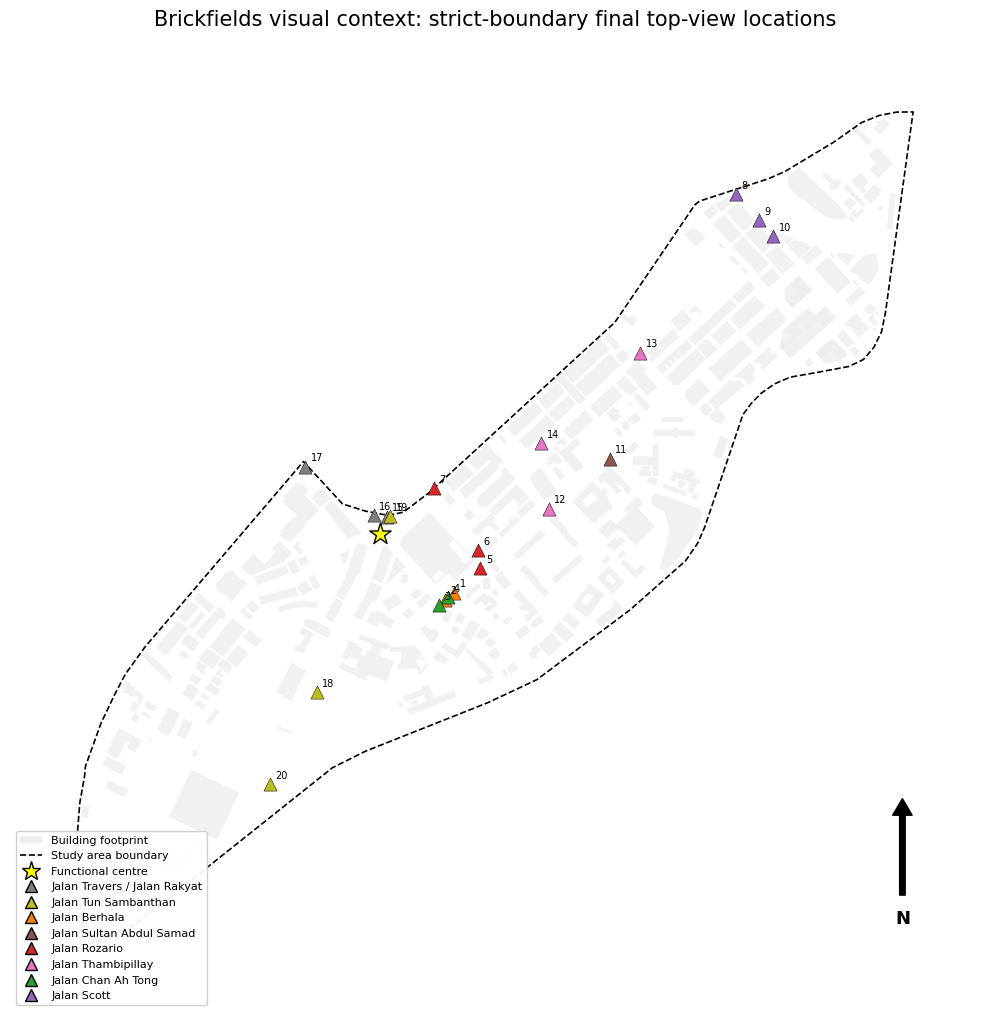


Saved strict-boundary cleaned map to:
F:\Brickfields\outputs_context_final_revised\visual\figure6_cleaned_strict_boundary_top_views_map.png


In [8]:
# ============================================================
# STRICT CLEANED FIGURE 6 MAP:
# Final top-view points strictly inside Brickfields boundary
#
# Main fix:
# - No boundary buffer is used for accepting points.
# - A point must be inside the actual Brickfields study boundary.
# - Any outside point is rejected and replaced from the candidate pool.
# - Final assertion prevents outside points entering later outputs.
# ============================================================

from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import osmnx as ox

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

OUT_DIR = Path(r"F:\Brickfields\outputs_context_final_revised")
VISUAL_DIR = OUT_DIR / "visual"
FUNCTIONAL_DIR = OUT_DIR / "functional"

VISUAL_DIR.mkdir(parents=True, exist_ok=True)

TOP_VIEWS_CSV = VISUAL_DIR / "top_views_metadata.csv"
CANDIDATES_CSV = VISUAL_DIR / "visual_metrics_for_candidates.csv"
NODE_METRICS_CSV = FUNCTIONAL_DIR / "node_metrics.csv"

PLACE_NAME = "Brickfields, Kuala Lumpur, Malaysia"

CRS_WGS84 = "EPSG:4326"
CRS_PROJ = "EPSG:32647"

OUTLIER_DISTANCE_M = 3000

# IMPORTANT:
# Use strict boundary filtering.
# Do not use 50 m or 75 m buffer if you want all points inside Brickfields.
BOUNDARY_BUFFER_M_FOR_DISPLAY_ONLY = 0

TARGET_COUNTS = {
    "Jalan Travers / Jalan Rakyat": 3,
    "Jalan Tun Sambanthan": 3,
    "Jalan Berhala": 2,
    "Jalan Sultan Abdul Samad": 3,
    "Jalan Rozario": 3,
    "Jalan Thambipillay": 3,
    "Jalan Chan Ah Tong": 3,
    "Jalan Scott": 3,
}

EXCLUDE_STREETS = ["Jalan Ang Seng"]

MERGE_STREETS = {
    "Lorong Chan Ah Tong": "Jalan Chan Ah Tong"
}

STRICT_CLEANED_TOP_VIEWS_CSV = VISUAL_DIR / "cleaned_final_top_views_strict_boundary.csv"
STRICT_CLEANED_TOP_VIEWS_MAP = VISUAL_DIR / "figure6_cleaned_strict_boundary_top_views_map.png"
STRICT_STREET_SUMMARY_CSV = VISUAL_DIR / "visual_metrics_by_jalan_strict_boundary.csv"
STRICT_REMOVED_POINTS_CSV = VISUAL_DIR / "removed_points_strict_boundary_check.csv"


# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------

top_df = pd.read_csv(TOP_VIEWS_CSV)
cand_df = pd.read_csv(CANDIDATES_CSV)
node_df = pd.read_csv(NODE_METRICS_CSV)

required_cols = ["jalan", "image_name", "latitude", "longitude"]

for file_name, df in [
    ("top_views_metadata.csv", top_df),
    ("visual_metrics_for_candidates.csv", cand_df),
]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{file_name} is missing required columns: {missing}")

if "final_top_view_score" not in cand_df.columns:
    raise ValueError("visual_metrics_for_candidates.csv must contain final_top_view_score.")

if not {"x", "y", "composite_score"}.issubset(node_df.columns):
    raise ValueError("node_metrics.csv must contain x, y, and composite_score columns.")

print(f"Initial final top-view records: {len(top_df)}")
print(f"Candidate-view records available for strict reselection: {len(cand_df)}")


# ------------------------------------------------------------
# 3. DOWNLOAD STUDY AREA BOUNDARY AND BUILDING FOOTPRINTS
# ------------------------------------------------------------

ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.timeout = 180

study_area = ox.geocode_to_gdf(PLACE_NAME).to_crs(CRS_PROJ)

# Use actual Brickfields boundary as the valid geometry
study_geom = study_area.geometry.union_all()

# Clean possible geometry issues
study_geom = study_geom.buffer(0)

polygon_wgs84 = study_area.to_crs(CRS_WGS84).geometry.iloc[0]

try:
    try:
        buildings = ox.features_from_polygon(polygon_wgs84, tags={"building": True})
    except AttributeError:
        buildings = ox.geometries_from_polygon(polygon_wgs84, tags={"building": True})

    buildings = buildings.reset_index()
    buildings = buildings[buildings.geometry.notna()].copy()
    buildings = buildings.to_crs(CRS_PROJ)
    buildings = buildings[
        buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()

    buildings = gpd.clip(buildings, study_area)

    print(f"Downloaded building footprints: {len(buildings)}")

except Exception as e:
    print("WARNING: Building footprints could not be downloaded.")
    print(e)
    buildings = gpd.GeoDataFrame(geometry=[], crs=CRS_PROJ)


# ------------------------------------------------------------
# 4. GET FUNCTIONAL CENTRE
# ------------------------------------------------------------

centre_row = node_df.loc[node_df["composite_score"].idxmax()]
centre_point = Point(centre_row["x"], centre_row["y"])

print("\nFunctional centre:")
print(f"x = {centre_row['x']:.3f}")
print(f"y = {centre_row['y']:.3f}")
print(f"composite_score = {centre_row['composite_score']:.6f}")


# ------------------------------------------------------------
# 5. HELPER FUNCTION: PREPARE AND STRICTLY FLAG POINTS
# ------------------------------------------------------------

def prepare_points_strict(df, source_name):
    out = df.copy()

    out["jalan_original"] = out["jalan"]
    out["jalan_clean"] = out["jalan"].replace(MERGE_STREETS)

    out = out[~out["jalan_clean"].isin(EXCLUDE_STREETS)].copy()

    gdf = gpd.GeoDataFrame(
        out,
        geometry=gpd.points_from_xy(out["longitude"], out["latitude"]),
        crs=CRS_WGS84
    ).to_crs(CRS_PROJ)

    gdf["dist_to_functional_centre_m"] = gdf.geometry.distance(centre_point)

    # STRICT boundary test: point must be inside or exactly on the Brickfields boundary
    gdf["inside_study_area"] = gdf.geometry.apply(lambda geom: study_geom.covers(geom))

    # Diagnostic only: how far outside if outside
    gdf["dist_outside_boundary_m"] = gdf.geometry.apply(
        lambda geom: 0.0 if study_geom.covers(geom) else geom.distance(study_geom)
    )

    gdf["valid_distance"] = gdf["dist_to_functional_centre_m"] <= OUTLIER_DISTANCE_M

    # CRITICAL FIX:
    # Use actual boundary only, not buffered boundary.
    gdf["valid_boundary"] = gdf["inside_study_area"]

    gdf["is_spatially_valid"] = gdf["valid_distance"] & gdf["valid_boundary"]

    gdf["source_dataset"] = source_name

    return gdf


# ------------------------------------------------------------
# 6. DIAGNOSE PREVIOUS FINAL TOP VIEWS
# ------------------------------------------------------------

previous_top_gdf = prepare_points_strict(top_df, "previous_final_top_views")

previous_top_gdf = (
    previous_top_gdf
    .sort_values("final_top_view_score", ascending=False)
    .drop_duplicates(subset=["image_name"], keep="first")
    .copy()
)

removed_previous = previous_top_gdf.loc[~previous_top_gdf["is_spatially_valid"]].copy()

print("\nPrevious final top views removed by STRICT boundary cleaning:")
if len(removed_previous) == 0:
    print("None")
else:
    diagnostic_cols = [
        "jalan_original",
        "jalan_clean",
        "image_name",
        "latitude",
        "longitude",
        "dist_to_functional_centre_m",
        "dist_outside_boundary_m",
        "inside_study_area",
        "valid_distance",
        "valid_boundary",
        "final_top_view_score",
    ]

    diagnostic_cols = [c for c in diagnostic_cols if c in removed_previous.columns]

    print(
        removed_previous[diagnostic_cols]
        .sort_values(["jalan_clean", "dist_outside_boundary_m"], ascending=[True, False])
        .to_string(index=False)
    )

    removed_previous.to_crs(CRS_WGS84).drop(columns="geometry").to_csv(
        STRICT_REMOVED_POINTS_CSV,
        index=False
    )

    print(f"\nSaved strict removed-point diagnostic file to:")
    print(STRICT_REMOVED_POINTS_CSV)


# ------------------------------------------------------------
# 7. PREPARE STRICTLY VALID CANDIDATE POOL
# ------------------------------------------------------------

cand_gdf = prepare_points_strict(cand_df, "candidate_pool")

valid_candidates = cand_gdf.loc[cand_gdf["is_spatially_valid"]].copy()

valid_candidates = (
    valid_candidates
    .sort_values("final_top_view_score", ascending=False)
    .drop_duplicates(subset=["image_name"], keep="first")
    .copy()
)

print("\nStrictly valid candidate counts by analytical street group:")
print(valid_candidates["jalan_clean"].value_counts().sort_index())


# ------------------------------------------------------------
# 8. SELECT FINAL STRICTLY VALID TOP VIEWS BY STREET
# ------------------------------------------------------------

selected_list = []

for street, target_n in TARGET_COUNTS.items():
    sub = valid_candidates[valid_candidates["jalan_clean"] == street].copy()

    sort_cols = ["final_top_view_score"]
    ascending = [False]

    if "key_view_candidate_score" in sub.columns:
        sort_cols.append("key_view_candidate_score")
        ascending.append(False)

    if "view_quality_score" in sub.columns:
        sort_cols.append("view_quality_score")
        ascending.append(False)

    sub = sub.sort_values(sort_cols, ascending=ascending)

    selected = sub.head(target_n).copy()

    if len(selected) < target_n:
        print(
            f"WARNING: {street} has only {len(selected)} strictly valid candidates, "
            f"but {target_n} are required."
        )

    selected_list.append(selected)

clean_gdf = pd.concat(selected_list, ignore_index=True)

# Final duplicate check
before = len(clean_gdf)

clean_gdf = (
    clean_gdf
    .sort_values("final_top_view_score", ascending=False)
    .drop_duplicates(subset=["image_name"], keep="first")
    .copy()
)

after = len(clean_gdf)

if before != after:
    print(f"WARNING: Removed {before - after} duplicate image IDs after final selection.")

expected_total = sum(TARGET_COUNTS.values())

print("\nFinal strictly valid top-view count:")
print(len(clean_gdf))

print("\nFinal strictly valid count by analytical street group:")
print(clean_gdf["jalan_clean"].value_counts().sort_index())


# ------------------------------------------------------------
# 9. HARD SAFETY CHECKS
# ------------------------------------------------------------

outside_final = clean_gdf.loc[~clean_gdf["inside_study_area"]].copy()

if len(outside_final) > 0:
    print("\nERROR: Some selected final points are still outside Brickfields.")
    print(
        outside_final[
            [
                "jalan_clean",
                "image_name",
                "latitude",
                "longitude",
                "dist_outside_boundary_m",
                "final_top_view_score",
            ]
        ].to_string(index=False)
    )
    raise ValueError(
        "Strict boundary check failed. Outside points remain in the final dataset."
    )

if len(clean_gdf) != expected_total:
    print(
        f"\nWARNING: Expected {expected_total} final points, "
        f"but only {len(clean_gdf)} strictly valid points were available."
    )
    print(
        "Do not force outside points back into the dataset. "
        "Use the available strictly valid count or manually review candidate coverage."
    )
else:
    print(f"\nSUCCESS: selected exactly {expected_total} strictly valid final top-view points.")

assert clean_gdf["inside_study_area"].all(), "Outside points remain in final clean_gdf."
assert clean_gdf["valid_distance"].all(), "Distance outliers remain in final clean_gdf."


# ------------------------------------------------------------
# 10. SAVE STRICT CLEANED FINAL TOP-VIEW CSV
# ------------------------------------------------------------

clean_wgs84 = clean_gdf.to_crs(CRS_WGS84).copy()

preferred_cols = [
    "jalan_original",
    "jalan_clean",
    "image_name",
    "latitude",
    "longitude",
    "inside_study_area",
    "dist_outside_boundary_m",
    "dist_to_functional_centre_m",
    "green_view_index",
    "sky_visibility_index",
    "building_dominance_index",
    "road_hardscape_index",
    "street_enclosure_index",
    "openness_index",
    "visual_diversity_index",
    "walkability_visual_index",
    "view_quality_score",
    "key_view_candidate_score",
    "final_top_view_score",
]

available_cols = [c for c in preferred_cols if c in clean_wgs84.columns]

clean_wgs84[available_cols].sort_values(
    ["jalan_clean", "final_top_view_score"],
    ascending=[True, False]
).to_csv(STRICT_CLEANED_TOP_VIEWS_CSV, index=False)

print(f"\nSaved strict cleaned final top views to:")
print(STRICT_CLEANED_TOP_VIEWS_CSV)


# ------------------------------------------------------------
# 11. SAVE UPDATED TABLE 8 STREET SUMMARY
# ------------------------------------------------------------

summary_spec = {
    "View": ("image_name", "count"),
}

optional_summary_cols = {
    "GVI": "green_view_index",
    "SVI": "sky_visibility_index",
    "Enclosure": "street_enclosure_index",
    "Diversity": "visual_diversity_index",
    "View quality": "view_quality_score",
    "Final top view score": "final_top_view_score",
}

for out_col, source_col in optional_summary_cols.items():
    if source_col in clean_gdf.columns:
        summary_spec[out_col] = (source_col, "mean")

street_summary = (
    clean_gdf
    .groupby("jalan_clean")
    .agg(**summary_spec)
    .reset_index()
    .rename(columns={"jalan_clean": "Street"})
)

street_summary["Street"] = pd.Categorical(
    street_summary["Street"],
    categories=list(TARGET_COUNTS.keys()),
    ordered=True
)

street_summary = street_summary.sort_values("Street")

numeric_cols = [c for c in street_summary.columns if c not in ["Street", "View"]]
street_summary[numeric_cols] = street_summary[numeric_cols].round(3)

street_summary.to_csv(STRICT_STREET_SUMMARY_CSV, index=False)

print(f"\nSaved strict boundary Table 8 summary to:")
print(STRICT_STREET_SUMMARY_CSV)

print("\nUpdated strict-boundary Table 8 values:")
print(street_summary.to_string(index=False))


# ------------------------------------------------------------
# 12. MAP STYLING
# ------------------------------------------------------------

street_order = [s for s in TARGET_COUNTS.keys() if s in clean_gdf["jalan_clean"].unique()]

street_colors = {
    "Jalan Travers / Jalan Rakyat": "#7f7f7f",
    "Jalan Tun Sambanthan": "#bcbd22",
    "Jalan Berhala": "#ff7f0e",
    "Jalan Sultan Abdul Samad": "#8c564b",
    "Jalan Rozario": "#d62728",
    "Jalan Thambipillay": "#e377c2",
    "Jalan Chan Ah Tong": "#2ca02c",
    "Jalan Scott": "#9467bd",
}


# ------------------------------------------------------------
# 13. DRAW STRICT CLEANED MAP
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 12))

if len(buildings) > 0:
    buildings.plot(
        ax=ax,
        color="#eeeeee",
        edgecolor="none",
        alpha=0.80,
        zorder=1
    )

study_area.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    linestyle="--",
    zorder=2
)

for street in street_order:
    sub = clean_gdf[clean_gdf["jalan_clean"] == street].copy()

    sub.plot(
        ax=ax,
        marker="^",
        markersize=90,
        color=street_colors[street],
        edgecolor="black",
        linewidth=0.35,
        label=street,
        zorder=5
    )

centre_gdf = gpd.GeoDataFrame(
    {"name": ["Functional centre"]},
    geometry=[centre_point],
    crs=CRS_PROJ
)

centre_gdf.plot(
    ax=ax,
    marker="*",
    markersize=260,
    color="yellow",
    edgecolor="black",
    linewidth=1.0,
    zorder=6
)

# Point labels
clean_gdf = clean_gdf.sort_values(
    ["jalan_clean", "final_top_view_score"],
    ascending=[True, False]
).copy()

clean_gdf["point_no"] = range(1, len(clean_gdf) + 1)

for _, row in clean_gdf.iterrows():
    ax.annotate(
        str(row["point_no"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        color="black",
        zorder=7
    )

# Use study boundary extent only
minx, miny, maxx, maxy = study_area.total_bounds

pad_x = (maxx - minx) * 0.08
pad_y = (maxy - miny) * 0.08

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# North arrow
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

arrow_x = x0 + 0.92 * (x1 - x0)
arrow_y = y0 + 0.12 * (y1 - y0)

ax.annotate(
    "",
    xy=(arrow_x, arrow_y + 0.10 * (y1 - y0)),
    xytext=(arrow_x, arrow_y),
    arrowprops=dict(facecolor="black", edgecolor="black", width=4, headwidth=14),
    zorder=10
)

ax.text(
    arrow_x,
    arrow_y - 0.025 * (y1 - y0),
    "N",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# Legend
building_patch = mpatches.Patch(
    facecolor="#eeeeee",
    edgecolor="none",
    label="Building footprint"
)

boundary_line = mlines.Line2D(
    [],
    [],
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Study area boundary"
)

centre_marker = mlines.Line2D(
    [],
    [],
    color="yellow",
    marker="*",
    markeredgecolor="black",
    markersize=14,
    linestyle="None",
    label="Functional centre"
)

street_handles = [
    mlines.Line2D(
        [],
        [],
        color=street_colors[street],
        marker="^",
        markeredgecolor="black",
        markersize=9,
        linestyle="None",
        label=street
    )
    for street in street_order
]

handles = [building_patch, boundary_line, centre_marker] + street_handles

ax.legend(
    handles=handles,
    loc="lower left",
    fontsize=8,
    frameon=True,
    framealpha=0.95
)

ax.set_title(
    "Brickfields visual context: strict-boundary final top-view locations",
    fontsize=15,
    pad=14
)

ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(STRICT_CLEANED_TOP_VIEWS_MAP, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved strict-boundary cleaned map to:")
print(STRICT_CLEANED_TOP_VIEWS_MAP)

In [2]:
# ============================================================
# FIGURE 6B: 3D OBLIQUE VISUAL CONTEXT MAP
# Standalone version: does not depend on previous notebook variables
# ============================================================

# If pydeck is not installed, run once:
# pip install pydeck

from pathlib import Path
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import pydeck as pdk
from shapely.geometry import Point

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

OUT_DIR = Path(r"F:\Brickfields\outputs_context_final_revised")
VISUAL_DIR = OUT_DIR / "visual"
FUNCTIONAL_DIR = OUT_DIR / "functional"

VISUAL_DIR.mkdir(parents=True, exist_ok=True)

PLACE_NAME = "Brickfields, Kuala Lumpur, Malaysia"

CRS_WGS84 = "EPSG:4326"
CRS_PROJ = "EPSG:32647"

STRICT_CLEANED_TOP_VIEWS_CSV = VISUAL_DIR / "cleaned_final_top_views_strict_boundary.csv"
NODE_METRICS_CSV = FUNCTIONAL_DIR / "node_metrics.csv"

FIGURE6B_3D_HTML = VISUAL_DIR / "figure6b_3d_visual_context_top_views.html"

# ------------------------------------------------------------
# 2. LOAD STRICT-BOUNDARY TOP-VIEW POINTS
# ------------------------------------------------------------

if not STRICT_CLEANED_TOP_VIEWS_CSV.exists():
    raise FileNotFoundError(
        f"Missing file:\n{STRICT_CLEANED_TOP_VIEWS_CSV}\n\n"
        "Run the strict-boundary Figure 6 cleaning script first."
    )

if not NODE_METRICS_CSV.exists():
    raise FileNotFoundError(
        f"Missing file:\n{NODE_METRICS_CSV}\n\n"
        "Run the functional analysis first."
    )

top_df = pd.read_csv(STRICT_CLEANED_TOP_VIEWS_CSV)
node_df = pd.read_csv(NODE_METRICS_CSV)

required_cols = ["jalan_clean", "image_name", "latitude", "longitude"]
missing = [c for c in required_cols if c not in top_df.columns]
if missing:
    raise ValueError(f"Strict cleaned top-view CSV is missing columns: {missing}")

# ------------------------------------------------------------
# 3. DOWNLOAD STUDY AREA AND BUILDING FOOTPRINTS
# ------------------------------------------------------------

ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.timeout = 180

study_area = ox.geocode_to_gdf(PLACE_NAME).to_crs(CRS_PROJ)
polygon_wgs84 = study_area.to_crs(CRS_WGS84).geometry.iloc[0]

try:
    try:
        buildings = ox.features_from_polygon(polygon_wgs84, tags={"building": True})
    except AttributeError:
        buildings = ox.geometries_from_polygon(polygon_wgs84, tags={"building": True})

    buildings = buildings.reset_index()
    buildings = buildings[buildings.geometry.notna()].copy()
    buildings = buildings.to_crs(CRS_PROJ)
    buildings = buildings[
        buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()

    buildings = gpd.clip(buildings, study_area)

    print(f"Downloaded building footprints: {len(buildings)}")

except Exception as e:
    print("WARNING: Building footprints could not be downloaded.")
    print(e)
    buildings = gpd.GeoDataFrame(geometry=[], crs=CRS_PROJ)

# ------------------------------------------------------------
# 4. GET FUNCTIONAL CENTRE FROM NODE METRICS
# ------------------------------------------------------------

if not {"x", "y", "composite_score"}.issubset(node_df.columns):
    raise ValueError("node_metrics.csv must contain x, y, and composite_score columns.")

centre_row = node_df.loc[node_df["composite_score"].idxmax()]
centre_point = Point(centre_row["x"], centre_row["y"])

# ------------------------------------------------------------
# 5. COLOUR SETTINGS
# ------------------------------------------------------------

street_colors = {
    "Jalan Travers / Jalan Rakyat": "#7f7f7f",
    "Jalan Tun Sambanthan": "#bcbd22",
    "Jalan Berhala": "#ff7f0e",
    "Jalan Sultan Abdul Samad": "#8c564b",
    "Jalan Rozario": "#d62728",
    "Jalan Thambipillay": "#e377c2",
    "Jalan Chan Ah Tong": "#2ca02c",
    "Jalan Scott": "#9467bd",
}

def hex_to_rgb(hex_color):
    hex_color = hex_color.replace("#", "")
    return [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]

# ------------------------------------------------------------
# 6. HEIGHT ESTIMATION FOR 3D BUILDING MASSING
# ------------------------------------------------------------

def parse_numeric_height(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower().replace("m", "").strip()
    match = re.search(r"[-+]?\d*\.?\d+", text)
    if match:
        return float(match.group())
    return np.nan

b3d = buildings.copy()

if len(b3d) > 0:
    if b3d.crs is None:
        b3d = b3d.set_crs(CRS_PROJ)

    if "height" in b3d.columns:
        b3d["height_m"] = b3d["height"].apply(parse_numeric_height)
    else:
        b3d["height_m"] = np.nan

    if "building:levels" in b3d.columns:
        levels = b3d["building:levels"].apply(parse_numeric_height)
        b3d["height_m"] = b3d["height_m"].fillna(levels * 3.2)

    # Fallback height for incomplete OSM height data
    b3d["height_m"] = b3d["height_m"].fillna(8.0)

    # Avoid visual outliers
    b3d["height_m"] = b3d["height_m"].clip(lower=3.0, upper=80.0)

    b3d = b3d.to_crs(CRS_WGS84)
    b3d = b3d.explode(index_parts=False).reset_index(drop=True)
    b3d = b3d[b3d.geometry.geom_type == "Polygon"].copy()

    def polygon_to_pydeck_coords(poly):
        return [[float(x), float(y)] for x, y in poly.exterior.coords]

    b3d["polygon"] = b3d.geometry.apply(polygon_to_pydeck_coords)
    building_records = b3d[["polygon", "height_m"]].to_dict("records")
else:
    building_records = []

# ------------------------------------------------------------
# 7. PREPARE TOP-VIEW POINTS
# ------------------------------------------------------------

tv3d = gpd.GeoDataFrame(
    top_df.copy(),
    geometry=gpd.points_from_xy(top_df["longitude"], top_df["latitude"]),
    crs=CRS_WGS84
)

tv3d["lon"] = tv3d.geometry.x
tv3d["lat"] = tv3d.geometry.y

score_col = "final_top_view_score"
if score_col not in tv3d.columns:
    tv3d[score_col] = np.nan

tv3d = tv3d.sort_values(
    ["jalan_clean", score_col],
    ascending=[True, False]
).copy()

tv3d["point_no"] = range(1, len(tv3d) + 1)

tv3d["color"] = tv3d["jalan_clean"].map(
    lambda s: hex_to_rgb(street_colors.get(s, "#1f77b4"))
)

for optional_col in ["view_quality_score", "final_top_view_score"]:
    if optional_col not in tv3d.columns:
        tv3d[optional_col] = np.nan

top_view_records = tv3d[
    [
        "lon",
        "lat",
        "jalan_clean",
        "image_name",
        "point_no",
        "final_top_view_score",
        "view_quality_score",
        "color",
    ]
].to_dict("records")

print(f"Strict-boundary final top-view records used in 3D map: {len(top_view_records)}")

# ------------------------------------------------------------
# 8. STUDY AREA BOUNDARY
# ------------------------------------------------------------

boundary_wgs = study_area.to_crs(CRS_WGS84).geometry.iloc[0]

boundary_paths = []

if boundary_wgs.geom_type == "Polygon":
    boundary_paths.append({
        "path": [[float(x), float(y)] for x, y in boundary_wgs.exterior.coords]
    })

elif boundary_wgs.geom_type == "MultiPolygon":
    for geom in boundary_wgs.geoms:
        boundary_paths.append({
            "path": [[float(x), float(y)] for x, y in geom.exterior.coords]
        })

# ------------------------------------------------------------
# 9. FUNCTIONAL CENTRE
# ------------------------------------------------------------

centre_wgs = gpd.GeoSeries([centre_point], crs=CRS_PROJ).to_crs(CRS_WGS84).iloc[0]

centre_record = [{
    "lon": float(centre_wgs.x),
    "lat": float(centre_wgs.y),
    "name": "Functional centre"
}]

# ------------------------------------------------------------
# 10. PYDECK 3D VIEW
# ------------------------------------------------------------

centroid = study_area.to_crs(CRS_WGS84).geometry.iloc[0].centroid

view_state = pdk.ViewState(
    longitude=float(centroid.x),
    latitude=float(centroid.y),
    zoom=14.4,
    pitch=55,
    bearing=35
)

building_layer = pdk.Layer(
    "PolygonLayer",
    data=building_records,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    wireframe=False,
    opacity=0.55,
    get_fill_color=[210, 210, 210],
    get_line_color=[160, 160, 160],
    pickable=True,
)

boundary_layer = pdk.Layer(
    "PathLayer",
    data=boundary_paths,
    get_path="path",
    get_width=4,
    get_color=[0, 0, 0],
    pickable=False,
)

top_view_layer = pdk.Layer(
    "ScatterplotLayer",
    data=top_view_records,
    get_position="[lon, lat]",
    get_radius=12,
    get_fill_color="color",
    get_line_color=[0, 0, 0],
    line_width_min_pixels=1,
    pickable=True,
)

label_layer = pdk.Layer(
    "TextLayer",
    data=top_view_records,
    get_position="[lon, lat]",
    get_text="point_no",
    get_size=13,
    get_color=[0, 0, 0],
    get_pixel_offset=[0, -15],
    pickable=False,
)

centre_layer = pdk.Layer(
    "ScatterplotLayer",
    data=centre_record,
    get_position="[lon, lat]",
    get_radius=20,
    get_fill_color=[255, 230, 0],
    get_line_color=[0, 0, 0],
    line_width_min_pixels=2,
    pickable=True,
)

deck = pdk.Deck(
    layers=[
        building_layer,
        boundary_layer,
        top_view_layer,
        label_layer,
        centre_layer,
    ],
    initial_view_state=view_state,
    map_style=None,
    tooltip={
        "html": """
        <b>{jalan_clean}</b><br/>
        Point: {point_no}<br/>
        Final top-view score: {final_top_view_score}<br/>
        View-quality score: {view_quality_score}<br/>
        Image: {image_name}
        """,
        "style": {"backgroundColor": "white", "color": "black"}
    }
)

deck.to_html(str(FIGURE6B_3D_HTML), open_browser=True)

print("\nSaved 3D visual context map:")
print(FIGURE6B_3D_HTML)

Downloaded building footprints: 509
Strict-boundary final top-view records used in 3D map: 20

Saved 3D visual context map:
F:\Brickfields\outputs_context_final_revised\visual\figure6b_3d_visual_context_top_views.html


In [12]:
# ============================================================
# FIGURE 6B COMPLETE REVISED SCRIPT
# 3D Brickfields visual context map
#
# Includes:
# - Strict-boundary final top-view records
# - Wider NU Sentral / KL Sentral / Little India context
# - Manual high-rise height correction for outside-context towers
# - Auto-flagged outside-context likely high-rise blocks
# - NU Sentral bridge / concourse low-height correction
# - No manual height correction for normal buildings inside study boundary
# - Basemap with streets
# - OSM street overlay
# - Improved hover details for final top-view points
# - 3D north arrow and 200 m scale bar placed above legend area
# - HTML legend overlay
# ============================================================

# If needed, install once:
# pip install pydeck osmnx geopandas shapely pandas numpy

from pathlib import Path
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import pydeck as pdk
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

OUT_DIR = Path(r"F:\Brickfields\outputs_context_final_revised")
VISUAL_DIR = OUT_DIR / "visual"
FUNCTIONAL_DIR = OUT_DIR / "functional"
VISUAL_DIR.mkdir(parents=True, exist_ok=True)

PLACE_NAME = "Brickfields, Kuala Lumpur, Malaysia"

CONTEXT_ANCHORS = [
    "NU Sentral, Kuala Lumpur, Malaysia",
    "KL Sentral, Kuala Lumpur, Malaysia",
    "Little India Brickfields, Kuala Lumpur, Malaysia",
]

CRS_WGS84 = "EPSG:4326"
CRS_PROJ = "EPSG:32647"

STRICT_CLEANED_TOP_VIEWS_CSV = VISUAL_DIR / "cleaned_final_top_views_strict_boundary.csv"
NODE_METRICS_CSV = FUNCTIONAL_DIR / "node_metrics.csv"

FIGURE6B_3D_HTML = VISUAL_DIR / "figure6b_3d_visual_context_final_complete_revised.html"
HEIGHT_AUDIT_CSV = VISUAL_DIR / "context_building_height_audit_final_complete_revised.csv"
SUSPECTED_HIGHRISE_CSV = VISUAL_DIR / "suspected_context_highrises_for_review_final_complete_revised.csv"
BRIDGE_CORRECTION_CSV = VISUAL_DIR / "nu_sentral_bridge_concourse_corrections.csv"

# Basemap with streets and labels.
# Internet is required when the HTML is opened.
BASEMAP_STYLE = "https://basemaps.cartocdn.com/gl/positron-gl-style/style.json"

# Wider context
SITE_CONTEXT_BUFFER_M = 350
ANCHOR_BUFFER_M = 300

# Height settings
DEFAULT_HEIGHT_M = 10.0
MIN_HEIGHT_M = 3.0
MAX_HEIGHT_M = 180.0

# Outside-context high-rise detection
USE_PROVISIONAL_CONTEXT_HEIGHTS = True
CONTEXT_HIGHRISE_SEARCH_RADIUS_M = 800

LARGE_FOOTPRINT_THRESHOLD_1 = 1200
LARGE_FOOTPRINT_THRESHOLD_2 = 2500
LARGE_FOOTPRINT_THRESHOLD_3 = 4500

PROVISIONAL_HEIGHT_1 = 45.0
PROVISIONAL_HEIGHT_2 = 75.0
PROVISIONAL_HEIGHT_3 = 115.0

# NU Sentral bridge / concourse correction
# This is a display correction for bridge/concourse-like features only.
# It is not used in analytical calculations.
BRIDGE_DISPLAY_HEIGHT_M = 6.0
BRIDGE_ASPECT_RATIO_THRESHOLD = 3.2
BRIDGE_MAX_AREA_M2 = 3500
BRIDGE_NU_DISTANCE_M = 420
BRIDGE_MIN_HEIGHT_PROBLEM_M = 35

# Scale bar
SCALE_BAR_LENGTH_M = 200

# ------------------------------------------------------------
# 2. MANUAL OUTSIDE-CONTEXT TOWER OVERRIDES ONLY
# ------------------------------------------------------------
# These display heights are applied to outside-context towers only.
# NU Sentral itself is not manually raised to avoid misclassifying
# link bridges/concourse structures as towers.

MANUAL_TOWER_OVERRIDES = [
    {
        "label": "Suasana Sentral Tower",
        "query": "Suasana Sentral Condominium, Brickfields, Kuala Lumpur, Malaysia",
        "height_m": 145.0,
        "match_radius_m": 140,
    },
    {
        "label": "Suasana Sentral Tower",
        "query": "Suasana Sentral, Brickfields, Kuala Lumpur, Malaysia",
        "height_m": 145.0,
        "match_radius_m": 140,
    },
    {
        "label": "Shell Malaysia Trading Tower / Menara Shell",
        "query": "Menara Shell, KL Sentral, Kuala Lumpur, Malaysia",
        "height_m": 135.0,
        "match_radius_m": 150,
    },
    {
        "label": "Shell Malaysia Trading Tower / Menara Shell",
        "query": "Shell Malaysia Trading, Kuala Lumpur, Malaysia",
        "height_m": 135.0,
        "match_radius_m": 150,
    },
    {
        "label": "KL Sentral Office Tower Context Block",
        "query": "KL Sentral, Kuala Lumpur, Malaysia",
        "height_m": 120.0,
        "match_radius_m": 180,
    },
]

MANUAL_NAME_KEYWORD_HEIGHTS = [
    {"keyword": "suasana sentral", "height_m": 145.0, "label": "Suasana Sentral Tower"},
    {"keyword": "menara shell", "height_m": 135.0, "label": "Shell Malaysia Trading Tower / Menara Shell"},
    {"keyword": "shell malaysia", "height_m": 135.0, "label": "Shell Malaysia Trading Tower"},
    {"keyword": "sentral residence", "height_m": 110.0, "label": "Sentral Residence context tower"},
    {"keyword": "plaza sentral", "height_m": 95.0, "label": "Plaza Sentral context block"},
    {"keyword": "q sentral", "height_m": 150.0, "label": "Q Sentral context tower"},
]

# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------

def parse_numeric_height(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower()
    text = text.replace("metres", "").replace("meters", "").replace("meter", "")
    text = text.replace("m", "").strip()
    match = re.search(r"[-+]?\d*\.?\d+", text)
    return float(match.group()) if match else np.nan


def safe_geocode_gdf(query):
    """
    Robust geocoder:
    1. Tries polygon geocoding with osmnx.geocode_to_gdf().
    2. If polygon geocoding fails, falls back to point geocoding.
    3. Returns GeoDataFrame in projected CRS.
    """
    try:
        gdf = ox.geocode_to_gdf(query)
        if gdf is not None and len(gdf) > 0:
            return gdf.to_crs(CRS_PROJ)
    except Exception as e1:
        print(f"Polygon geocoding failed for: {query}")
        print(e1)

        try:
            lat, lon = ox.geocode(query)
            return gpd.GeoDataFrame(
                {"query": [query]},
                geometry=[Point(lon, lat)],
                crs=CRS_WGS84
            ).to_crs(CRS_PROJ)
        except Exception as e2:
            print(f"WARNING: Could not geocode query as polygon or point: {query}")
            print(e2)
            return None

    return None


def hex_to_rgb(hex_color):
    hex_color = hex_color.replace("#", "")
    return [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]


def polygon_to_coords(poly):
    return [[float(x), float(y)] for x, y in poly.exterior.coords]


def line_to_path(line):
    return [[float(x), float(y)] for x, y in line.coords]


def polygon_records_for_pydeck(gdf, extra_cols=None):
    if extra_cols is None:
        extra_cols = []

    if len(gdf) == 0:
        return []

    gdf = gdf.to_crs(CRS_WGS84)
    gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    gdf = gdf[gdf.geometry.geom_type == "Polygon"].copy()
    gdf["polygon"] = gdf.geometry.apply(polygon_to_coords)

    keep_cols = ["polygon", "height_m"] + [c for c in extra_cols if c in gdf.columns]
    return gdf[keep_cols].to_dict("records")


def path_records_from_geom(geom):
    records = []

    if geom.geom_type == "Polygon":
        records.append({"path": [[float(x), float(y)] for x, y in geom.exterior.coords]})

    elif geom.geom_type == "MultiPolygon":
        for g in geom.geoms:
            records.append({"path": [[float(x), float(y)] for x, y in g.exterior.coords]})

    elif geom.geom_type == "LineString":
        records.append({"path": [[float(x), float(y)] for x, y in geom.coords]})

    elif geom.geom_type == "MultiLineString":
        for g in geom.geoms:
            records.append({"path": [[float(x), float(y)] for x, y in g.coords]})

    return records


def nearest_building_index(building_gdf, point_geom, max_dist=100):
    if len(building_gdf) == 0:
        return None

    rp = building_gdf.geometry.representative_point()
    d = rp.distance(point_geom)

    if len(d) == 0:
        return None

    idx = d.idxmin()
    return idx if pd.notna(d.loc[idx]) and d.loc[idx] <= max_dist else None


def get_best_text(row, cols):
    vals = []
    for c in cols:
        if c in row and pd.notna(row[c]):
            vals.append(str(row[c]))
    return " | ".join(vals).lower()


def projected_point_to_lonlat(x, y):
    pt = gpd.GeoSeries([Point(x, y)], crs=CRS_PROJ).to_crs(CRS_WGS84).iloc[0]
    return float(pt.x), float(pt.y)


def projected_polygon_to_record(poly, height_m=6.0):
    poly_wgs = gpd.GeoSeries([poly], crs=CRS_PROJ).to_crs(CRS_WGS84).iloc[0]
    return {"polygon": polygon_to_coords(poly_wgs), "height_m": height_m}


def projected_line_to_record(line):
    line_wgs = gpd.GeoSeries([line], crs=CRS_PROJ).to_crs(CRS_WGS84).iloc[0]
    return {"path": line_to_path(line_wgs)}


def footprint_aspect_ratio(geom):
    """
    Approximate long-side / short-side ratio using minimum rotated rectangle.
    Used to identify bridge-like or concourse-like elongated footprints.
    """
    try:
        mrr = geom.minimum_rotated_rectangle
        if mrr.geom_type != "Polygon":
            return np.nan

        coords = list(mrr.exterior.coords)
        if len(coords) < 5:
            return np.nan

        lengths = []
        for i in range(4):
            p1 = Point(coords[i])
            p2 = Point(coords[i + 1])
            lengths.append(p1.distance(p2))

        lengths = sorted([v for v in lengths if v > 0])
        if len(lengths) < 2:
            return np.nan

        short_side = lengths[0]
        long_side = lengths[-1]

        if short_side == 0:
            return np.nan

        return long_side / short_side

    except Exception:
        return np.nan


def first_available_value(row, possible_cols):
    for c in possible_cols:
        if c in row and pd.notna(row[c]):
            return row[c]
    return np.nan


def fmt_value(v):
    if pd.isna(v):
        return "n/a"
    try:
        return f"{float(v):.3f}"
    except Exception:
        return str(v)

# ------------------------------------------------------------
# 4. LOAD INPUT FILES
# ------------------------------------------------------------

if not STRICT_CLEANED_TOP_VIEWS_CSV.exists():
    raise FileNotFoundError(
        f"Missing file:\n{STRICT_CLEANED_TOP_VIEWS_CSV}\n\n"
        "Run the strict-boundary Figure 6 cleaning script first."
    )

if not NODE_METRICS_CSV.exists():
    raise FileNotFoundError(
        f"Missing file:\n{NODE_METRICS_CSV}\n\n"
        "Run the functional analysis first."
    )

top_df = pd.read_csv(STRICT_CLEANED_TOP_VIEWS_CSV)
node_df = pd.read_csv(NODE_METRICS_CSV)

required_cols = ["jalan_clean", "image_name", "latitude", "longitude"]
missing = [c for c in required_cols if c not in top_df.columns]
if missing:
    raise ValueError(f"Strict cleaned top-view CSV is missing columns: {missing}")

if not {"x", "y", "composite_score"}.issubset(node_df.columns):
    raise ValueError("node_metrics.csv must contain x, y, and composite_score columns.")

# ------------------------------------------------------------
# 5. OSMNX SETTINGS
# ------------------------------------------------------------

ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.timeout = 180

# ------------------------------------------------------------
# 6. STUDY AREA AND CONTEXT ENVELOPE
# ------------------------------------------------------------

study_area_raw = ox.geocode_to_gdf(PLACE_NAME).to_crs(CRS_PROJ)
study_geom = study_area_raw.geometry.iloc[0]

study_area = gpd.GeoDataFrame(
    {"name": ["Analytical study boundary"]},
    geometry=[study_geom],
    crs=CRS_PROJ
)

context_geoms = [study_geom.buffer(SITE_CONTEXT_BUFFER_M)]
anchor_points_for_labels = []
anchor_points_geoms = []

for anchor in CONTEXT_ANCHORS:
    gdf_anchor = safe_geocode_gdf(anchor)

    if gdf_anchor is not None and len(gdf_anchor) > 0:
        geom_anchor = gdf_anchor.geometry.iloc[0]
        rp = geom_anchor if geom_anchor.geom_type == "Point" else geom_anchor.representative_point()

        anchor_points_geoms.append(rp)
        anchor_points_for_labels.append({
            "label": anchor.replace(", Kuala Lumpur, Malaysia", ""),
            "x": rp.x,
            "y": rp.y,
        })

        context_geoms.append(geom_anchor.buffer(ANCHOR_BUFFER_M))

context_geom = unary_union(context_geoms)

context_area = gpd.GeoDataFrame(
    {"name": ["Wider context envelope"]},
    geometry=[context_geom],
    crs=CRS_PROJ
)

# ------------------------------------------------------------
# 7. DOWNLOAD BUILDINGS
# ------------------------------------------------------------

context_polygon_wgs84 = context_area.to_crs(CRS_WGS84).geometry.iloc[0]

try:
    try:
        buildings = ox.features_from_polygon(context_polygon_wgs84, tags={"building": True})
    except AttributeError:
        buildings = ox.geometries_from_polygon(context_polygon_wgs84, tags={"building": True})

    buildings = buildings.reset_index()
    buildings = buildings[buildings.geometry.notna()].copy()
    buildings = buildings.to_crs(CRS_PROJ)
    buildings = buildings[buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    buildings = gpd.clip(buildings, context_area)
    buildings = buildings[buildings.geometry.notna()].copy()
    buildings = buildings[buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

    print(f"Downloaded buildings in wider context: {len(buildings)}")

except Exception as e:
    print("WARNING: Building download failed.")
    print(e)
    buildings = gpd.GeoDataFrame(geometry=[], crs=CRS_PROJ)

if len(buildings) == 0:
    raise ValueError("No building footprints were downloaded. Cannot create 3D model.")

# ------------------------------------------------------------
# 8. DOWNLOAD STREET NETWORK OVERLAY
# ------------------------------------------------------------

street_records = []

try:
    G_context = ox.graph_from_polygon(
        context_polygon_wgs84,
        network_type="walk",
        simplify=True
    )

    edges = ox.graph_to_gdfs(G_context, nodes=False, edges=True)
    edges = edges.to_crs(CRS_WGS84)
    edges = edges[edges.geometry.notna()].copy()
    edges = edges.explode(index_parts=False).reset_index(drop=True)
    edges = edges[edges.geometry.geom_type == "LineString"].copy()

    street_records = [{"path": line_to_path(geom)} for geom in edges.geometry]

    print(f"Downloaded street / pedestrian edges for overlay: {len(street_records)}")

except Exception as e:
    print("WARNING: Street overlay could not be generated.")
    print(e)

# ------------------------------------------------------------
# 9. BASE BUILDING HEIGHTS
# ------------------------------------------------------------

b3d = buildings.copy()

if "height" in b3d.columns:
    b3d["height_osm"] = b3d["height"].apply(parse_numeric_height)
else:
    b3d["height_osm"] = np.nan

if "building:levels" in b3d.columns:
    b3d["levels_osm"] = b3d["building:levels"].apply(parse_numeric_height)
else:
    b3d["levels_osm"] = np.nan

b3d["height_from_levels"] = b3d["levels_osm"] * 3.2
b3d["height_m"] = b3d["height_osm"].fillna(b3d["height_from_levels"])

b3d["height_source"] = np.where(
    b3d["height_osm"].notna(),
    "osm_height",
    np.where(b3d["height_from_levels"].notna(), "osm_levels", "default")
)

b3d["height_m"] = b3d["height_m"].fillna(DEFAULT_HEIGHT_M)
b3d["footprint_area_m2"] = b3d.geometry.area

name_like_cols = [
    "name", "brand", "operator", "office", "building",
    "addr:housename", "addr:street"
]

existing_name_cols = [c for c in name_like_cols if c in b3d.columns]
b3d["name_text"] = b3d.apply(lambda r: get_best_text(r, existing_name_cols), axis=1)

# ------------------------------------------------------------
# 10. CLASSIFY SITE VS CONTEXT
# ------------------------------------------------------------

study_union = study_area.geometry.iloc[0]
rep_pts = b3d.geometry.representative_point()

b3d["in_study"] = rep_pts.within(study_union)
b3d["in_context_only"] = ~b3d["in_study"]

b3d["override_source"] = ""
b3d["override_label"] = ""

# Lock internal site heights before context-only correction.
site_height_lock = b3d.loc[
    b3d["in_study"],
    ["height_m", "height_source", "override_source", "override_label"]
].copy()

# ------------------------------------------------------------
# 11. MANUAL KEYWORD HEIGHT OVERRIDES — CONTEXT ONLY
# ------------------------------------------------------------

for item in MANUAL_NAME_KEYWORD_HEIGHTS:
    keyword = item["keyword"].lower()
    h = item["height_m"]
    lbl = item["label"]

    mask = (
        b3d["in_context_only"] &
        b3d["name_text"].str.contains(keyword, na=False)
    )

    if mask.any():
        b3d.loc[mask, "height_m"] = h
        b3d.loc[mask, "height_source"] = "manual_keyword_context_only"
        b3d.loc[mask, "override_source"] = "manual_keyword_context_only"
        b3d.loc[mask, "override_label"] = lbl
        print(f"Context-only keyword override matched {mask.sum()} building(s): {lbl}")

# ------------------------------------------------------------
# 12. MANUAL GEOCODED TOWER OVERRIDES — CONTEXT ONLY
# ------------------------------------------------------------

for item in MANUAL_TOWER_OVERRIDES:
    tower_label = item["label"]
    tower_query = item["query"]
    tower_height = item["height_m"]
    tower_radius = item["match_radius_m"]

    gdf_tower = safe_geocode_gdf(tower_query)

    if gdf_tower is None or len(gdf_tower) == 0:
        print(f"WARNING: No geocode result for tower override: {tower_label}")
        continue

    tower_geom = gdf_tower.geometry.iloc[0]
    tower_pt = tower_geom if tower_geom.geom_type == "Point" else tower_geom.representative_point()

    context_only_buildings = b3d[b3d["in_context_only"]].copy()
    idx = nearest_building_index(context_only_buildings, tower_pt, max_dist=tower_radius)

    if idx is not None:
        b3d.loc[idx, "height_m"] = tower_height
        b3d.loc[idx, "height_source"] = "manual_geocoded_context_only"
        b3d.loc[idx, "override_source"] = "manual_geocoded_context_only"
        b3d.loc[idx, "override_label"] = tower_label
        print(f"Context-only geocoded tower override applied: {tower_label} -> building index {idx}")
    else:
        print(f"WARNING: No outside-context building matched for tower override: {tower_label}")

# ------------------------------------------------------------
# 13. AUTO PROVISIONAL HIGH-RISE DETECTION — CONTEXT ONLY
# ------------------------------------------------------------

b3d["dist_to_anchor_m"] = np.nan

if len(anchor_points_geoms) > 0:
    rp = b3d.geometry.representative_point()
    b3d["dist_to_anchor_m"] = [
        min([geom.distance(ap) for ap in anchor_points_geoms])
        for geom in rp
    ]

b3d["likely_context_highrise_missing_data"] = False

if USE_PROVISIONAL_CONTEXT_HEIGHTS:
    mask_context_search = (
        b3d["in_context_only"] &
        b3d["dist_to_anchor_m"].notna() &
        (b3d["dist_to_anchor_m"] <= CONTEXT_HIGHRISE_SEARCH_RADIUS_M) &
        (b3d["height_source"] == "default")
    )

    mask_highrise_candidate = (
        mask_context_search &
        (b3d["footprint_area_m2"] >= LARGE_FOOTPRINT_THRESHOLD_1)
    )

    b3d.loc[mask_highrise_candidate, "likely_context_highrise_missing_data"] = True

    mask_h3 = (
        mask_context_search &
        (b3d["footprint_area_m2"] >= LARGE_FOOTPRINT_THRESHOLD_3) &
        (b3d["override_source"] == "")
    )

    mask_h2 = (
        mask_context_search &
        (b3d["footprint_area_m2"] >= LARGE_FOOTPRINT_THRESHOLD_2) &
        (b3d["footprint_area_m2"] < LARGE_FOOTPRINT_THRESHOLD_3) &
        (b3d["override_source"] == "")
    )

    mask_h1 = (
        mask_context_search &
        (b3d["footprint_area_m2"] >= LARGE_FOOTPRINT_THRESHOLD_1) &
        (b3d["footprint_area_m2"] < LARGE_FOOTPRINT_THRESHOLD_2) &
        (b3d["override_source"] == "")
    )

    b3d.loc[mask_h1, "height_m"] = PROVISIONAL_HEIGHT_1
    b3d.loc[mask_h1, "height_source"] = "provisional_context_only"
    b3d.loc[mask_h1, "override_source"] = "provisional_context_only"
    b3d.loc[mask_h1, "override_label"] = "Auto-flagged likely high-rise context block"

    b3d.loc[mask_h2, "height_m"] = PROVISIONAL_HEIGHT_2
    b3d.loc[mask_h2, "height_source"] = "provisional_context_only"
    b3d.loc[mask_h2, "override_source"] = "provisional_context_only"
    b3d.loc[mask_h2, "override_label"] = "Auto-flagged likely high-rise context block"

    b3d.loc[mask_h3, "height_m"] = PROVISIONAL_HEIGHT_3
    b3d.loc[mask_h3, "height_source"] = "provisional_context_only"
    b3d.loc[mask_h3, "override_source"] = "provisional_context_only"
    b3d.loc[mask_h3, "override_label"] = "Auto-flagged likely high-rise context block"

    print(
        "Auto-flagged likely context-only high-rise buildings:",
        int(b3d["likely_context_highrise_missing_data"].sum())
    )

# ------------------------------------------------------------
# 13B. NU SENTRAL BRIDGE / CONCOURSE LOW-HEIGHT CORRECTION
# ------------------------------------------------------------
# This corrects bridge/concourse-like blocks near NU Sentral that have been
# wrongly displayed as towers. It is a display-only correction.

b3d["footprint_aspect_ratio"] = b3d.geometry.apply(footprint_aspect_ratio)
b3d["dist_to_nu_sentral_m"] = np.nan

nu_sentral_gdf = safe_geocode_gdf("NU Sentral, Kuala Lumpur, Malaysia")

if nu_sentral_gdf is not None and len(nu_sentral_gdf) > 0:
    nu_geom = nu_sentral_gdf.geometry.iloc[0]
    nu_point = nu_geom if nu_geom.geom_type == "Point" else nu_geom.representative_point()

    b3d["dist_to_nu_sentral_m"] = b3d.geometry.representative_point().distance(nu_point)

    bridge_name_mask = b3d["name_text"].str.contains(
        "bridge|link|walkway|pedestrian|concourse|connector",
        case=False,
        na=False,
        regex=True
    )

    elongated_bridge_like_mask = (
        (b3d["footprint_aspect_ratio"] >= BRIDGE_ASPECT_RATIO_THRESHOLD) &
        (b3d["footprint_area_m2"] <= BRIDGE_MAX_AREA_M2)
    )

    near_nu_mask = (
        b3d["dist_to_nu_sentral_m"].notna() &
        (b3d["dist_to_nu_sentral_m"] <= BRIDGE_NU_DISTANCE_M)
    )

    height_problem_mask = (
        b3d["height_m"].notna() &
        (b3d["height_m"] >= BRIDGE_MIN_HEIGHT_PROBLEM_M)
    )

    bridge_low_height_mask = (
        near_nu_mask &
        height_problem_mask &
        (
            bridge_name_mask |
            elongated_bridge_like_mask
        )
    )

    if bridge_low_height_mask.any():
        b3d.loc[bridge_low_height_mask, "height_m"] = BRIDGE_DISPLAY_HEIGHT_M
        b3d.loc[bridge_low_height_mask, "height_source"] = "manual_bridge_low_height_display"
        b3d.loc[bridge_low_height_mask, "override_source"] = "manual_bridge_low_height_display"
        b3d.loc[bridge_low_height_mask, "override_label"] = "NU Sentral bridge / concourse display correction"

        bridge_cols = [
            "name", "building", "height_m", "height_source",
            "override_label", "in_study", "in_context_only",
            "footprint_area_m2", "footprint_aspect_ratio",
            "dist_to_nu_sentral_m"
        ]
        bridge_cols_existing = [c for c in bridge_cols if c in b3d.columns]
        b3d.loc[bridge_low_height_mask, bridge_cols_existing].to_csv(
            BRIDGE_CORRECTION_CSV,
            index=False
        )

        print(
            "NU Sentral bridge/concourse low-height corrections applied:",
            int(bridge_low_height_mask.sum())
        )
        print("Saved bridge/concourse correction audit:")
        print(BRIDGE_CORRECTION_CSV)
    else:
        print("No NU Sentral bridge/concourse low-height correction was triggered.")

else:
    print("WARNING: NU Sentral could not be geocoded for bridge/concourse correction.")

# Restore normal internal site heights, but keep bridge/concourse corrections.
# This means normal buildings inside the site remain unchanged, while the
# bridge/concourse display correction is retained if triggered.
bridge_indices = b3d.index[
    b3d["override_source"] == "manual_bridge_low_height_display"
]

restore_indices = site_height_lock.index.difference(bridge_indices)

b3d.loc[
    restore_indices,
    ["height_m", "height_source", "override_source", "override_label"]
] = site_height_lock.loc[
    restore_indices,
    ["height_m", "height_source", "override_source", "override_label"]
]

b3d["height_m"] = b3d["height_m"].clip(lower=MIN_HEIGHT_M, upper=MAX_HEIGHT_M)

# ------------------------------------------------------------
# 14. EXPORT AUDIT TABLES
# ------------------------------------------------------------

rp = b3d.geometry.representative_point()
b3d["centroid_x"] = rp.x
b3d["centroid_y"] = rp.y

audit_cols = [
    "name", "brand", "operator", "office", "building",
    "height", "building:levels",
    "height_osm", "levels_osm", "height_from_levels",
    "height_m", "height_source", "override_source", "override_label",
    "in_study", "in_context_only",
    "footprint_area_m2", "footprint_aspect_ratio",
    "dist_to_anchor_m", "dist_to_nu_sentral_m",
    "likely_context_highrise_missing_data",
    "centroid_x", "centroid_y"
]

audit_cols_existing = [c for c in audit_cols if c in b3d.columns]
b3d[audit_cols_existing].to_csv(HEIGHT_AUDIT_CSV, index=False)

suspected = b3d[
    b3d["override_source"].isin([
        "manual_geocoded_context_only",
        "manual_keyword_context_only",
        "provisional_context_only",
        "manual_bridge_low_height_display"
    ])
].copy()

suspected_cols = [c for c in audit_cols_existing if c in suspected.columns]
suspected[suspected_cols].to_csv(SUSPECTED_HIGHRISE_CSV, index=False)

print("\nSaved height audit:")
print(HEIGHT_AUDIT_CSV)

print("\nSaved suspected / corrected context feature audit:")
print(SUSPECTED_HIGHRISE_CSV)

# ------------------------------------------------------------
# 15. SPLIT BUILDING LAYERS
# ------------------------------------------------------------

b_site = b3d[
    b3d["in_study"] &
    (b3d["override_source"] != "manual_bridge_low_height_display")
].copy()

b_bridge = b3d[
    b3d["override_source"] == "manual_bridge_low_height_display"
].copy()

b_context = b3d[b3d["in_context_only"]].copy()

b_context_manual = b_context[
    b_context["override_source"].isin([
        "manual_geocoded_context_only",
        "manual_keyword_context_only"
    ])
].copy()

b_context_auto = b_context[
    b_context["override_source"] == "provisional_context_only"
].copy()

b_context_base = b_context[
    ~b_context.index.isin(b_context_manual.index) &
    ~b_context.index.isin(b_context_auto.index) &
    ~b_context.index.isin(b_bridge.index)
].copy()

site_records = polygon_records_for_pydeck(
    b_site,
    extra_cols=["height_source", "override_label"]
)

bridge_records = polygon_records_for_pydeck(
    b_bridge,
    extra_cols=["height_source", "override_label"]
)

context_base_records = polygon_records_for_pydeck(
    b_context_base,
    extra_cols=["height_source", "override_label"]
)

context_manual_records = polygon_records_for_pydeck(
    b_context_manual,
    extra_cols=["height_source", "override_label"]
)

context_auto_records = polygon_records_for_pydeck(
    b_context_auto,
    extra_cols=["height_source", "override_label"]
)

print(f"\nBuildings inside study boundary, unchanged heights: {len(site_records)}")
print(f"Bridge/concourse corrected features: {len(bridge_records)}")
print(f"Base context-only buildings: {len(context_base_records)}")
print(f"Manual corrected context-only high-rises: {len(context_manual_records)}")
print(f"Auto-flagged context-only high-rises: {len(context_auto_records)}")

# ------------------------------------------------------------
# 16. TOWER AND BRIDGE LABELS
# ------------------------------------------------------------

tower_label_records = []

if len(b_context_manual) > 0:
    tower_points_proj = b_context_manual.geometry.representative_point()
    tower_points_wgs = gpd.GeoSeries(tower_points_proj, crs=CRS_PROJ).to_crs(CRS_WGS84)

    for idx, row in b_context_manual.iterrows():
        pt = tower_points_wgs.loc[idx]
        label = row.get("override_label", "Known context tower")
        height = row.get("height_m", np.nan)

        label_text = f"{label} ({height:.0f} m)" if pd.notna(height) else label

        tower_label_records.append({
            "lon": float(pt.x),
            "lat": float(pt.y),
            "label": label_text,
        })

auto_highrise_label_records = []

if len(b_context_auto) > 0:
    auto_label_gdf = b_context_auto.sort_values(
        ["height_m", "footprint_area_m2"],
        ascending=[False, False]
    ).head(10).copy()

    auto_points_proj = auto_label_gdf.geometry.representative_point()
    auto_points_wgs = gpd.GeoSeries(auto_points_proj, crs=CRS_PROJ).to_crs(CRS_WGS84)

    for idx, row in auto_label_gdf.iterrows():
        pt = auto_points_wgs.loc[idx]
        height = row.get("height_m", np.nan)

        label_text = f"Likely context high-rise ({height:.0f} m)" if pd.notna(height) else "Likely context high-rise"

        auto_highrise_label_records.append({
            "lon": float(pt.x),
            "lat": float(pt.y),
            "label": label_text,
        })

bridge_label_records = []

if len(b_bridge) > 0:
    bridge_points_proj = b_bridge.geometry.representative_point()
    bridge_points_wgs = gpd.GeoSeries(bridge_points_proj, crs=CRS_PROJ).to_crs(CRS_WGS84)

    for idx, row in b_bridge.iterrows():
        pt = bridge_points_wgs.loc[idx]

        bridge_label_records.append({
            "lon": float(pt.x),
            "lat": float(pt.y),
            "label": "Bridge / concourse corrected",
        })

# ------------------------------------------------------------
# 17. FINAL TOP-VIEW POINTS WITH HOVER DETAILS
# ------------------------------------------------------------

street_colors = {
    "Jalan Travers / Jalan Rakyat": "#7f7f7f",
    "Jalan Tun Sambanthan": "#bcbd22",
    "Jalan Berhala": "#ff7f0e",
    "Jalan Sultan Abdul Samad": "#8c564b",
    "Jalan Rozario": "#d62728",
    "Jalan Thambipillay": "#e377c2",
    "Jalan Chan Ah Tong": "#2ca02c",
    "Jalan Scott": "#9467bd",
}

tv3d = gpd.GeoDataFrame(
    top_df.copy(),
    geometry=gpd.points_from_xy(top_df["longitude"], top_df["latitude"]),
    crs=CRS_WGS84
)

tv3d["lon"] = tv3d.geometry.x
tv3d["lat"] = tv3d.geometry.y

# Ensure common columns exist
for col in [
    "final_top_view_score",
    "view_quality_score",
    "candidate_view_score",
    "key_view_candidate_score",
    "gvi", "GVI", "green_view_index",
    "svi", "SVI", "sky_visibility_index",
    "street_enclosure_index", "enclosure",
    "visual_diversity_index", "diversity",
    "image_id",
    "image_name",
]:
    if col not in tv3d.columns:
        tv3d[col] = np.nan

tv3d["hover_gvi"] = tv3d.apply(
    lambda r: first_available_value(r, ["gvi", "GVI", "green_view_index"]),
    axis=1
)

tv3d["hover_svi"] = tv3d.apply(
    lambda r: first_available_value(r, ["svi", "SVI", "sky_visibility_index"]),
    axis=1
)

tv3d["hover_enclosure"] = tv3d.apply(
    lambda r: first_available_value(r, ["street_enclosure_index", "enclosure"]),
    axis=1
)

tv3d["hover_diversity"] = tv3d.apply(
    lambda r: first_available_value(r, ["visual_diversity_index", "diversity"]),
    axis=1
)

tv3d["hover_candidate_score"] = tv3d.apply(
    lambda r: first_available_value(r, ["candidate_view_score", "key_view_candidate_score"]),
    axis=1
)

tv3d = tv3d.sort_values(
    ["jalan_clean", "final_top_view_score"],
    ascending=[True, False]
).copy()

tv3d["point_no"] = range(1, len(tv3d) + 1)

tv3d["color"] = tv3d["jalan_clean"].map(
    lambda s: hex_to_rgb(street_colors.get(s, "#1f77b4"))
)

tv3d["hover_final_top_view_score"] = tv3d["final_top_view_score"].apply(fmt_value)
tv3d["hover_view_quality_score"] = tv3d["view_quality_score"].apply(fmt_value)
tv3d["hover_candidate_score_fmt"] = tv3d["hover_candidate_score"].apply(fmt_value)
tv3d["hover_gvi_fmt"] = tv3d["hover_gvi"].apply(fmt_value)
tv3d["hover_svi_fmt"] = tv3d["hover_svi"].apply(fmt_value)
tv3d["hover_enclosure_fmt"] = tv3d["hover_enclosure"].apply(fmt_value)
tv3d["hover_diversity_fmt"] = tv3d["hover_diversity"].apply(fmt_value)

top_view_records = tv3d[
    [
        "lon", "lat", "jalan_clean", "image_name", "image_id",
        "point_no",
        "hover_final_top_view_score",
        "hover_view_quality_score",
        "hover_candidate_score_fmt",
        "hover_gvi_fmt",
        "hover_svi_fmt",
        "hover_enclosure_fmt",
        "hover_diversity_fmt",
        "color",
    ]
].to_dict("records")

street_label_records = []

for street, g in tv3d.groupby("jalan_clean"):
    street_label_records.append({
        "lon": float(g["lon"].mean()),
        "lat": float(g["lat"].mean()),
        "label": street,
    })

print(f"Strict-boundary final top-view records used: {len(top_view_records)}")

# ------------------------------------------------------------
# 18. BOUNDARIES, CENTRE, ANCHORS
# ------------------------------------------------------------

study_wgs = study_area.to_crs(CRS_WGS84).geometry.iloc[0]
context_wgs = context_area.to_crs(CRS_WGS84).geometry.iloc[0]

study_paths = path_records_from_geom(study_wgs)
context_paths = path_records_from_geom(context_wgs)

centre_row = node_df.loc[node_df["composite_score"].idxmax()]
centre_point = Point(centre_row["x"], centre_row["y"])
centre_wgs = gpd.GeoSeries([centre_point], crs=CRS_PROJ).to_crs(CRS_WGS84).iloc[0]

centre_record = [{
    "lon": float(centre_wgs.x),
    "lat": float(centre_wgs.y),
    "name": "Functional centre"
}]

anchor_label_records = []

for item in anchor_points_for_labels:
    lon, lat = projected_point_to_lonlat(item["x"], item["y"])
    anchor_label_records.append({
        "lon": lon,
        "lat": lat,
        "label": item["label"],
    })

# ------------------------------------------------------------
# 19. NORTH ARROW AND SCALE BAR ABOVE LEGEND ZONE
# ------------------------------------------------------------

minx, miny, maxx, maxy = context_area.total_bounds
width_m = maxx - minx
height_m = maxy - miny

# Scale bar placed above the lower-left HTML legend area
scale_x0 = minx + 0.08 * width_m
scale_y = miny + 0.30 * height_m
scale_x1 = scale_x0 + SCALE_BAR_LENGTH_M
tick_h = 25

scale_records = [
    projected_line_to_record(LineString([(scale_x0, scale_y), (scale_x1, scale_y)])),
    projected_line_to_record(LineString([(scale_x0, scale_y - tick_h / 2), (scale_x0, scale_y + tick_h / 2)])),
    projected_line_to_record(LineString([(scale_x1, scale_y - tick_h / 2), (scale_x1, scale_y + tick_h / 2)])),
]

scale_label_lon, scale_label_lat = projected_point_to_lonlat(
    scale_x0 + SCALE_BAR_LENGTH_M / 2,
    scale_y + 35
)

scale_label_records = [{
    "lon": scale_label_lon,
    "lat": scale_label_lat,
    "label": f"{SCALE_BAR_LENGTH_M} m"
}]

# North arrow placed beside scale bar, above the legend zone
arrow_base_x = scale_x0 + SCALE_BAR_LENGTH_M + 90
arrow_base_y = scale_y - 20

shaft_w = 18
shaft_len = 110
head_w = 65
head_len = 55

north_arrow_poly = Polygon([
    (arrow_base_x - shaft_w / 2, arrow_base_y),
    (arrow_base_x + shaft_w / 2, arrow_base_y),
    (arrow_base_x + shaft_w / 2, arrow_base_y + shaft_len),
    (arrow_base_x + head_w / 2, arrow_base_y + shaft_len),
    (arrow_base_x, arrow_base_y + shaft_len + head_len),
    (arrow_base_x - head_w / 2, arrow_base_y + shaft_len),
    (arrow_base_x - shaft_w / 2, arrow_base_y + shaft_len),
    (arrow_base_x - shaft_w / 2, arrow_base_y),
])

north_arrow_records = [
    projected_polygon_to_record(north_arrow_poly, height_m=8.0)
]

north_label_lon, north_label_lat = projected_point_to_lonlat(
    arrow_base_x,
    arrow_base_y + shaft_len + head_len + 35
)

north_label_records = [{
    "lon": north_label_lon,
    "lat": north_label_lat,
    "label": "N"
}]

# Boundary labels
study_label_point = study_area.geometry.iloc[0].representative_point()
context_label_point = context_area.geometry.iloc[0].representative_point()

study_label_lon, study_label_lat = projected_point_to_lonlat(study_label_point.x, study_label_point.y)
context_label_lon, context_label_lat = projected_point_to_lonlat(context_label_point.x, context_label_point.y)

boundary_label_records = [
    {"lon": study_label_lon, "lat": study_label_lat, "label": "Analytical study boundary"},
    {"lon": context_label_lon, "lat": context_label_lat, "label": "Wider context only"},
]

# ------------------------------------------------------------
# 20. PYDECK MAP LAYERS
# ------------------------------------------------------------

centroid = context_area.to_crs(CRS_WGS84).geometry.iloc[0].centroid

view_state = pdk.ViewState(
    longitude=float(centroid.x),
    latitude=float(centroid.y),
    zoom=14.0,
    pitch=58,
    bearing=32
)

street_layer = pdk.Layer(
    "PathLayer",
    data=street_records,
    get_path="path",
    get_width=2,
    get_color=[90, 90, 90],
    opacity=0.65,
    pickable=False,
)

context_base_layer = pdk.Layer(
    "PolygonLayer",
    data=context_base_records,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    opacity=0.28,
    get_fill_color=[175, 190, 205],
    get_line_color=[140, 155, 170],
    pickable=True,
)

bridge_layer = pdk.Layer(
    "PolygonLayer",
    data=bridge_records,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    wireframe=True,
    opacity=0.78,
    get_fill_color=[80, 160, 220],
    get_line_color=[20, 90, 150],
    pickable=True,
)

site_layer = pdk.Layer(
    "PolygonLayer",
    data=site_records,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    opacity=0.62,
    get_fill_color=[205, 205, 205],
    get_line_color=[110, 110, 110],
    pickable=True,
)

context_auto_layer = pdk.Layer(
    "PolygonLayer",
    data=context_auto_records,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    wireframe=True,
    opacity=0.55,
    get_fill_color=[120, 80, 200],
    get_line_color=[70, 40, 150],
    pickable=True,
)

context_manual_layer = pdk.Layer(
    "PolygonLayer",
    data=context_manual_records,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    wireframe=True,
    opacity=0.78,
    get_fill_color=[214, 0, 140],
    get_line_color=[110, 0, 80],
    pickable=True,
)

context_boundary_layer = pdk.Layer(
    "PathLayer",
    data=context_paths,
    get_path="path",
    get_width=4,
    get_color=[55, 115, 180],
    pickable=False,
)

study_boundary_layer = pdk.Layer(
    "PathLayer",
    data=study_paths,
    get_path="path",
    get_width=7,
    get_color=[0, 0, 0],
    pickable=False,
)

top_view_layer = pdk.Layer(
    "ScatterplotLayer",
    data=top_view_records,
    get_position="[lon, lat]",
    get_radius=14,
    get_fill_color="color",
    get_line_color=[0, 0, 0],
    line_width_min_pixels=1,
    pickable=True,
)

top_view_label_layer = pdk.Layer(
    "TextLayer",
    data=top_view_records,
    get_position="[lon, lat]",
    get_text="point_no",
    get_size=13,
    get_color=[0, 0, 0],
    get_pixel_offset=[0, -16],
    pickable=False,
)

street_text_layer = pdk.Layer(
    "TextLayer",
    data=street_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=13,
    get_color=[35, 35, 35],
    get_pixel_offset=[0, 18],
    pickable=False,
)

centre_layer = pdk.Layer(
    "ScatterplotLayer",
    data=centre_record,
    get_position="[lon, lat]",
    get_radius=24,
    get_fill_color=[255, 230, 0],
    get_line_color=[0, 0, 0],
    line_width_min_pixels=2,
    pickable=True,
)

anchor_point_layer = pdk.Layer(
    "ScatterplotLayer",
    data=anchor_label_records,
    get_position="[lon, lat]",
    get_radius=18,
    get_fill_color=[55, 115, 180],
    get_line_color=[255, 255, 255],
    line_width_min_pixels=1,
    pickable=True,
)

anchor_text_layer = pdk.Layer(
    "TextLayer",
    data=anchor_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=15,
    get_color=[25, 80, 140],
    get_pixel_offset=[0, -24],
    pickable=False,
)

tower_text_layer = pdk.Layer(
    "TextLayer",
    data=tower_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=14,
    get_color=[150, 0, 100],
    get_pixel_offset=[0, -28],
    pickable=False,
)

auto_highrise_text_layer = pdk.Layer(
    "TextLayer",
    data=auto_highrise_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=12,
    get_color=[80, 40, 150],
    get_pixel_offset=[0, -24],
    pickable=False,
)

bridge_text_layer = pdk.Layer(
    "TextLayer",
    data=bridge_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=12,
    get_color=[20, 90, 150],
    get_pixel_offset=[0, -22],
    pickable=False,
)

boundary_text_layer = pdk.Layer(
    "TextLayer",
    data=boundary_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=14,
    get_color=[0, 0, 0],
    pickable=False,
)

north_arrow_layer = pdk.Layer(
    "PolygonLayer",
    data=north_arrow_records,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    opacity=0.95,
    get_fill_color=[0, 0, 0],
    get_line_color=[0, 0, 0],
    pickable=False,
)

north_text_layer = pdk.Layer(
    "TextLayer",
    data=north_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=26,
    get_color=[0, 0, 0],
    pickable=False,
)

scale_layer = pdk.Layer(
    "PathLayer",
    data=scale_records,
    get_path="path",
    get_width=5,
    get_color=[0, 0, 0],
    pickable=False,
)

scale_text_layer = pdk.Layer(
    "TextLayer",
    data=scale_label_records,
    get_position="[lon, lat]",
    get_text="label",
    get_size=14,
    get_color=[0, 0, 0],
    get_pixel_offset=[0, -8],
    pickable=False,
)

# ------------------------------------------------------------
# 21. RENDER HTML MAP
# ------------------------------------------------------------

tooltip_html = """
<b>3D Brickfields Context Map</b><br/>
<hr/>

<b>Top-view point details</b><br/>
Street group: {jalan_clean}<br/>
Point no.: {point_no}<br/>
Image name: {image_name}<br/>
Image ID: {image_id}<br/>
Final top-view score: {hover_final_top_view_score}<br/>
View-quality score: {hover_view_quality_score}<br/>
Candidate/key-view score: {hover_candidate_score_fmt}<br/>
Green View Index (GVI): {hover_gvi_fmt}<br/>
Sky Visibility Index (SVI): {hover_svi_fmt}<br/>
Street enclosure: {hover_enclosure_fmt}<br/>
Visual diversity: {hover_diversity_fmt}<br/>

<hr/>
<b>Building / context information</b><br/>
Height used: {height_m} m<br/>
Height source: {height_source}<br/>
Context correction: {override_label}<br/>

<hr/>
<b>Map interpretation</b><br/>
Black boundary = analytical study boundary<br/>
Blue boundary = wider context only<br/>
Grey buildings = inside study boundary; normal building heights not manually changed<br/>
Pink/purple buildings = outside-boundary context-only height correction<br/>
Blue bridge-like block = NU Sentral bridge/concourse low-height correction
"""

deck = pdk.Deck(
    layers=[
        street_layer,
        context_base_layer,
        bridge_layer,
        site_layer,
        context_auto_layer,
        context_manual_layer,
        context_boundary_layer,
        study_boundary_layer,
        top_view_layer,
        top_view_label_layer,
        street_text_layer,
        centre_layer,
        anchor_point_layer,
        anchor_text_layer,
        tower_text_layer,
        auto_highrise_text_layer,
        bridge_text_layer,
        boundary_text_layer,
        north_arrow_layer,
        north_text_layer,
        scale_layer,
        scale_text_layer,
    ],
    initial_view_state=view_state,
    map_style=BASEMAP_STYLE,
    tooltip={
        "html": tooltip_html,
        "style": {
            "backgroundColor": "white",
            "color": "black",
            "fontSize": "12px"
        }
    }
)

deck.to_html(str(FIGURE6B_3D_HTML), open_browser=True)

# ------------------------------------------------------------
# 22. ADD HTML LEGEND
# ------------------------------------------------------------

legend_html = """
<style>
.map-legend {
    position: fixed;
    left: 18px;
    bottom: 18px;
    z-index: 9999;
    background: rgba(255,255,255,0.94);
    padding: 12px 14px;
    border: 1px solid #999;
    border-radius: 6px;
    font-family: Arial, sans-serif;
    font-size: 12px;
    line-height: 1.35;
    color: #111;
    box-shadow: 0 2px 8px rgba(0,0,0,0.25);
    max-width: 370px;
}
.map-legend-title {
    font-weight: bold;
    font-size: 13px;
    margin-bottom: 7px;
}
.legend-row {
    display: flex;
    align-items: center;
    margin: 4px 0;
}
.legend-box {
    width: 18px;
    height: 12px;
    margin-right: 8px;
    border: 1px solid #333;
}
.legend-line {
    width: 24px;
    height: 0px;
    margin-right: 8px;
    border-top: 3px solid #000;
}
.legend-line-blue {
    width: 24px;
    height: 0px;
    margin-right: 8px;
    border-top: 3px solid #3773b4;
}
.legend-dot {
    width: 13px;
    height: 13px;
    margin-right: 8px;
    border-radius: 50%;
    border: 1px solid #000;
}
.legend-note {
    margin-top: 8px;
    font-size: 11px;
    color: #333;
}
</style>

<div class="map-legend">
    <div class="map-legend-title">Legend: 3D Brickfields visual context</div>

    <div class="legend-row">
        <div class="legend-line"></div>
        Analytical study boundary
    </div>

    <div class="legend-row">
        <div class="legend-line-blue"></div>
        Wider context envelope only
    </div>

    <div class="legend-row">
        <div class="legend-box" style="background: rgb(205,205,205);"></div>
        Buildings inside study boundary; normal building heights not manually changed
    </div>

    <div class="legend-row">
        <div class="legend-box" style="background: rgb(175,190,205);"></div>
        Buildings outside boundary, context only
    </div>

    <div class="legend-row">
        <div class="legend-box" style="background: rgb(80,160,220);"></div>
        NU Sentral bridge / concourse low-height correction
    </div>

    <div class="legend-row">
        <div class="legend-box" style="background: rgb(214,0,140);"></div>
        Known outside-context high-rise towers with display-height correction
    </div>

    <div class="legend-row">
        <div class="legend-box" style="background: rgb(120,80,200);"></div>
        Auto-flagged outside-context likely high-rise buildings
    </div>

    <div class="legend-row">
        <div class="legend-dot" style="background: rgb(255,230,0);"></div>
        Functional centre
    </div>

    <div class="legend-row">
        <div class="legend-dot" style="background: rgb(44,160,44);"></div>
        Strict-boundary final top-view markers, coloured by street group
    </div>

    <div class="legend-row">
        <div class="legend-line" style="border-top: 3px solid rgb(90,90,90);"></div>
        OSM pedestrian / street network overlay
    </div>

    <div class="legend-row">
        <div class="legend-box" style="background: #000;"></div>
        3D north arrow and 200 m scale bar, placed above legend area
    </div>

    <div class="legend-note">
        Note: Manual and provisional height corrections are applied only to outside-boundary
        context towers.
    </div>
</div>
"""

html_text = FIGURE6B_3D_HTML.read_text(encoding="utf-8")

if "</body>" in html_text:
    html_text = html_text.replace("</body>", legend_html + "\n</body>")
else:
    html_text = html_text + legend_html

FIGURE6B_3D_HTML.write_text(html_text, encoding="utf-8")

# ------------------------------------------------------------
# 23. FINAL OUTPUT
# ------------------------------------------------------------

print("\nSaved final 3D visual context map:")
print(FIGURE6B_3D_HTML)

print("\nSaved height audit:")
print(HEIGHT_AUDIT_CSV)

print("\nSaved suspected / corrected context feature audit:")
print(SUSPECTED_HIGHRISE_CSV)

if BRIDGE_CORRECTION_CSV.exists():
    print("\nSaved NU Sentral bridge/concourse correction audit:")
    print(BRIDGE_CORRECTION_CSV)

print("\nInterpretation guide:")
print("- Black boundary = Brickfields analytical study boundary")
print("- Grey buildings = inside study boundary; normal building heights not manually changed")
print("- Blue-grey buildings = outside-boundary context only")
print("- Blue buildings = NU Sentral bridge/concourse low-height correction")
print("- Pink buildings = known outside-context high-rise towers with manual display-height correction")
print("- Purple buildings = auto-flagged outside-context likely high-rise buildings")
print("- Coloured markers = strict-boundary final top-view records")
print("- Yellow marker = functional centre")
print("- Hover over markers to view image name, ID, scores, GVI, SVI, enclosure and diversity")
print("- Basemap, OSM street overlay, north arrow, scale bar and legend are included")

Downloaded buildings in wider context: 1162
Downloaded street / pedestrian edges for overlay: 5492
Context-only keyword override matched 1 building(s): Shell Malaysia Trading Tower / Menara Shell
Context-only keyword override matched 1 building(s): Sentral Residence context tower
Context-only keyword override matched 1 building(s): Plaza Sentral context block
Context-only keyword override matched 1 building(s): Q Sentral context tower
Polygon geocoding failed for: Suasana Sentral Condominium, Brickfields, Kuala Lumpur, Malaysia
Nominatim geocoder returned 0 results for query 'Suasana Sentral Condominium, Brickfields, Kuala Lumpur, Malaysia'.
Nominatim could not geocode query 'Suasana Sentral Condominium, Brickfields, Kuala Lumpur, Malaysia'.
Polygon geocoding failed for: Suasana Sentral, Brickfields, Kuala Lumpur, Malaysia
Nominatim did not geocode query 'Suasana Sentral, Brickfields, Kuala Lumpur, Malaysia' to a geometry of type (Multi)Polygon.
Context-only geocoded tower override app